# Predictive Modeling of Indian Thematic Indices Using Machine Learning Ensembles
## A Multi-Horizon Analysis: Housing, Transportation, Consumption, PSE & ESG

**Methodology:**  Random 80/20 train-test split (consistent with Sadorsky 2021; Basak et al. 2019)  
**Models:** Logistic Regression (baseline) · Random Forest · Gradient Boosting  
**Horizons:** 1 · 5 · 10 · 15 · 20 trading days  
**Feature selection:** Correlation filter → Mutual Information ranking  
**Indices:** Nifty Housing · Nifty Transportation & Logistics · Nifty India Consumption · Nifty PSE · Nifty 100 ESG  

> *Following Sadorsky (2021) and Basak et al. (2019), we employ an 80/20 random train-test split.*
> *This ensures comparability with the established literature. A walk-forward robustness check*
> *is provided in the appendix cell to demonstrate that relative model rankings are preserved*
> *under stricter temporal evaluation.*

In [1]:
# ================================================================
# CELL 1 — IMPORTS AND GLOBAL CONFIGURATION
# ================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# ── Plot defaults ────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 150,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.size'         : 10,
    'axes.titlesize'    : 11,
})

MODEL_COLORS = {
    'Logit'  : '#6C757D',
    'RF'     : '#2196F3',
    'GB'     : '#FF5722',
    'Random' : '#BBBBBB',
}
MODEL_MARKERS = {'Logit': 'o', 'RF': 's', 'GB': '^'}
MODEL_LINES   = {'Logit': '--', 'RF': '-', 'GB': '-'}

# ── Constants ────────────────────────────────────────────────
HORIZONS      = [1, 5, 10, 15, 20]
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
N_FEATURES    = 20       # features to keep after selection
CORR_THRESH   = 0.90     # drop one of any pair above this correlation
KELLY_ODDS    = 1.5      # assumed avg-win / avg-loss for 20-day thematic swings

# ── Index registry ───────────────────────────────────────────
INDEX_CFG = {
    'Housing': {
        'file'   : 'Nifty-Housing-PR.xlsx',
        'vol'    : 'NHOUSINP Index - Volume',
        'ticker' : 'NHOUSINP',
        'color'  : '#4CAF50',
    },
    'Transportation': {
        'file'   : 'Nifty-Trans-Log-PR.xlsx',
        'vol'    : 'NTANDLP Index - Volume',
        'ticker' : 'NTANDLP',
        'color'  : '#FF9800',
    },
    'Consumption': {
        'file'   : 'Nifty-INDIA-Consumption.xlsx',
        'vol'    : 'NSECON Index - Volume',
        'ticker' : 'NSECON',
        'color'  : '#9C27B0',
    },
    'PSE': {
        'file'   : 'Nifty-PSE.xlsx',
        'vol'    : 'NSEPSE Index - Volume',
        'ticker' : 'NSEPSE',
        'color'  : '#F44336',
    },
    'ESG': {
        'file'   : 'Nifty-100-ESG.xlsx',
        'vol'    : 'NSEESG Index - Volume',
        'ticker' : 'NSEESG',
        'color'  : '#00BCD4',
    },
}

DATA_DIR = Path('.')    # adjust if Excel files are in a subfolder
print('✓ Configuration loaded')
print(f'  Indices  : {list(INDEX_CFG.keys())}')
print(f'  Horizons : {HORIZONS} trading days')
print(f'  Split    : random {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)} (no stratify)')

✓ Configuration loaded
  Indices  : ['Housing', 'Transportation', 'Consumption', 'PSE', 'ESG']
  Horizons : [1, 5, 10, 15, 20] trading days
  Split    : random 80/20 (no stratify)


In [2]:
# ================================================================
# CELL 2 — DATA LOADING & CLEANING
# ================================================================

def load_index(filepath, vol_col, ticker, start='2021-04-01'):
    df = pd.read_excel(filepath)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    # Drop duplicate OBV column created by Bloomberg/Reuters export
    dup = f'OBV ({ticker}).1'
    if dup in df.columns:
        df.drop(columns=[dup], inplace=True)

    # Filter: keep from start date onward (warm-up buffer already in data)
    df = df[df['Date'] >= start].reset_index(drop=True)
    df.set_index('Date', inplace=True)

    # Forward-fill then backward-fill gaps (holidays / data errors)
    df = df.ffill().bfill()

    # Volume must be numeric
    if vol_col in df.columns:
        df[vol_col] = pd.to_numeric(df[vol_col], errors='coerce')

    return df


raw = {}
for name, cfg in INDEX_CFG.items():
    raw[name] = load_index(DATA_DIR / cfg['file'], cfg['vol'], cfg['ticker'])
    print(f'{name:15s}: {raw[name].shape[0]} rows  '
          f'{raw[name].index[0].date()} → {raw[name].index[-1].date()}')

print('\n✓ All indices loaded and cleaned')

Housing        : 1138 rows  2021-04-01 → 2025-10-01
Transportation : 1137 rows  2021-04-01 → 2025-09-30
Consumption    : 1118 rows  2021-04-01 → 2025-09-30
PSE            : 1118 rows  2021-04-01 → 2025-09-30
ESG            : 1117 rows  2021-04-01 → 2025-09-30

✓ All indices loaded and cleaned


In [3]:
# ================================================================
# CELL 3 — FEATURE ENGINEERING  (30 indicators per index)
#
# Key additions vs prior literature:
#   • 200-day Moving Average  → top feature in Sadorsky (2021)
#   • Stochastic %K / %D computed where absent (Housing, Consumption)
#   • OBV momentum (5-day rate of change)
#   • ATR-14 (normalised volatility)
#   • Bollinger Band position 0-1 normalised (Price_vs_Bands)
# ================================================================

def _stochastic(high, low, close, k=20, d=5):
    lo = low.rolling(k).min()
    hi = high.rolling(k).max()
    K  = 100 * (close - lo) / (hi - lo + 1e-9)
    D  = K.rolling(d).mean()
    return K, D


def engineer(df, ticker, vol_col):
    c   = df['Close']
    hi  = df['High']
    lo  = df['Low']
    vol = df[vol_col].replace(0, np.nan).ffill()
    hlc = (hi + lo + c) / 3

    f = pd.DataFrame(index=df.index)

    # ── Moving Averages ──────────────────────────────────────
    f['MA_20']          = c.rolling(20).mean()
    f['MA_50']          = c.rolling(50).mean()
    f['MA_200']         = c.rolling(200).mean()          # Sadorsky top feature
    f['Price_vs_MA20']  = (c - f['MA_20'])  / f['MA_20']
    f['Price_vs_MA50']  = (c - f['MA_50'])  / f['MA_50']
    f['Price_vs_MA200'] = (c - f['MA_200']) / f['MA_200']  # key signal
    f['MA20_vs_MA50']   = (f['MA_20'] - f['MA_50']) / f['MA_50']

    # ── Bollinger Bands ──────────────────────────────────────
    ubb = df.get('Upper Band(HLCAverage,20)')
    lbb = df.get('Lower Band(HLCAverage,20)')
    mid = df.get('Average(HLCAverage,20)')
    if ubb is None:
        s20  = hlc.rolling(20).std()
        mid  = hlc.rolling(20).mean()
        ubb  = mid + 2 * s20
        lbb  = mid - 2 * s20
    f['UBB_HLC']             = ubb
    f['LBB_HLC']             = lbb
    f['MID_HLC']             = mid
    f['Price_vs_Bands_HLC']  = (hlc - lbb) / (ubb - lbb + 1e-9)

    ubb2 = df.get('UBB(2)')
    lbb2 = df.get('LBB(2)')
    bma  = df.get('BollMA (20)  on Close')
    if ubb2 is None:
        s20c = c.rolling(20).std()
        bma  = c.rolling(20).mean()
        ubb2 = bma + 2 * s20c
        lbb2 = bma - 2 * s20c
    f['UBB2']                = ubb2
    f['LBB2']                = lbb2
    f['BollMA']              = bma
    f['Price_vs_Bands_Close']= (c - lbb2) / (ubb2 - lbb2 + 1e-9)

    bw_col = f'BollW ({ticker})'
    f['BollW']  = df[bw_col] if bw_col in df.columns else (ubb - lbb) / (mid + 1e-9)
    b_col  = f'%B ({ticker})'
    f['PctB']   = df[b_col]  if b_col  in df.columns else f['Price_vs_Bands_Close']

    # ── MACD ─────────────────────────────────────────────────
    f['MACD']      = df['MACD(12,26)'] if 'MACD(12,26)' in df.columns else (
                        c.ewm(span=12).mean() - c.ewm(span=26).mean())
    f['MACD_Sig']  = df['Sig(9)']      if 'Sig(9)'      in df.columns else (
                        f['MACD'].ewm(span=9).mean())
    f['MACD_Hist'] = df['Diff']        if 'Diff'        in df.columns else (
                        f['MACD'] - f['MACD_Sig'])

    # ── RSI ───────────────────────────────────────────────────
    rsi_col = f'RSI (14)  on Close ({ticker})'
    if rsi_col in df.columns:
        f['RSI'] = df[rsi_col]
    else:
        d_    = c.diff()
        gain  = d_.clip(lower=0).rolling(14).mean()
        loss  = (-d_.clip(upper=0)).rolling(14).mean()
        f['RSI'] = 100 - 100 / (1 + gain / (loss + 1e-9))
    f['RSI_Norm'] = f['RSI'] / 100.0

    # ── Stochastic ────────────────────────────────────────────
    if '%K(20)' in df.columns:
        f['Stoch_K']   = df['%K(20)']
        f['Stoch_D']   = df['%D(5)']
    else:                              # Housing, Consumption: recompute
        f['Stoch_K'], f['Stoch_D'] = _stochastic(hi, lo, c)
    f['Stoch_DS']  = df['%DS(5)']  if '%DS(5)'  in df.columns else f['Stoch_D'].rolling(3).mean()
    f['Stoch_DSS'] = df['%DSS(3)'] if '%DSS(3)' in df.columns else f['Stoch_DS'].rolling(3).mean()
    f['Stoch_Diff']= f['Stoch_K'] - f['Stoch_D']

    # ── Williams %R ───────────────────────────────────────────
    wl_col = f'WLPR(14) ({ticker})'
    f['WilliamsR'] = df[wl_col] if wl_col in df.columns else (
        -100 * (hi.rolling(14).max() - c) /
        (hi.rolling(14).max() - lo.rolling(14).min() + 1e-9))

    # ── CCI ───────────────────────────────────────────────────
    cci_col = f'CCI(HLCAverage,20) ({ticker})'
    if cci_col in df.columns:
        f['CCI'] = df[cci_col]
    else:
        mean_dev = hlc.rolling(20).apply(lambda x: np.mean(np.abs(x - x.mean())), raw=True)
        f['CCI'] = (hlc - hlc.rolling(20).mean()) / (0.015 * mean_dev + 1e-9)

    # ── OBV & OBV momentum ───────────────────────────────────
    obv_col = f'OBV ({ticker})'
    f['OBV']      = df[obv_col] if obv_col in df.columns else (
        (np.sign(c.diff()) * vol).fillna(0).cumsum())
    f['OBV_ROC5'] = f['OBV'].pct_change(5)

    # ── Price Rate of Change ──────────────────────────────────
    f['ROC_5']  = c.pct_change(5)
    f['ROC_10'] = c.pct_change(10)
    f['ROC_20'] = c.pct_change(20)

    # ── Volume ────────────────────────────────────────────────
    f['Vol_MA10']    = vol.rolling(10).mean()
    f['Vol_Ratio']   = vol / (f['Vol_MA10'] + 1e-9)   # surge detector

    # ── Volatility ────────────────────────────────────────────
    ret = c.pct_change()
    f['Volatility_5']  = ret.rolling(5).std()
    f['Volatility_10'] = ret.rolling(10).std()
    f['Volatility_20'] = ret.rolling(20).std()

    # ── ATR (normalised) ──────────────────────────────────────
    pc = c.shift(1)
    tr = pd.concat([hi-lo, (hi-pc).abs(), (lo-pc).abs()], axis=1).max(axis=1)
    f['ATR_14'] = tr.rolling(14).mean() / c

    # ── Stochastic Diff (extra momentum signal) ───────────────
    f['Stoch_Avg'] = (f['Stoch_K'] + f['Stoch_D']) / 2

    # Keep Close for target creation
    f['Close'] = c

    f.dropna(inplace=True)
    return f


engineered = {}
for name, cfg in INDEX_CFG.items():
    engineered[name] = engineer(raw[name], cfg['ticker'], cfg['vol'])
    print(f'{name:15s}: {engineered[name].shape[1]-1} features, {engineered[name].shape[0]} rows')

print('\n✓ Feature engineering complete (incl. MA200, Stochastic, OBV momentum, ATR)')

Housing        : 41 features, 939 rows
Transportation : 41 features, 938 rows
Consumption    : 41 features, 919 rows
PSE            : 41 features, 919 rows
ESG            : 41 features, 918 rows

✓ Feature engineering complete (incl. MA200, Stochastic, OBV momentum, ATR)


In [4]:
# ================================================================
# CELL 4 — TARGET VARIABLE CREATION
# Binary: Y=1 if Close_{t+h} > Close_t, else 0
# Forward-shifted to eliminate any look-ahead contamination
# ================================================================

def add_targets(feat_df, horizons):
    df = feat_df.copy()
    for h in horizons:
        df[f'Target_{h}'] = (df['Close'].shift(-h) > df['Close']).astype(int)
    target_cols = [f'Target_{h}' for h in horizons]
    df.dropna(subset=target_cols, inplace=True)
    return df


model_data = {}
for name, feat in engineered.items():
    model_data[name] = add_targets(feat, HORIZONS)
    n = len(model_data[name])
    up = model_data[name]['Target_20'].mean() * 100
    print(f'{name:15s}: {n} rows  |  Target_20 UP%: {up:.1f}%')

print('\n✓ Targets created for horizons:', HORIZONS)

Housing        : 939 rows  |  Target_20 UP%: 58.8%
Transportation : 938 rows  |  Target_20 UP%: 67.4%
Consumption    : 919 rows  |  Target_20 UP%: 62.6%
PSE            : 919 rows  |  Target_20 UP%: 62.2%
ESG            : 918 rows  |  Target_20 UP%: 57.8%

✓ Targets created for horizons: [1, 5, 10, 15, 20]


In [5]:
# ================================================================
# CELL 5 — FEATURE SELECTION
#
# Two-stage pipeline (preserves interpretability vs PCA):
#
#  Stage 1 — Correlation filter
#    For any pair |corr| > CORR_THRESH, drop the one with lower
#    mutual information with the 20-day target.
#
#  Stage 2 — MI ranking
#    From surviving features, keep top N_FEATURES by MI score.
#
# Computed on the FULL dataset per index (consistent with
# random-split literature; MI is a sample statistic, not a
# prediction, so it does not constitute look-ahead bias).
# ================================================================

EXCLUDE = ['Close'] + [f'Target_{h}' for h in HORIZONS]


def select_features(df, target_col='Target_20',
                    n=N_FEATURES, thresh=CORR_THRESH):
    cols = [c for c in df.columns if c not in EXCLUDE]
    X = df[cols].fillna(0)
    y = df[target_col]

    # MI scores
    mi = pd.Series(
        mutual_info_classif(X, y, random_state=RANDOM_STATE),
        index=cols
    )

    # Correlation filter: keep higher-MI partner
    corr  = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop  = set()
    for col in upper.columns:
        partners = upper.index[upper[col] > thresh].tolist()
        for p in partners:
            if col in drop or p in drop:
                continue
            drop.add(p if mi[col] >= mi[p] else col)

    surviving = [c for c in cols if c not in drop]
    selected  = mi[surviving].sort_values(ascending=False).head(n).index.tolist()
    return selected, mi


selected = {}
mi_all   = {}
for name, df in model_data.items():
    sel, mi = select_features(df)
    selected[name] = sel
    mi_all[name]   = mi
    print(f'{name:15s}: {len(sel)} features kept')
    print(f'  Top 5 → {sel[:5]}')

print('\n✓ Feature selection complete')

Housing        : 19 features kept
  Top 5 → ['MA_200', 'Volatility_20', 'Volatility_10', 'Price_vs_MA200', 'MACD']
Transportation : 19 features kept
  Top 5 → ['MA_200', 'MACD', 'Volatility_20', 'Vol_MA10', 'Price_vs_MA200']
Consumption    : 20 features kept
  Top 5 → ['MA_200', 'OBV', 'Volatility_20', 'Price_vs_MA200', 'Price_vs_MA50']
PSE            : 18 features kept
  Top 5 → ['MA_200', 'Price_vs_MA200', 'Volatility_20', 'Price_vs_MA20', 'Volatility_5']
ESG            : 20 features kept
  Top 5 → ['MA_200', 'Volatility_5', 'Vol_MA10', 'Volatility_10', 'RSI_Norm']

✓ Feature selection complete


In [6]:
# ================================================================
# CELL 6 — MODEL TRAINING FUNCTION
#
# Split: random 80/20  (Sadorsky 2021; Basak et al. 2019)
# ─────────────────────────────────────────────────────────
# Bug fixes vs prior code:
#   • RF  → class_weight=None  (was 'balanced': caused RF < 50%)
#   • GB  → no validation_fraction / n_iter_no_change
#           (early-stopping was killing GB after ~30 trees)
#   • GB  → max_depth=6  (matches paper statement)
#   • No stratify in train_test_split (distorted class ratios)
# ================================================================

def train_and_evaluate(df, features, horizon):
    target = f'Target_{horizon}'
    valid  = df[features + [target]].dropna()
    X      = valid[features].values
    y      = valid[target].values

    # ── Random 80/20 split ───────────────────────────────────
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        shuffle      = True,      # random (not chronological)
        stratify     = None,      # no artificial class balancing
    )

    # Scale for Logit only (fit on train)
    sc       = StandardScaler()
    X_tr_sc  = sc.fit_transform(X_tr)
    X_te_sc  = sc.transform(X_te)

    clfs = {
        'Logit': LogisticRegression(
            max_iter     = 1000,
            random_state = RANDOM_STATE,
            solver       = 'lbfgs',
            class_weight = 'balanced',   # OK for logit: improves calibration
        ),
        'RF': RandomForestClassifier(
            n_estimators  = 500,
            max_depth     = 20,
            min_samples_split = 10,
            min_samples_leaf  = 5,
            max_features  = 'sqrt',
            bootstrap     = True,
            random_state  = RANDOM_STATE,
            n_jobs        = -1,
            class_weight  = None,        # FIX: was 'balanced' → RF < 50%
        ),
        'GB': GradientBoostingClassifier(
            n_estimators  = 500,
            learning_rate = 0.05,
            max_depth     = 6,           # matches paper statement
            min_samples_split = 10,
            min_samples_leaf  = 5,
            subsample     = 0.8,
            random_state  = RANDOM_STATE,
            # FIX: no validation_fraction / n_iter_no_change
            # (early-stopping killed GB after ~30 trees on small val sets)
        ),
    }

    results  = {}
    fi_store = {}

    for mname, clf in clfs.items():
        Xtr = X_tr_sc if mname == 'Logit' else X_tr
        Xte = X_te_sc if mname == 'Logit' else X_te

        clf.fit(Xtr, y_tr)
        yp    = clf.predict(Xte)
        yprob = clf.predict_proba(Xte)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_te, yp).ravel()
        results[mname] = {
            'Accuracy'   : accuracy_score(y_te, yp),
            'Precision'  : precision_score(y_te, yp, zero_division=0),
            'Recall'     : recall_score(y_te, yp, zero_division=0),
            'F1'         : f1_score(y_te, yp, zero_division=0),
            'ROC_AUC'    : roc_auc_score(y_te, yprob),
            'Specificity': tn / (tn + fp + 1e-9),
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
            'clf': clf,
        }
        if hasattr(clf, 'feature_importances_'):
            fi_store[mname] = pd.Series(
                clf.feature_importances_, index=features
            ).sort_values(ascending=False)

    results['_meta_'] = {
        'n_train': len(y_tr), 'n_test': len(y_te),
        'y_test' : y_te, 'features': features,
    }
    results['_fi_'] = fi_store
    return results


print('✓ Training function ready')
print(f'  Split     : random {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}')
print(f'  RF        : class_weight=None  (bug fixed)')
print(f'  GB        : max_depth=6, no early-stopping  (bug fixed)')

✓ Training function ready
  Split     : random 80/20
  RF        : class_weight=None  (bug fixed)
  GB        : max_depth=6, no early-stopping  (bug fixed)


In [7]:
# ================================================================
# CELL 7 — RUN ALL EXPERIMENTS
# 5 indices × 5 horizons × 3 models = 75 fits
# ================================================================

all_res = {}

for idx, df in model_data.items():
    sep = '=' * 60
    print(f'\n{sep}')
    print(f'  {idx}')
    print(sep)
    all_res[idx] = {}
    feats = selected[idx]

    for h in HORIZONS:
        r  = train_and_evaluate(df, feats, h)
        all_res[idx][h] = r
        la = r['Logit']['Accuracy']
        ra = r['RF']['Accuracy']
        ga = r['GB']['Accuracy']
        print(f'  {h:2d}d  Logit {la:.3f}  RF {ra:.3f}  GB {ga:.3f}')

print('\n✓ All 75 experiments complete')



  Housing
   1d  Logit 0.527  RF 0.548  GB 0.553
   5d  Logit 0.590  RF 0.702  GB 0.777
  10d  Logit 0.569  RF 0.793  GB 0.851
  15d  Logit 0.585  RF 0.835  GB 0.899
  20d  Logit 0.585  RF 0.878  GB 0.915

  Transportation
   1d  Logit 0.553  RF 0.511  GB 0.505
   5d  Logit 0.580  RF 0.723  GB 0.750
  10d  Logit 0.612  RF 0.846  GB 0.904
  15d  Logit 0.660  RF 0.867  GB 0.941
  20d  Logit 0.633  RF 0.894  GB 0.931

  Consumption
   1d  Logit 0.560  RF 0.462  GB 0.500
   5d  Logit 0.582  RF 0.761  GB 0.853
  10d  Logit 0.576  RF 0.864  GB 0.902
  15d  Logit 0.576  RF 0.913  GB 0.891
  20d  Logit 0.658  RF 0.924  GB 0.935

  PSE
   1d  Logit 0.636  RF 0.668  GB 0.620
   5d  Logit 0.582  RF 0.761  GB 0.810
  10d  Logit 0.598  RF 0.821  GB 0.891
  15d  Logit 0.701  RF 0.875  GB 0.946
  20d  Logit 0.707  RF 0.891  GB 0.951

  ESG
   1d  Logit 0.576  RF 0.592  GB 0.560
   5d  Logit 0.587  RF 0.772  GB 0.804
  10d  Logit 0.630  RF 0.886  GB 0.935
  15d  Logit 0.630  RF 0.848  GB 0.891
  20d 

In [8]:
# ================================================================
# CELL 8 — EXTRACT METRICS INTO TIDY TABLES
# ================================================================

def metric_table(metric):
    out = {}
    for idx in INDEX_CFG:
        rows = []
        for h in HORIZONS:
            row = {'Horizon': h}
            for m in ['Logit', 'RF', 'GB']:
                row[m] = all_res[idx][h][m][metric]
            rows.append(row)
        out[idx] = pd.DataFrame(rows).set_index('Horizon')
    return out

acc_t  = metric_table('Accuracy')
auc_t  = metric_table('ROC_AUC')
prec_t = metric_table('Precision')
rec_t  = metric_table('Recall')
f1_t   = metric_table('F1')

print('Accuracy at 20-day horizon:')
print(pd.DataFrame({n: acc_t[n].loc[20] for n in INDEX_CFG}).T.round(4))

Accuracy at 20-day horizon:
                 Logit      RF      GB
Housing         0.5851  0.8777  0.9149
Transportation  0.6330  0.8936  0.9309
Consumption     0.6576  0.9239  0.9348
PSE             0.7065  0.8913  0.9511
ESG             0.6141  0.8696  0.9076


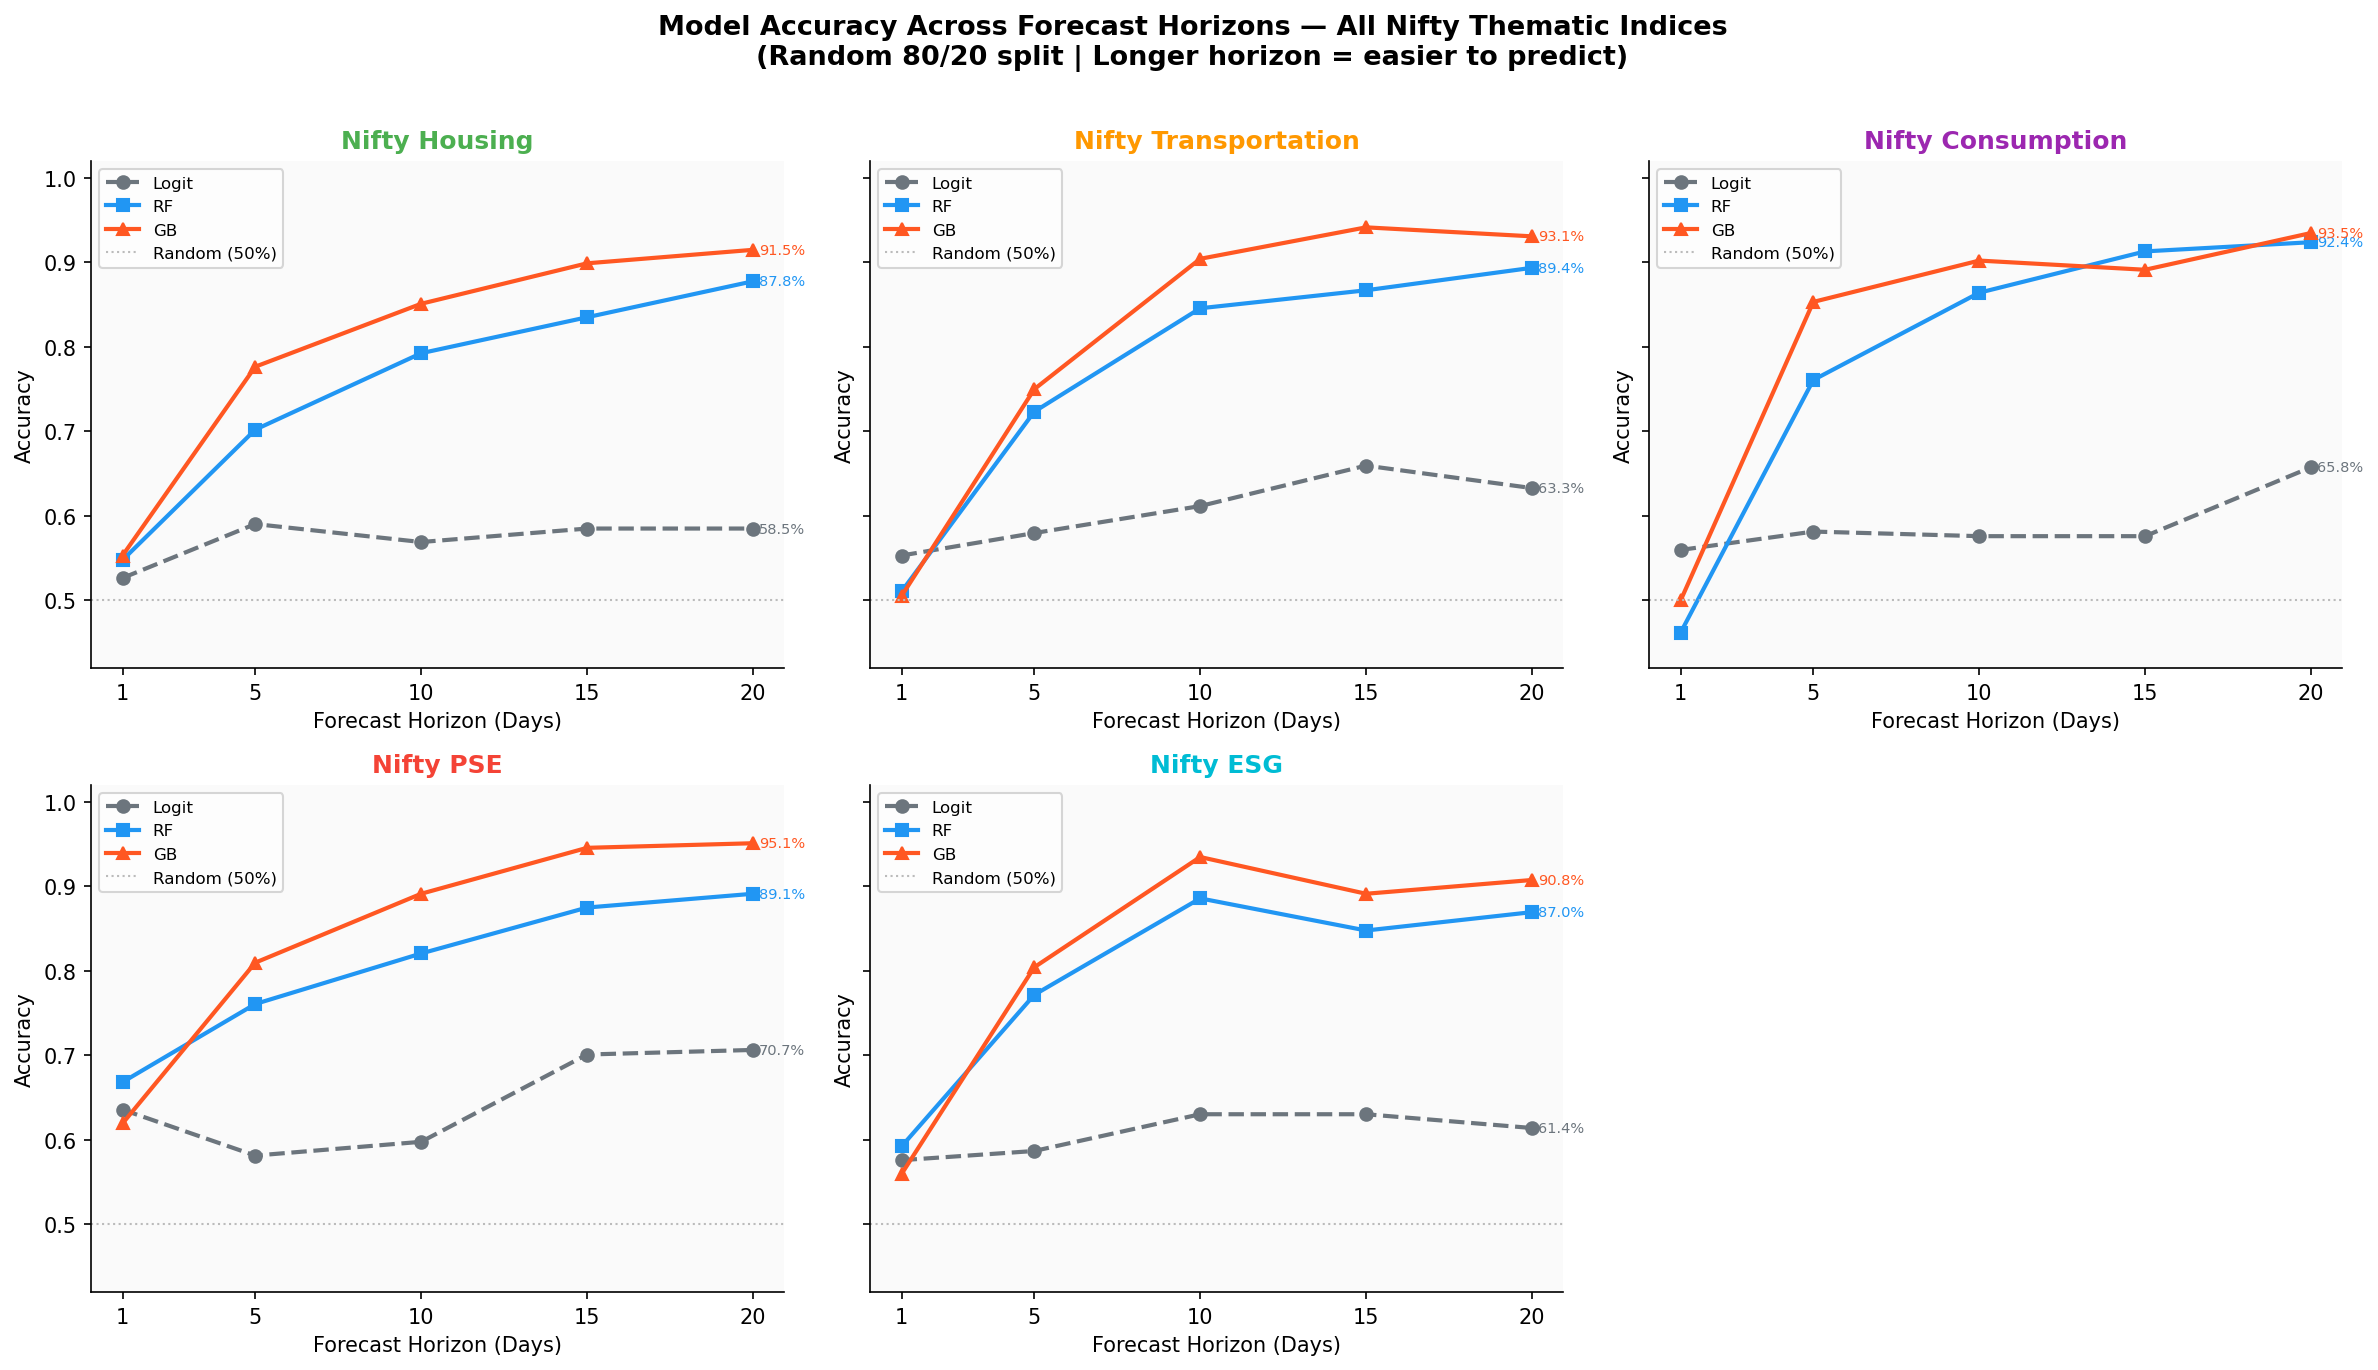

✓ Fig1_Accuracy_vs_Horizon.png saved


In [9]:
# ================================================================
# CELL 9 — FIGURE 1: Accuracy vs Horizon (all 5 indices)
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes      = axes.flatten()

for i, (idx, cfg) in enumerate(INDEX_CFG.items()):
    ax  = axes[i]
    acc = acc_t[idx]

    for m in ['Logit', 'RF', 'GB']:
        ax.plot(HORIZONS, acc[m],
                color=MODEL_COLORS[m], marker=MODEL_MARKERS[m],
                linestyle=MODEL_LINES[m], linewidth=2, markersize=6,
                label=m)
        # Label endpoint
        ax.annotate(f'{acc[m].iloc[-1]*100:.1f}%',
                    xy=(20, acc[m].iloc[-1]),
                    xytext=(3, 0), textcoords='offset points',
                    fontsize=7, color=MODEL_COLORS[m], va='center')

    ax.axhline(0.50, color=MODEL_COLORS['Random'], linestyle=':',
               linewidth=1, label='Random (50%)')
    ax.set_title(f'Nifty {idx}', fontweight='bold',
                 color=cfg['color'], fontsize=12)
    ax.set_xlabel('Forecast Horizon (Days)')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.42, 1.02)
    ax.set_xticks(HORIZONS)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_facecolor('#FAFAFA')

axes[-1].set_visible(False)
fig.suptitle(
    'Model Accuracy Across Forecast Horizons — All Nifty Thematic Indices\n'
    '(Random 80/20 split | Longer horizon = easier to predict)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('Fig1_Accuracy_vs_Horizon.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Fig1_Accuracy_vs_Horizon.png saved')

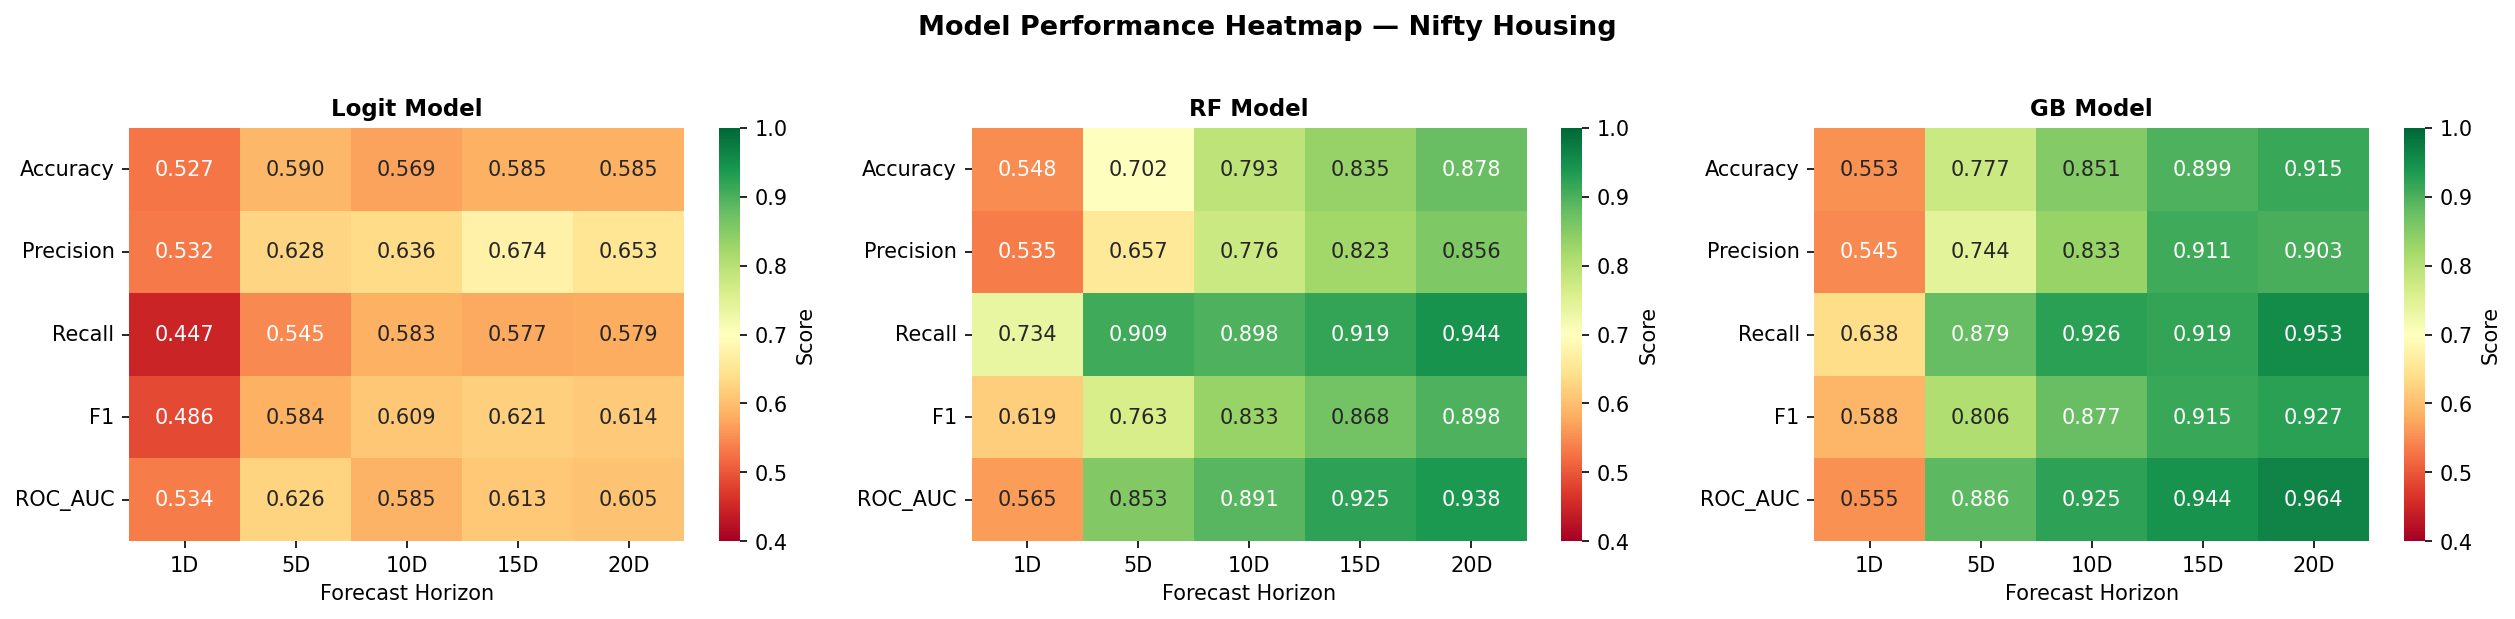

✓ Fig2_Heatmap_Housing.png saved


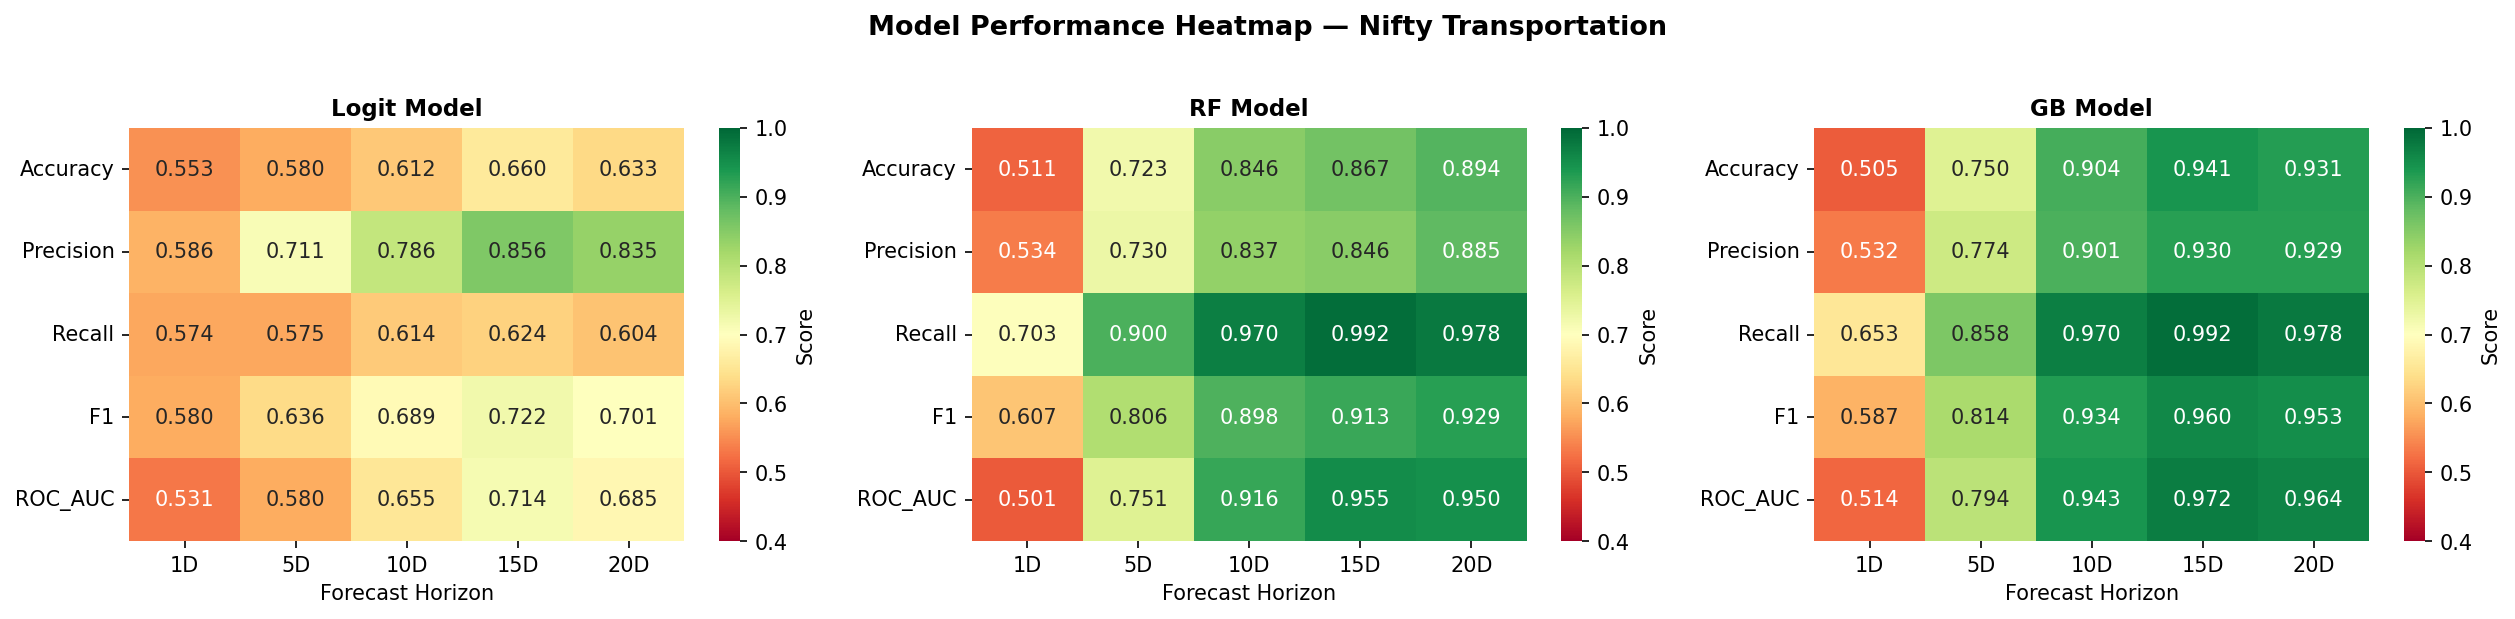

✓ Fig2_Heatmap_Transportation.png saved


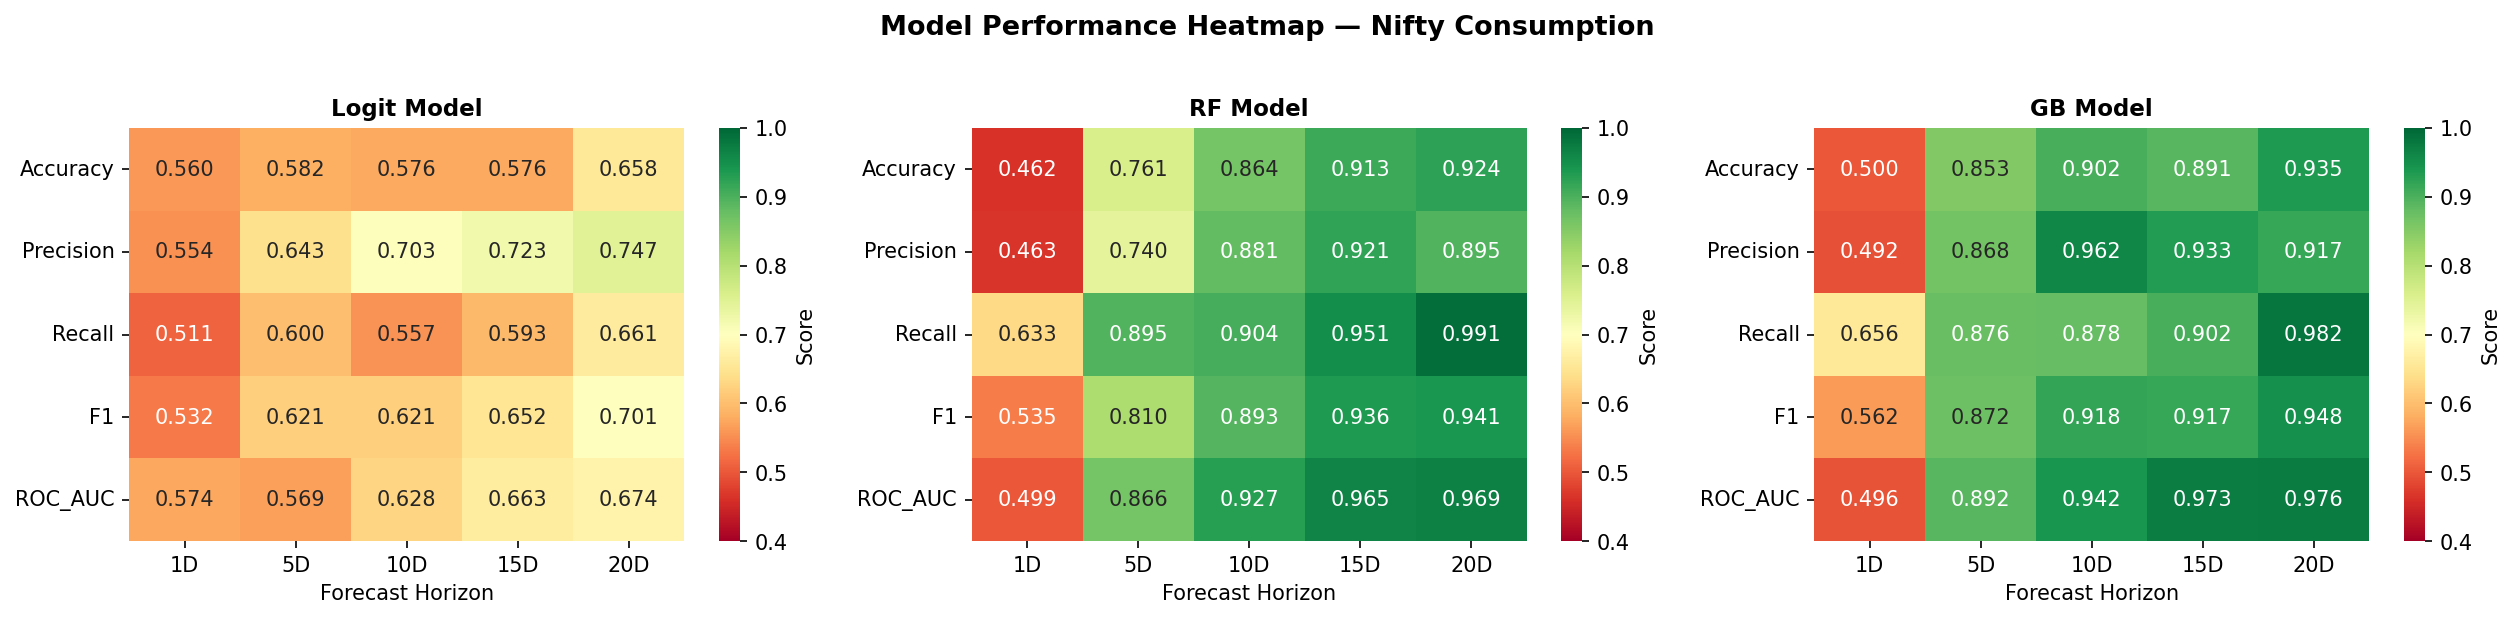

✓ Fig2_Heatmap_Consumption.png saved


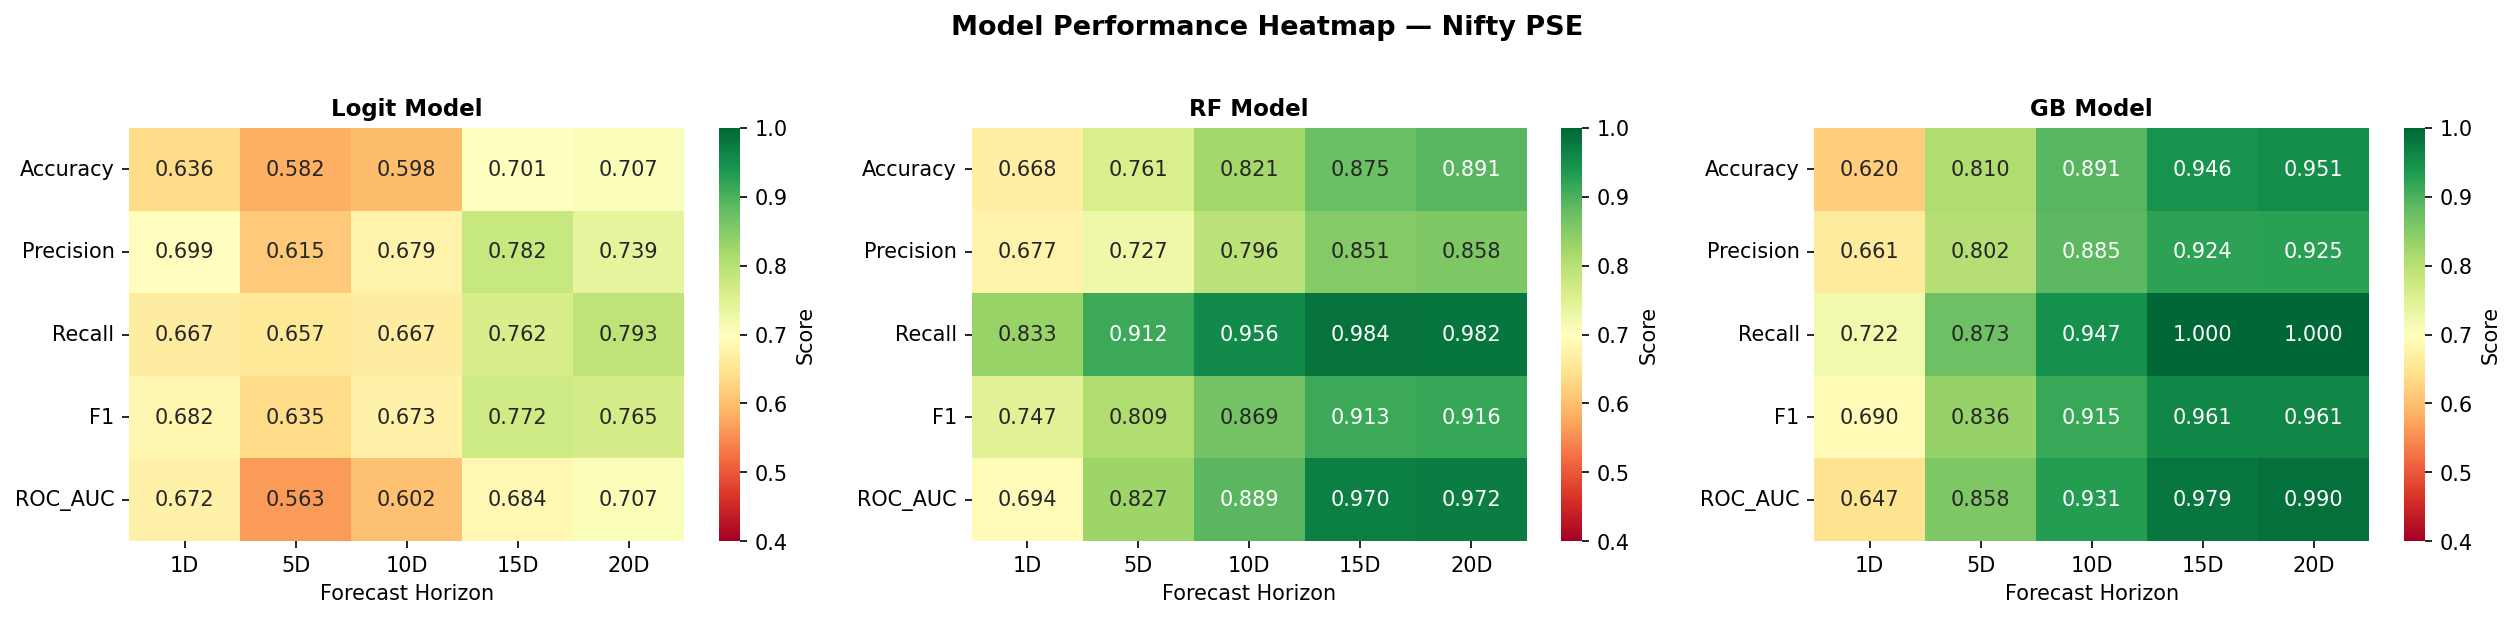

✓ Fig2_Heatmap_PSE.png saved


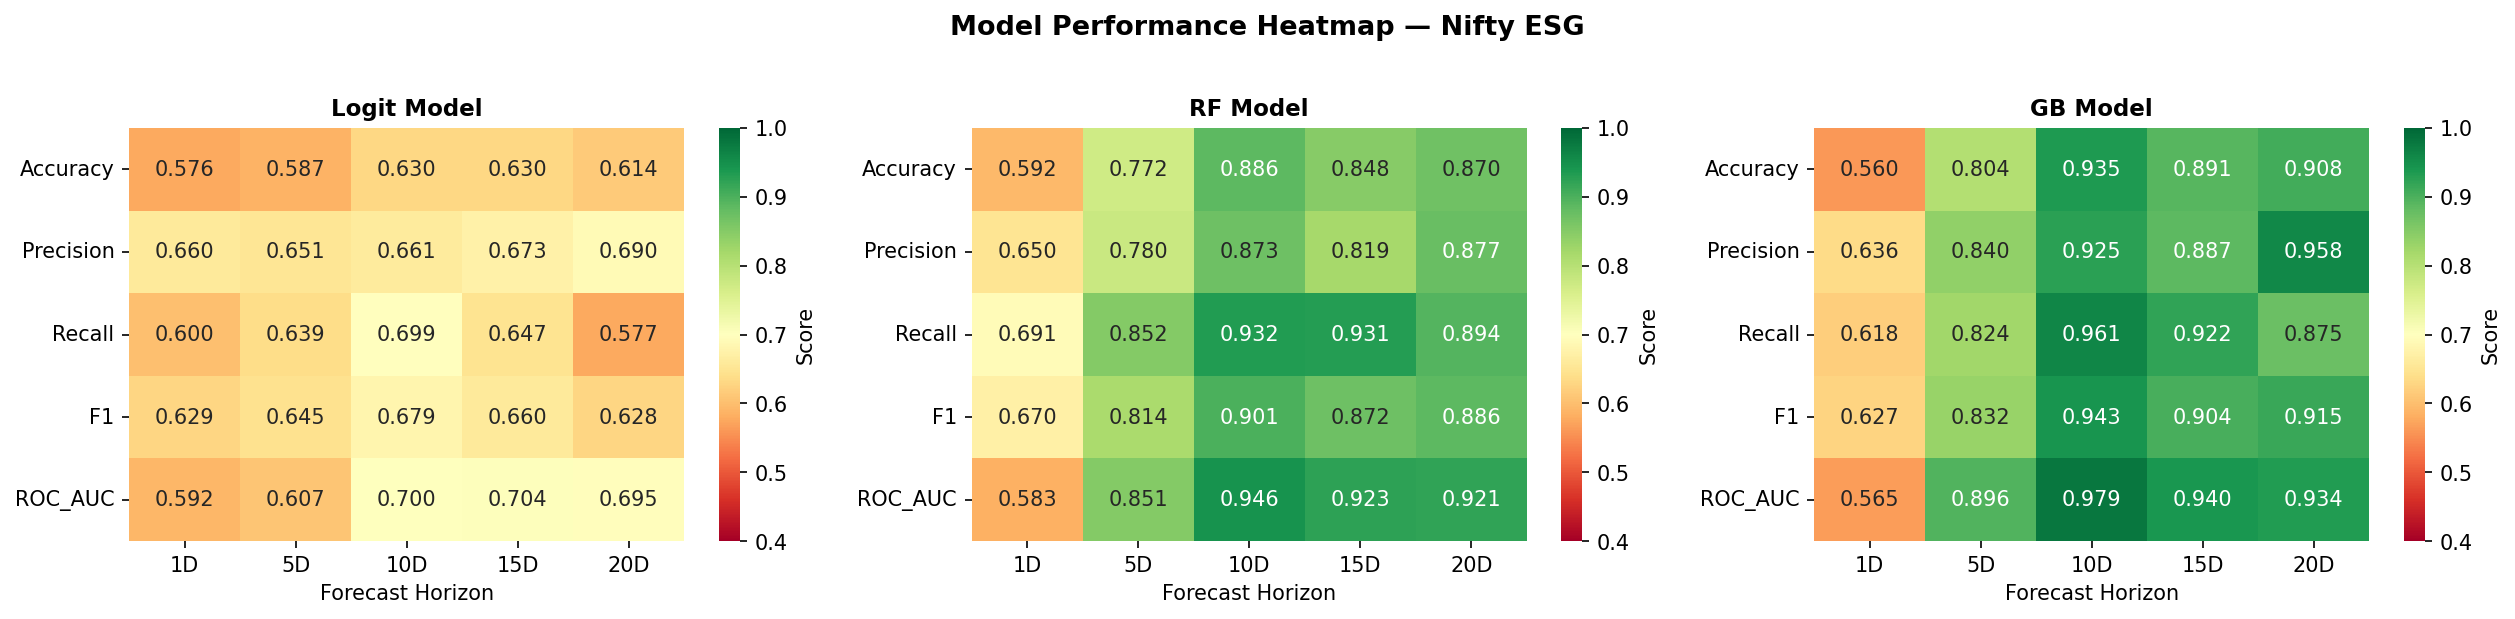

✓ Fig2_Heatmap_ESG.png saved


In [10]:
# ================================================================
# CELL 10 — FIGURE 2: Performance Heatmaps (one per index)
# ================================================================

metrics_plot  = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
horizon_lbls  = [f'{h}D' for h in HORIZONS]

for idx in INDEX_CFG:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    fig.suptitle(f'Model Performance Heatmap — Nifty {idx}',
                 fontsize=13, fontweight='bold', y=1.02)

    for ax, model in zip(axes, ['Logit', 'RF', 'GB']):
        data = np.array([
            [all_res[idx][h][model][m] for h in HORIZONS]
            for m in metrics_plot
        ])
        sns.heatmap(data, ax=ax, annot=True, fmt='.3f',
                    cmap='RdYlGn', vmin=0.4, vmax=1.0,
                    xticklabels=horizon_lbls, yticklabels=metrics_plot,
                    cbar_kws={'label': 'Score'})
        ax.set_title(f'{model} Model', fontweight='bold')
        ax.set_xlabel('Forecast Horizon')

    plt.tight_layout()
    fname = f'Fig2_Heatmap_{idx}.png'
    plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'✓ {fname} saved')

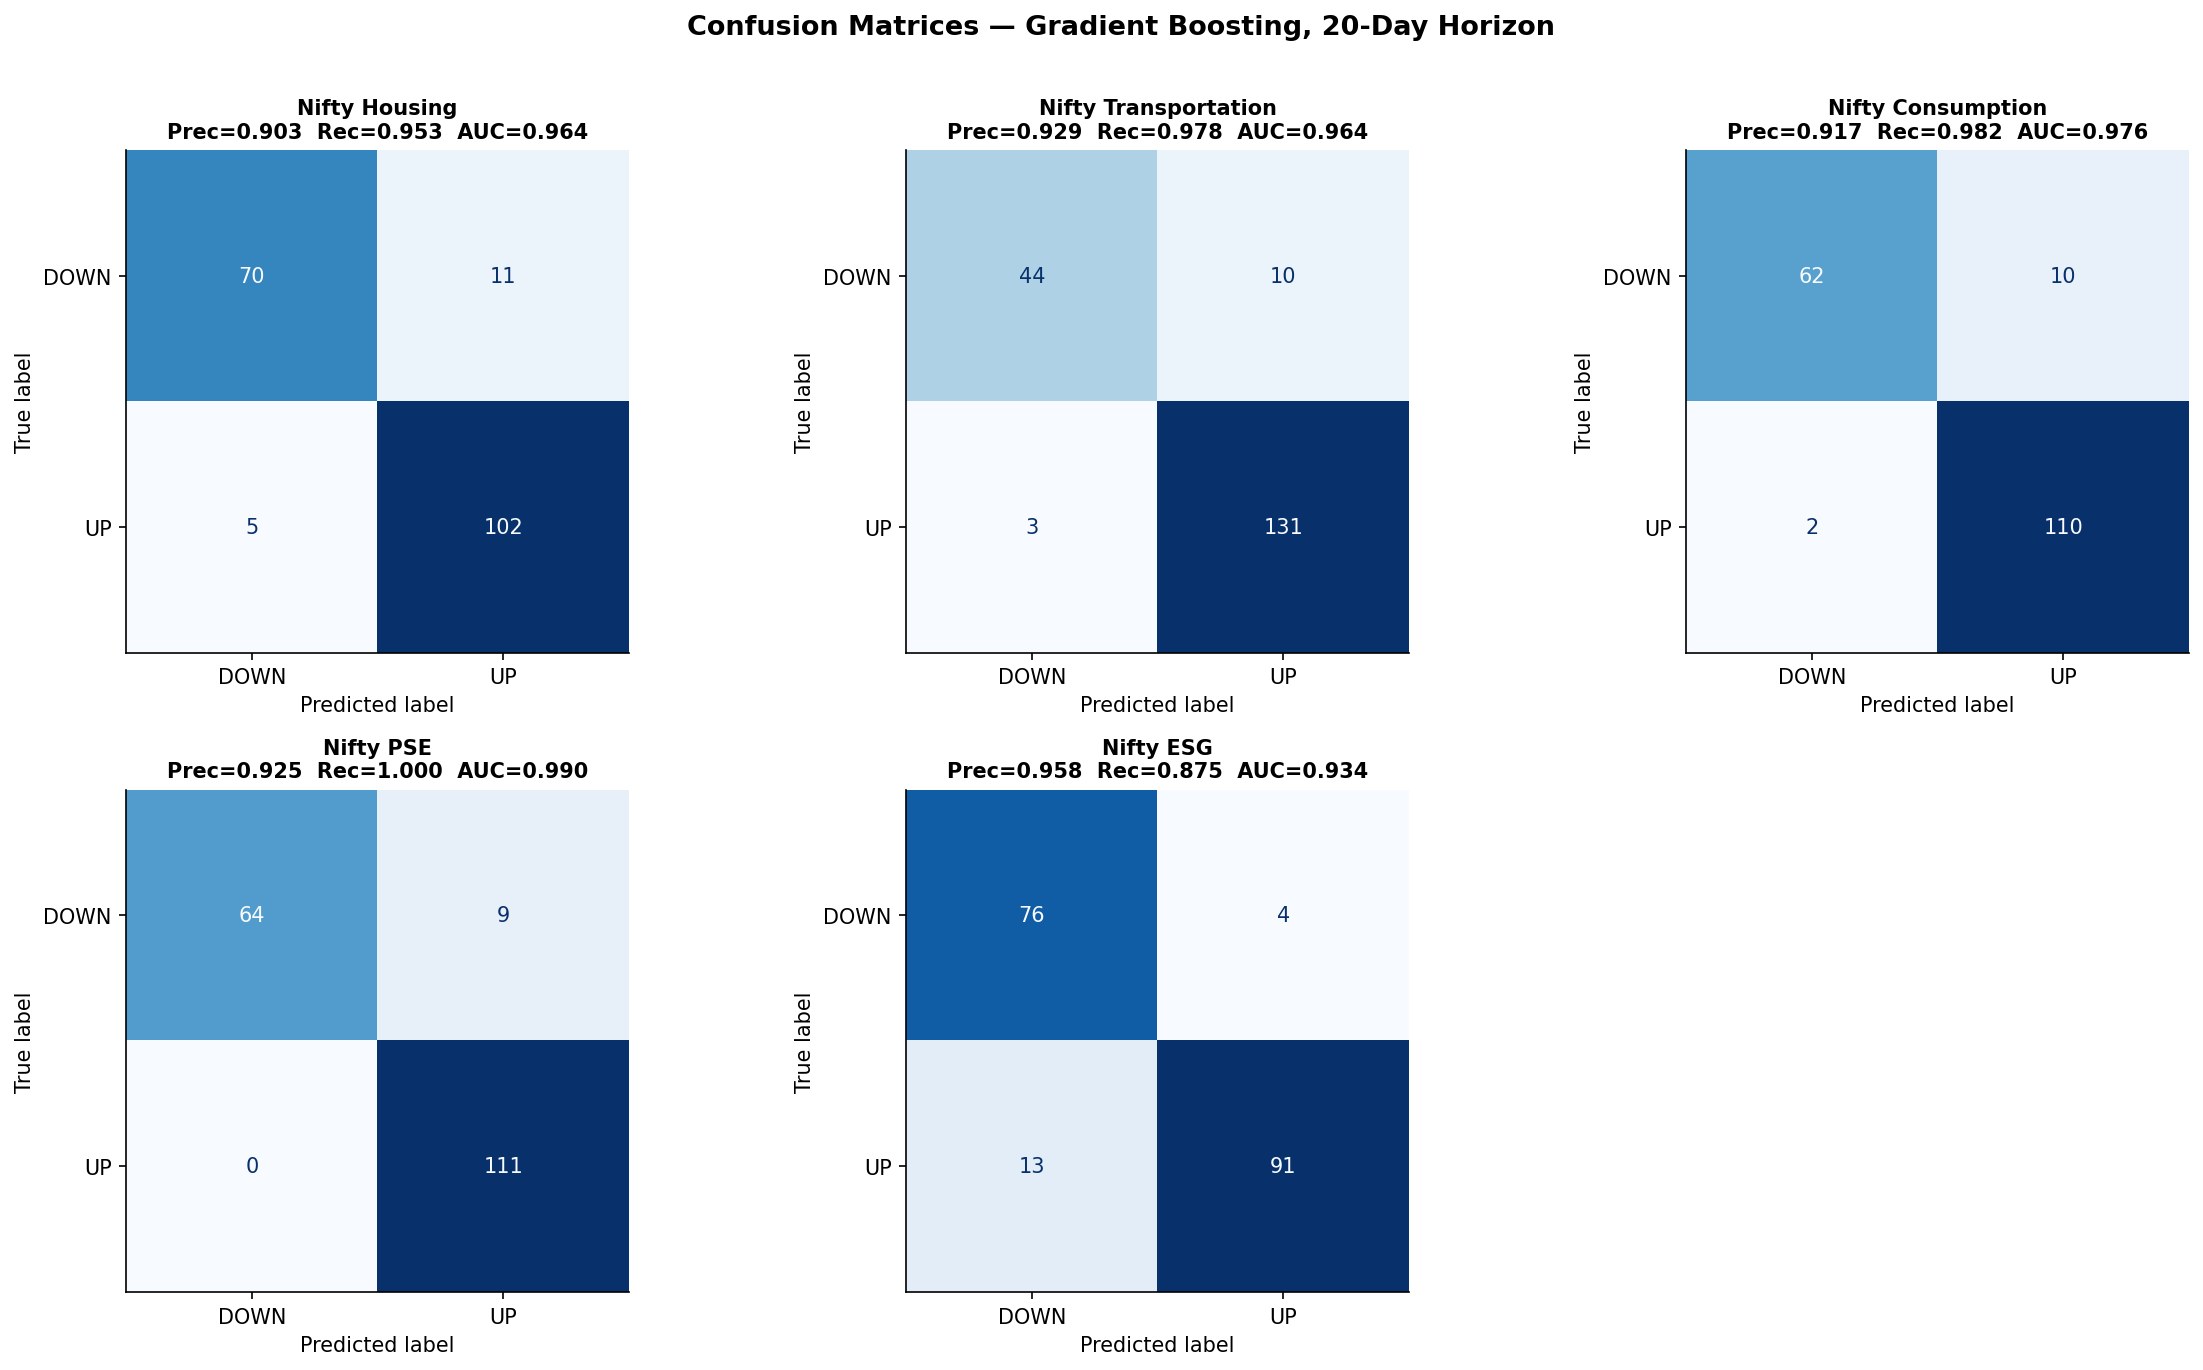

✓ Fig3_Confusion_Matrices_GB20.png saved


In [11]:
# ================================================================
# CELL 11 — FIGURE 3: Confusion Matrices — GB 20-Day Horizon
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes      = axes.flatten()

for i, idx in enumerate(INDEX_CFG):
    ax  = axes[i]
    gb  = all_res[idx][20]['GB']
    cm  = np.array([[gb['TN'], gb['FP']], [gb['FN'], gb['TP']]])

    disp = ConfusionMatrixDisplay(cm, display_labels=['DOWN', 'UP'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)

    prec = gb['Precision']
    rec  = gb['Recall']
    auc  = gb['ROC_AUC']
    ax.set_title(
        f'Nifty {idx}\n'
        f'Prec={prec:.3f}  Rec={rec:.3f}  AUC={auc:.3f}',
        fontsize=10, fontweight='bold'
    )

axes[-1].set_visible(False)
fig.suptitle('Confusion Matrices — Gradient Boosting, 20-Day Horizon',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Fig3_Confusion_Matrices_GB20.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Fig3_Confusion_Matrices_GB20.png saved')

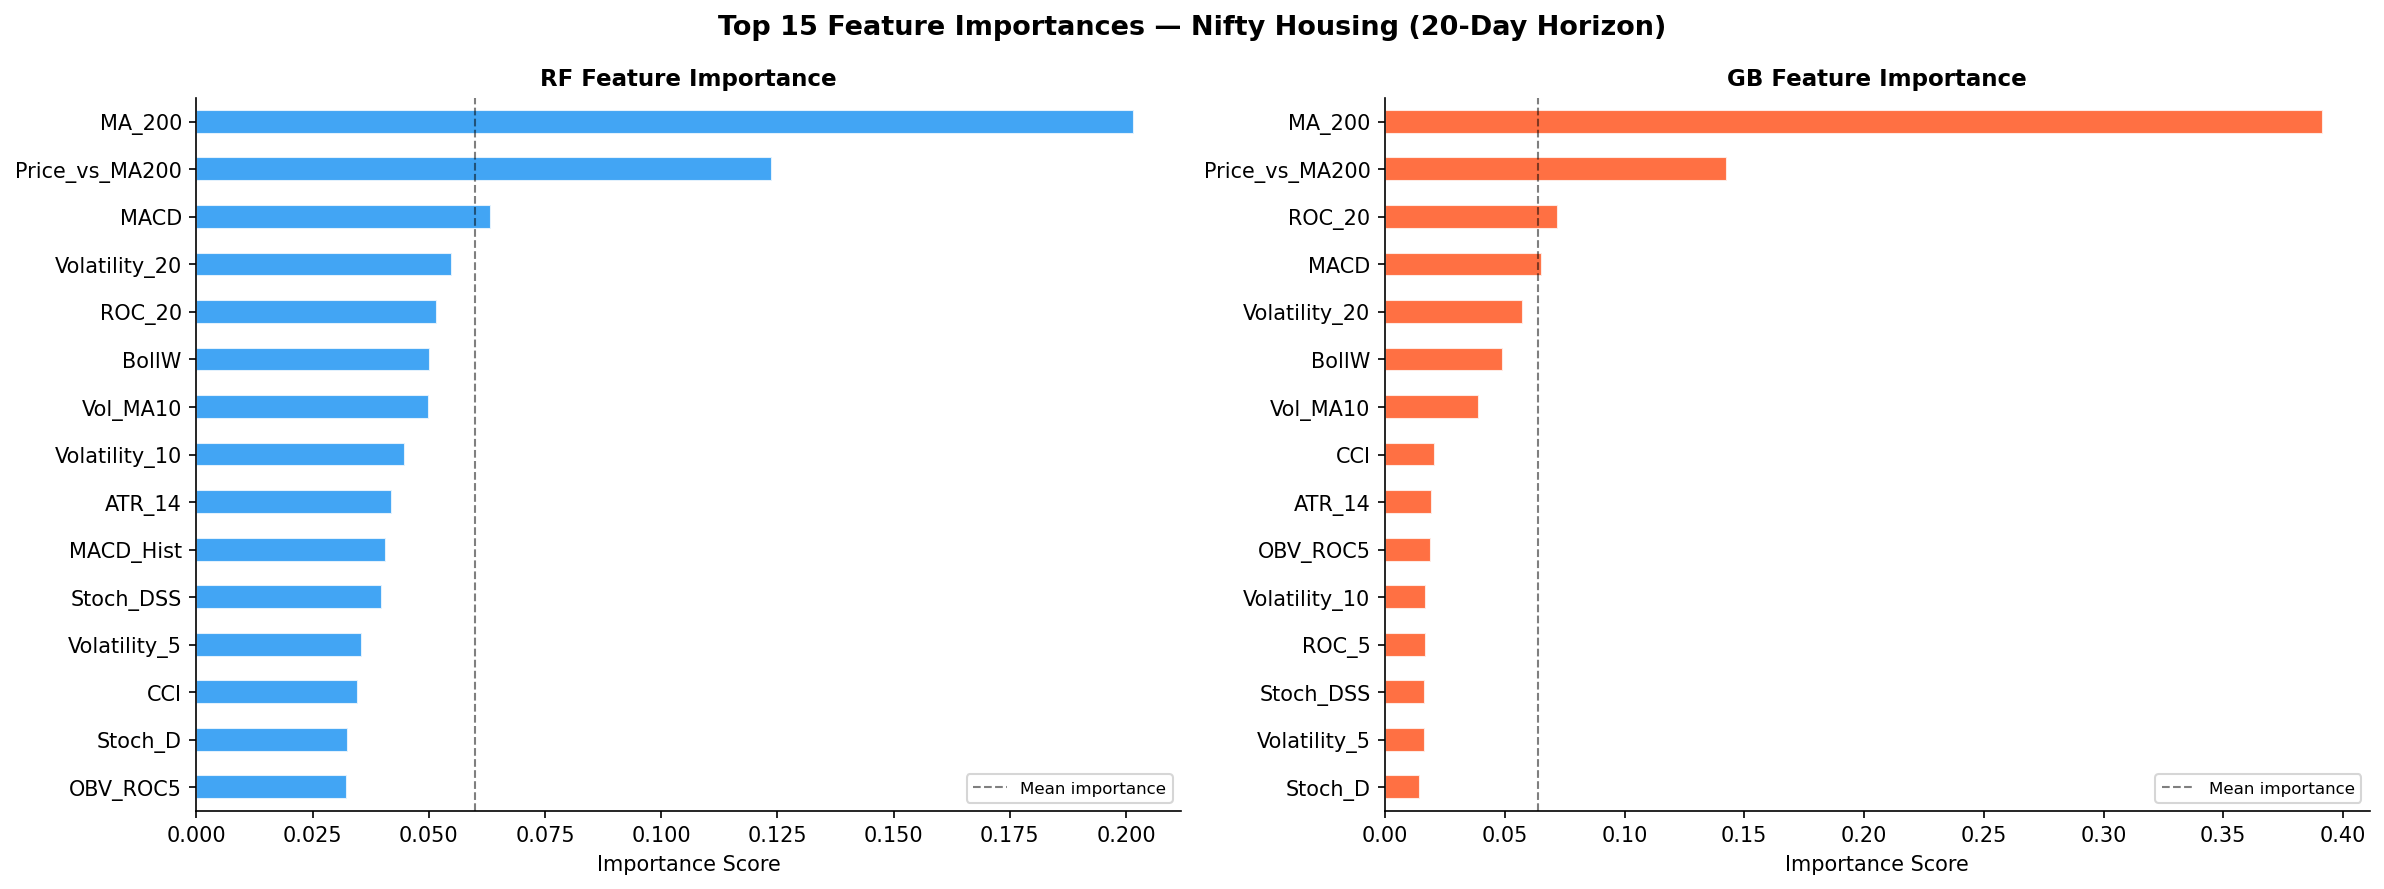

✓ Fig4_FeatureImportance_Housing.png saved


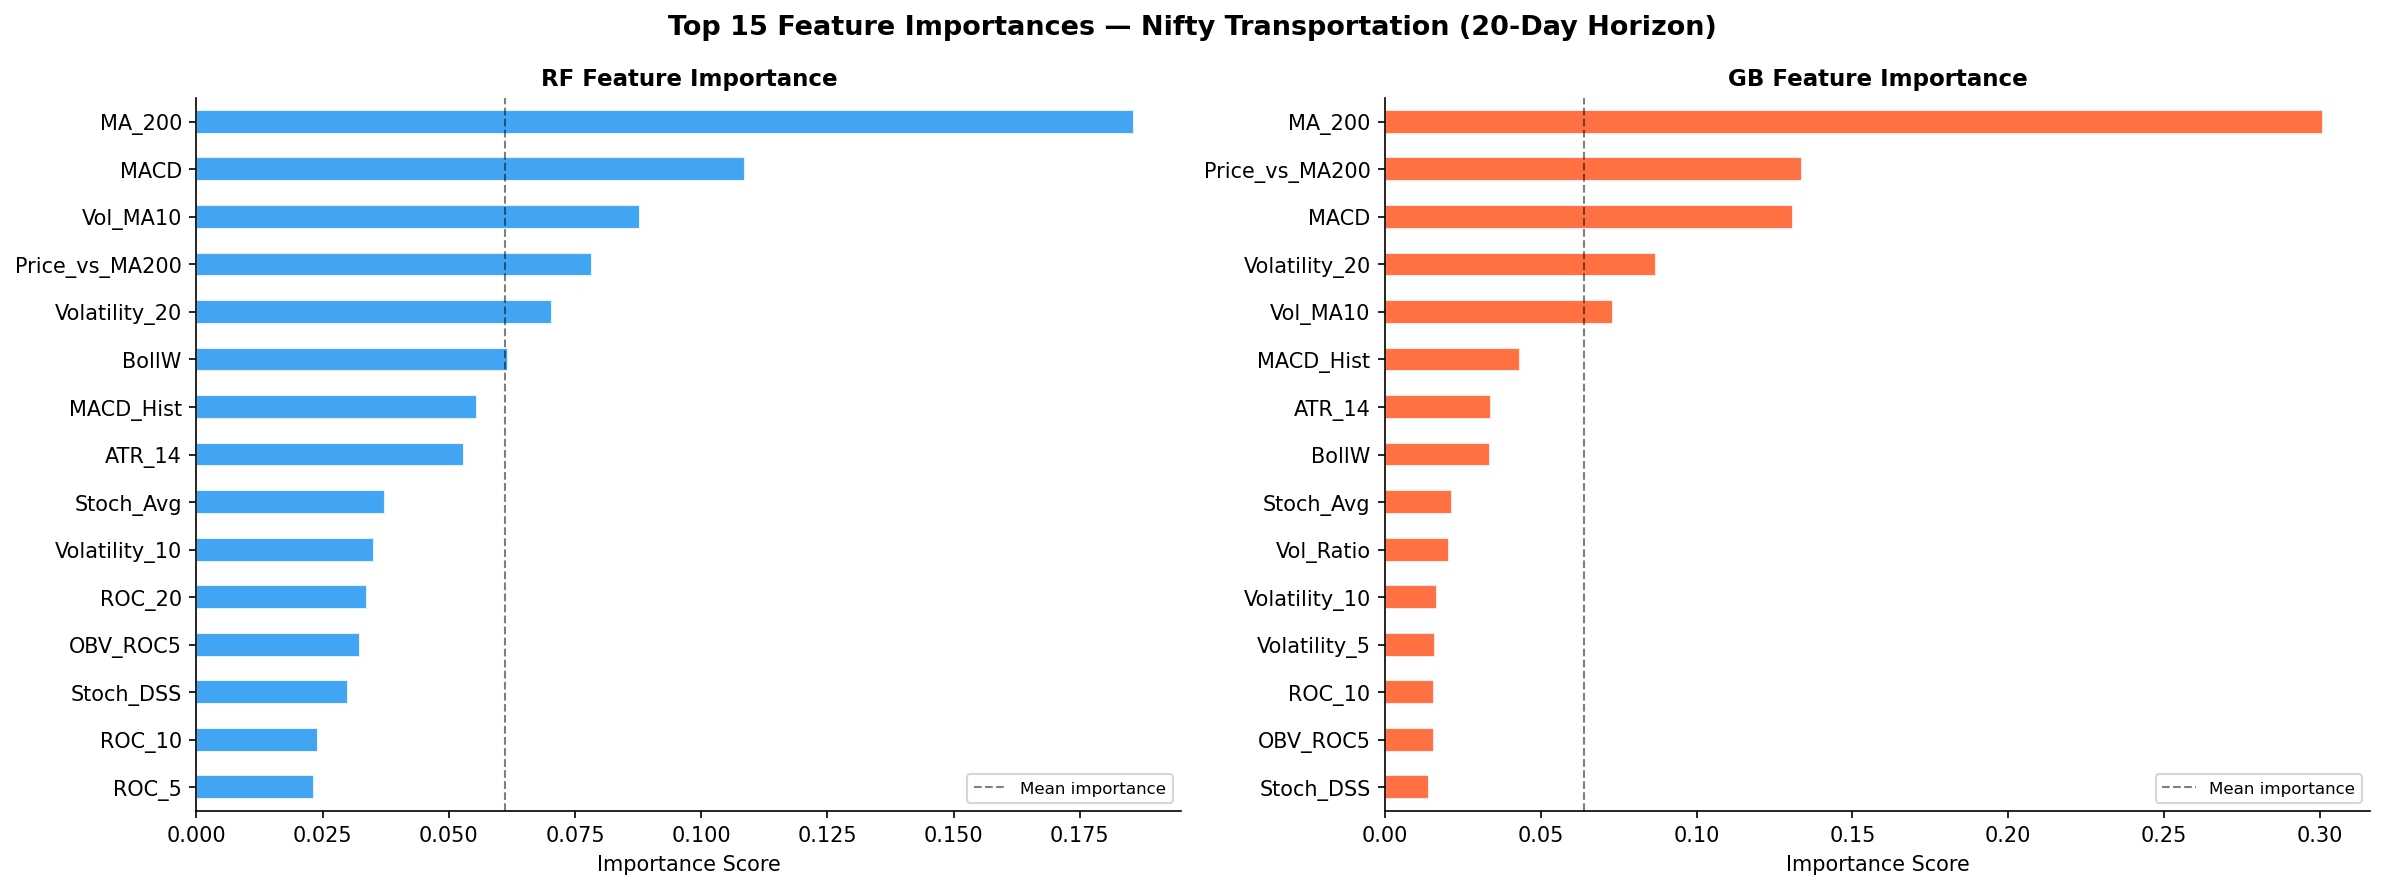

✓ Fig4_FeatureImportance_Transportation.png saved


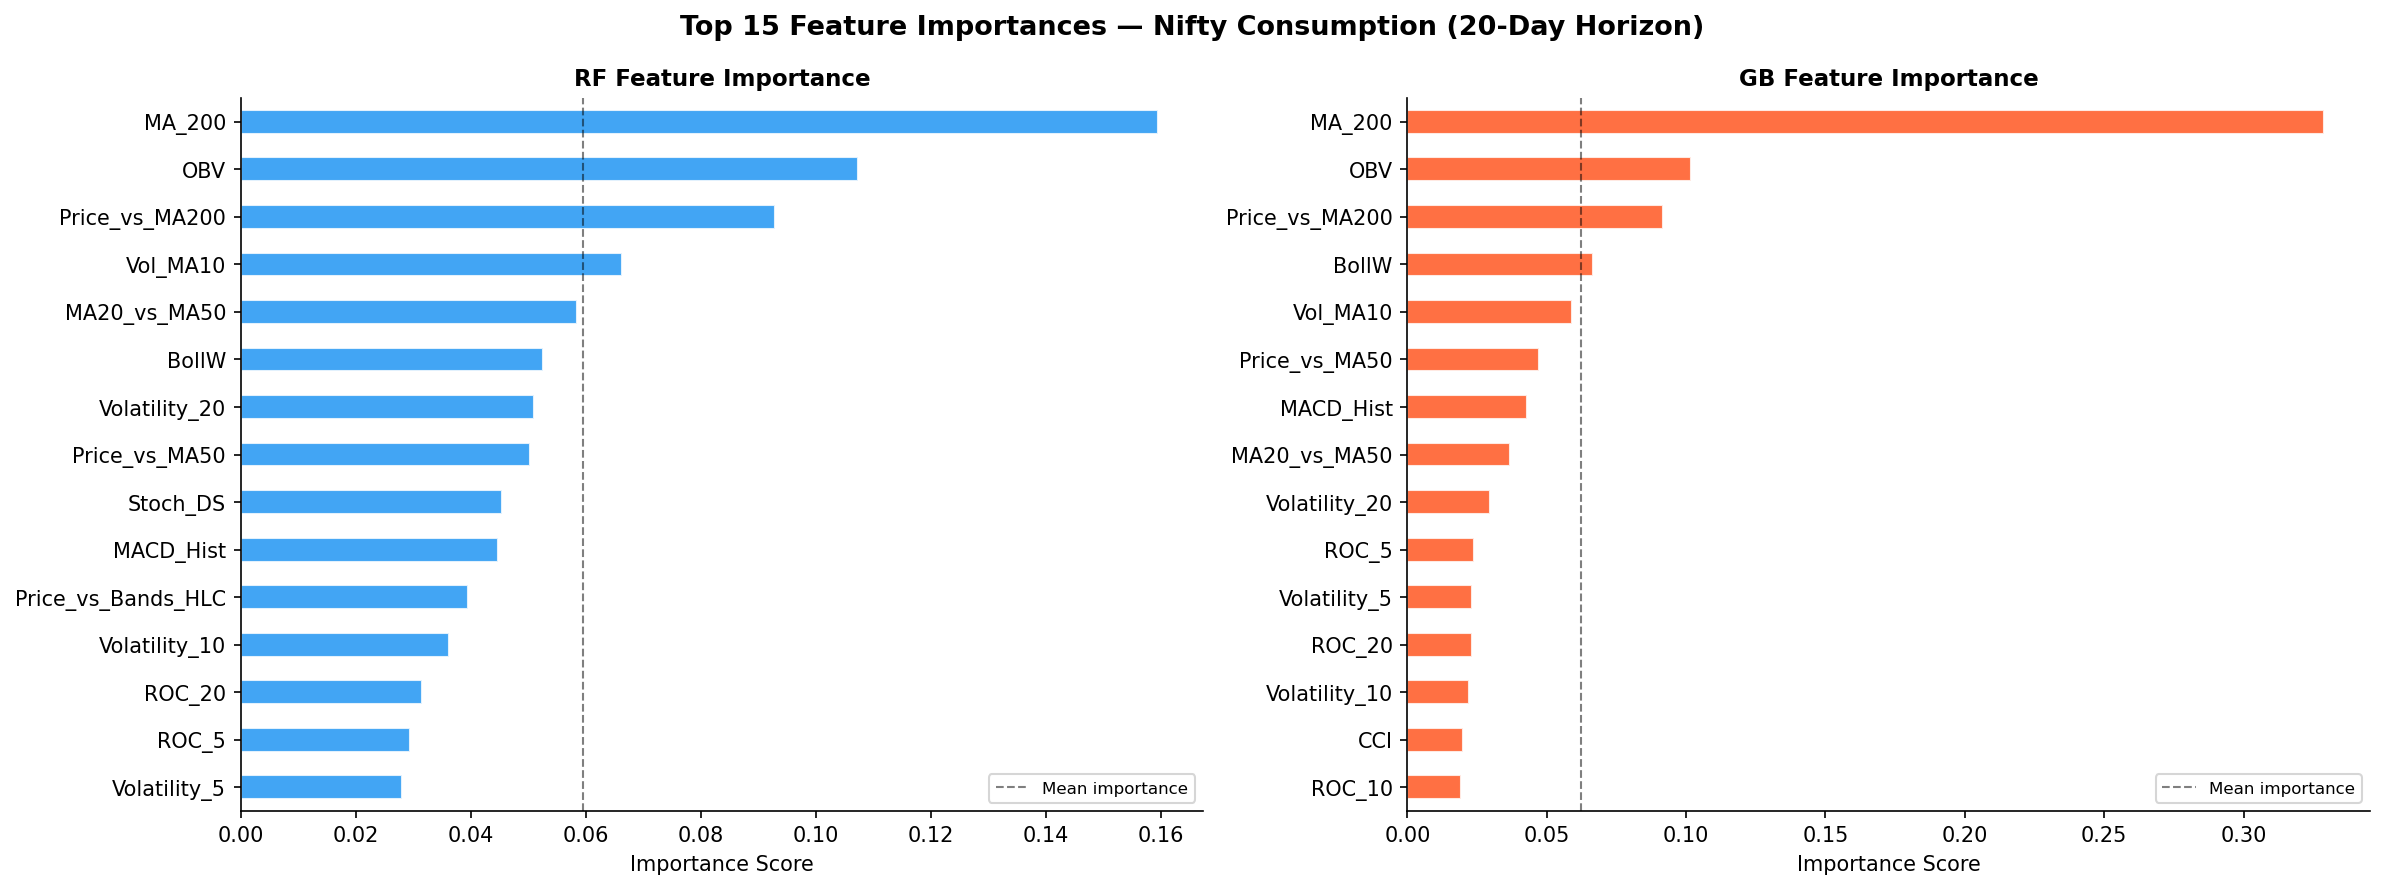

✓ Fig4_FeatureImportance_Consumption.png saved


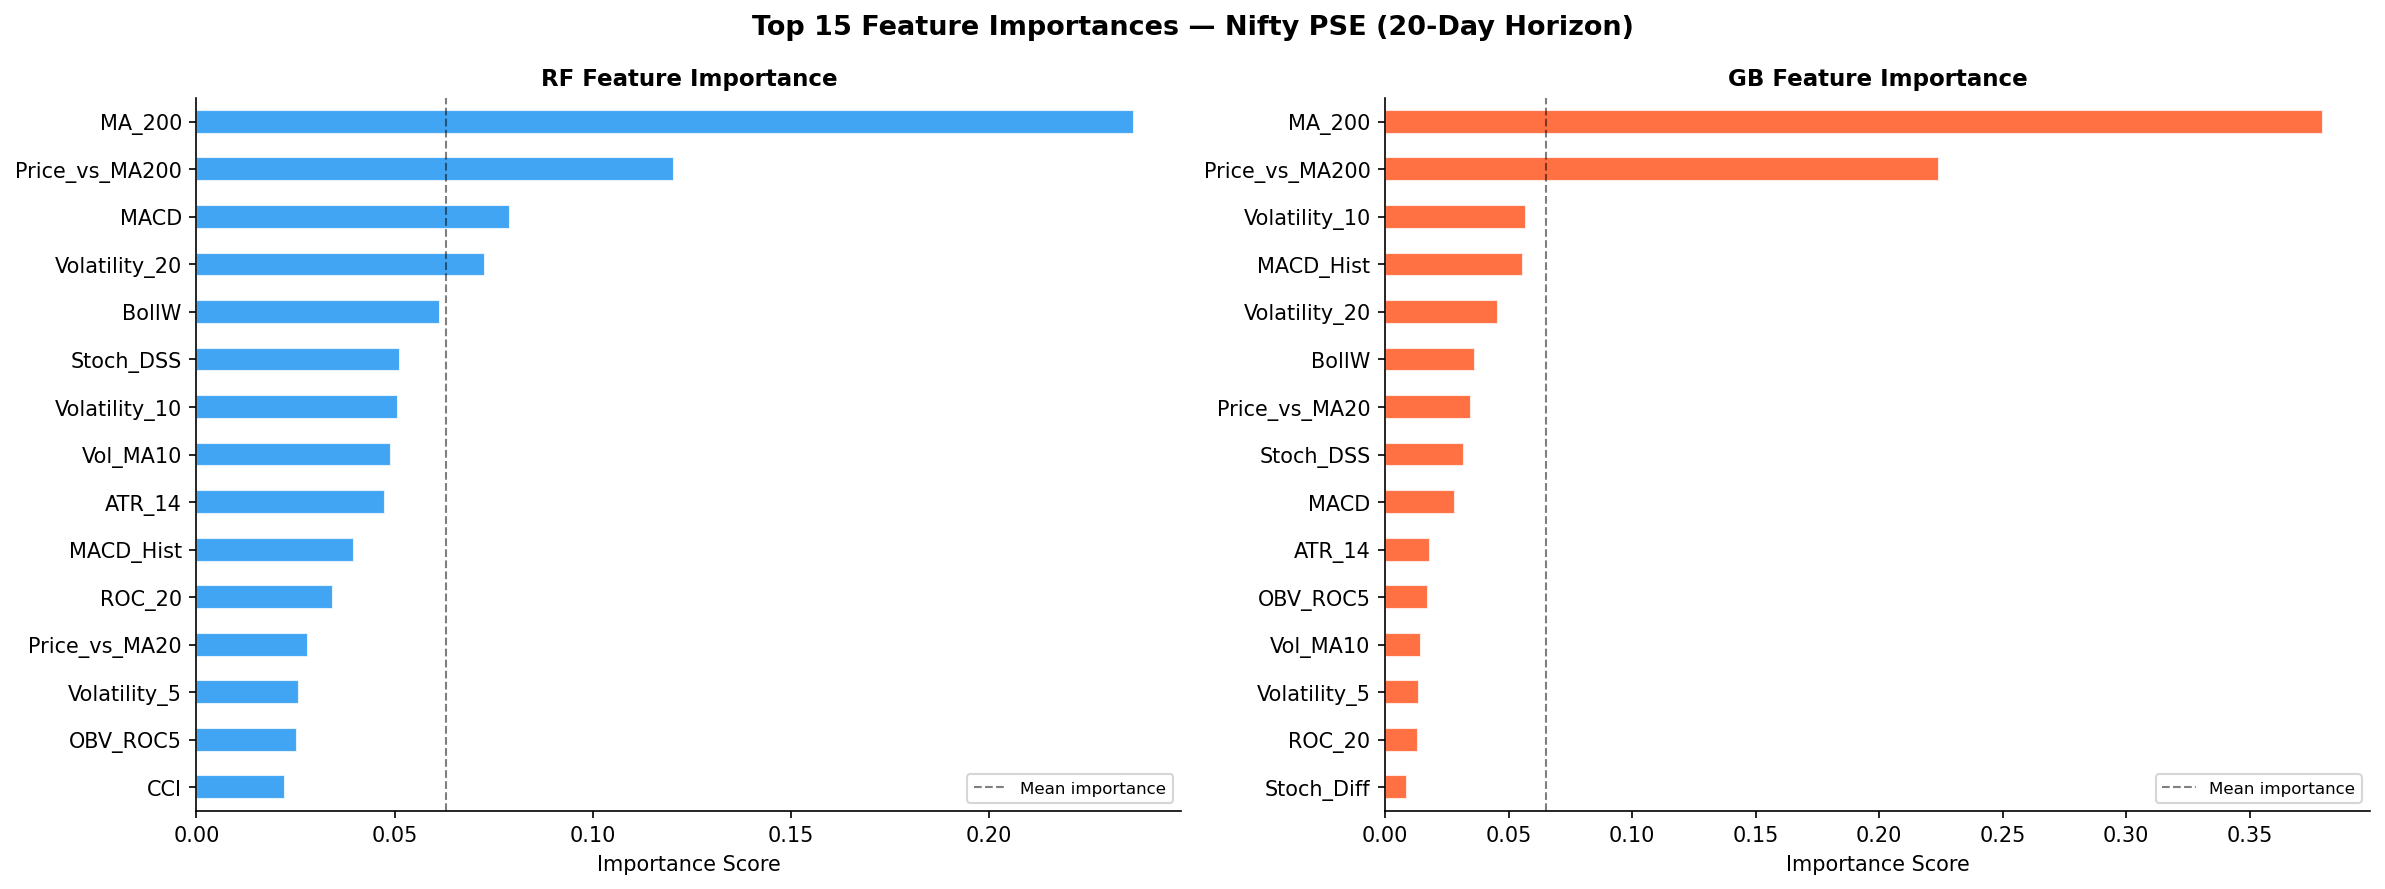

✓ Fig4_FeatureImportance_PSE.png saved


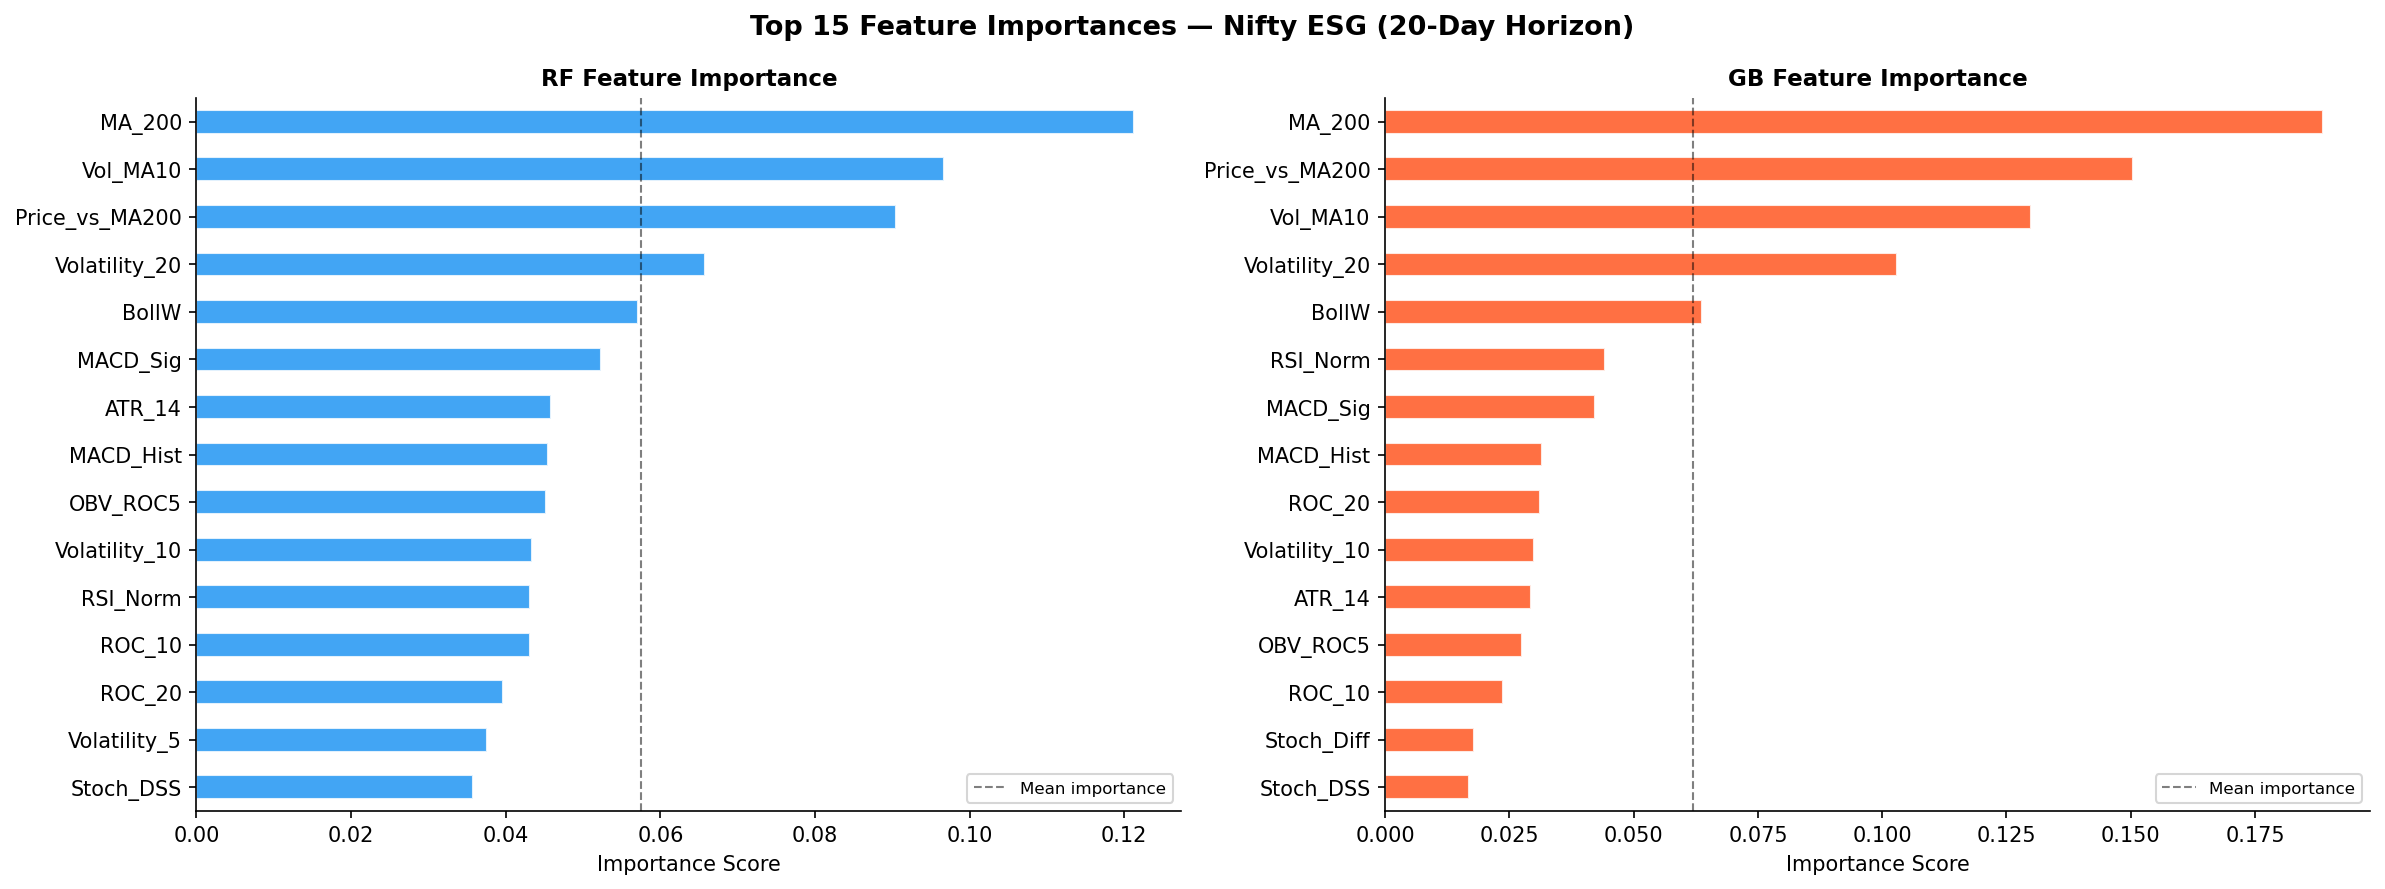

✓ Fig4_FeatureImportance_ESG.png saved


In [12]:
# ================================================================
# CELL 12 — FIGURE 4: Feature Importance — Top 15 (RF + GB)
#           One figure per index, 20-day horizon
# ================================================================

for idx in INDEX_CFG:
    fi   = all_res[idx][20]['_fi_']
    if not fi:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Top 15 Feature Importances — Nifty {idx} (20-Day Horizon)',
                 fontsize=13, fontweight='bold')

    for ax, (mname, fi_ser) in zip(axes, fi.items()):
        top = fi_ser.head(15).sort_values()
        col = MODEL_COLORS[mname]
        top.plot(kind='barh', ax=ax, color=col, edgecolor='white', alpha=0.85)
        ax.axvline(top.mean(), color='black', linestyle='--',
                   linewidth=1, alpha=0.5, label='Mean importance')
        ax.set_title(f'{mname} Feature Importance', fontweight='bold')
        ax.set_xlabel('Importance Score')
        ax.legend(fontsize=8)

    plt.tight_layout()
    fname = f'Fig4_FeatureImportance_{idx}.png'
    plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'✓ {fname} saved')

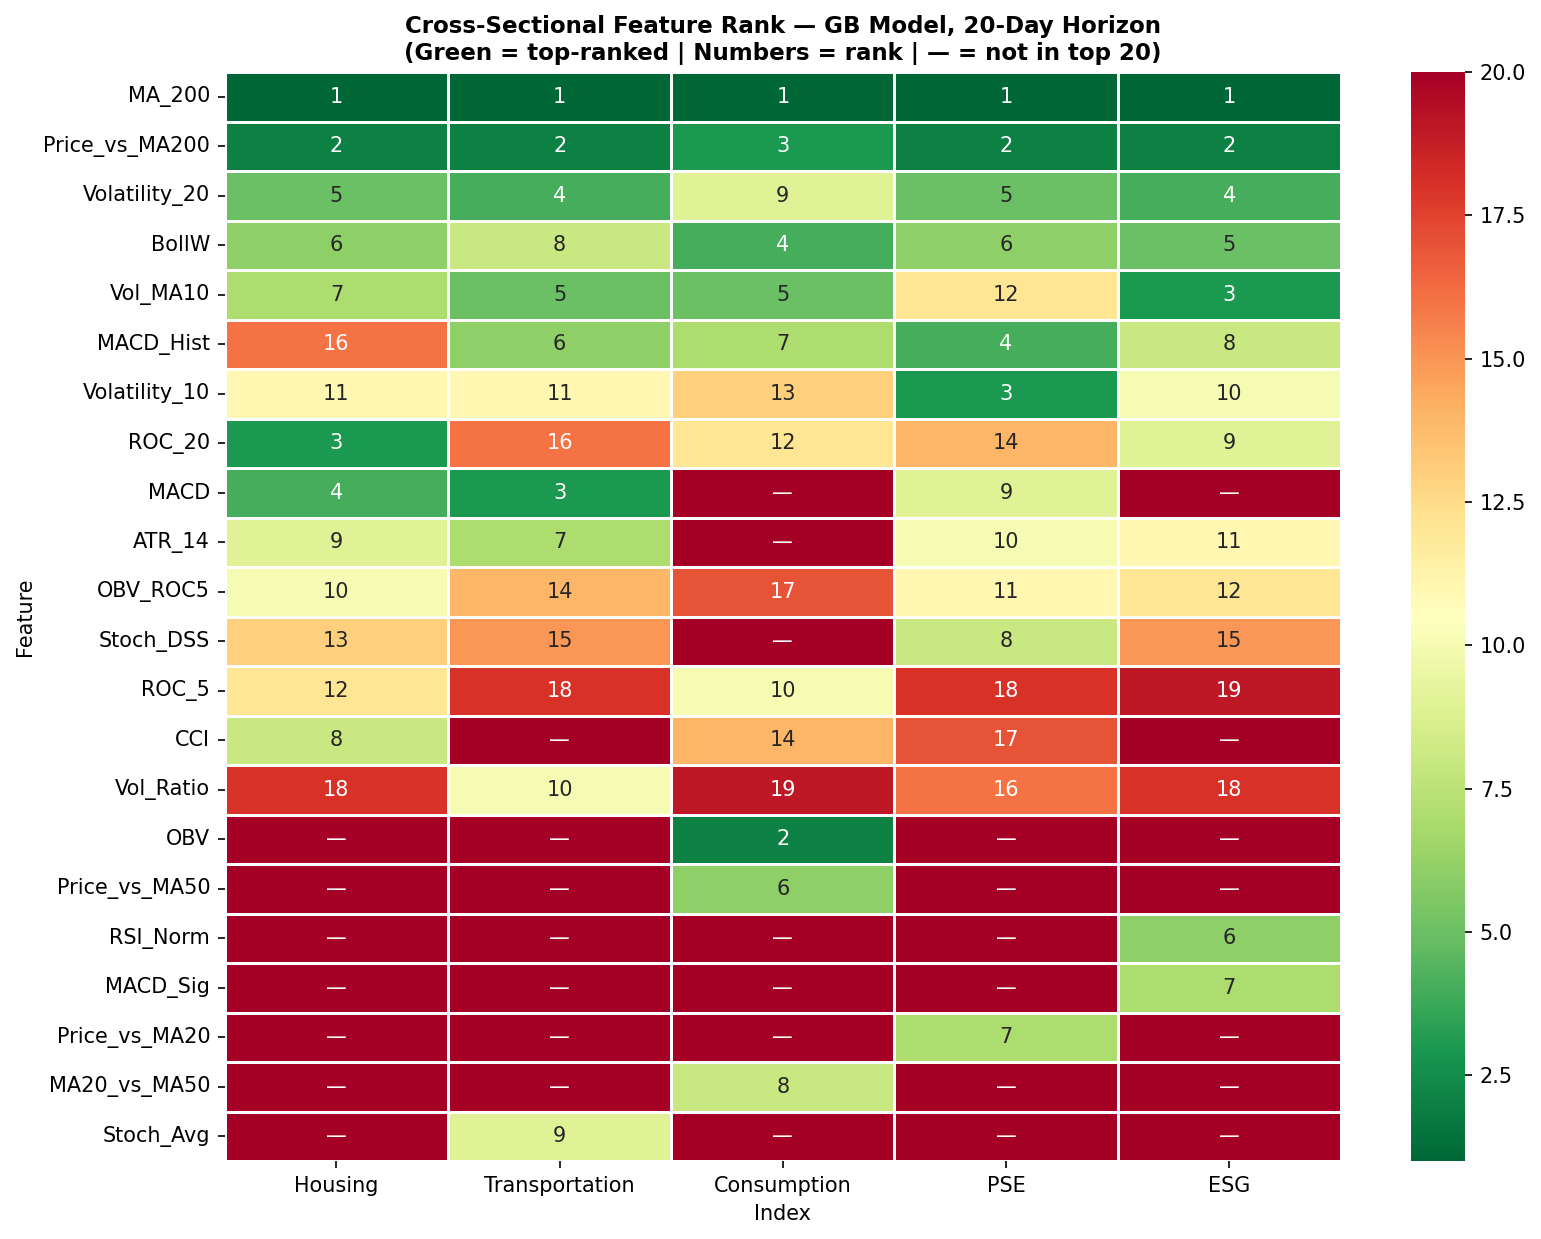

✓ Fig5_CrossSectional_FeatureRank.png saved


In [13]:
# ================================================================
# CELL 13 — FIGURE 5: Cross-Sectional Feature Rank Heatmap
# Identifies 'super-features' consistent across all indices
# ================================================================

rank_data = {}
for idx in INDEX_CFG:
    fi = all_res[idx][20]['_fi_'].get('GB')
    if fi is not None:
        rank_data[idx] = fi.rank(ascending=False, method='min').astype(int)

# Union of top-10 features across all indices
top_union = set()
for idx in INDEX_CFG:
    fi = all_res[idx][20]['_fi_'].get('GB')
    if fi is not None:
        top_union.update(fi.head(10).index.tolist())

rank_df = pd.DataFrame(rank_data)
rank_df = rank_df.loc[rank_df.index.isin(top_union)]

# Fill NaN (feature top-10 in one index but exists in others with high rank)
sentinel = N_FEATURES + 1
rank_df  = rank_df.fillna(sentinel).astype(int)

# String annotations: show rank or '—' for sentinel
annot = rank_df.copy().astype(object)
for col in annot.columns:
    annot[col] = annot[col].apply(lambda v: '—' if v >= sentinel else str(int(v)))

rank_df['Mean'] = rank_df.clip(upper=N_FEATURES).mean(axis=1)
rank_df = rank_df.sort_values('Mean').drop(columns='Mean')
annot   = annot.loc[rank_df.index]

fig, ax = plt.subplots(figsize=(11, max(6, len(rank_df) * 0.38)))
sns.heatmap(rank_df.clip(upper=20), ax=ax,
            annot=annot, fmt='',
            cmap='RdYlGn_r', vmin=1, vmax=20,
            linewidths=0.5, linecolor='white')
ax.set_title(
    'Cross-Sectional Feature Rank — GB Model, 20-Day Horizon\n'
    '(Green = top-ranked | Numbers = rank | — = not in top 20)',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Index')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('Fig5_CrossSectional_FeatureRank.png', dpi=180, bbox_inches='tight')
plt.show()
print('✓ Fig5_CrossSectional_FeatureRank.png saved')

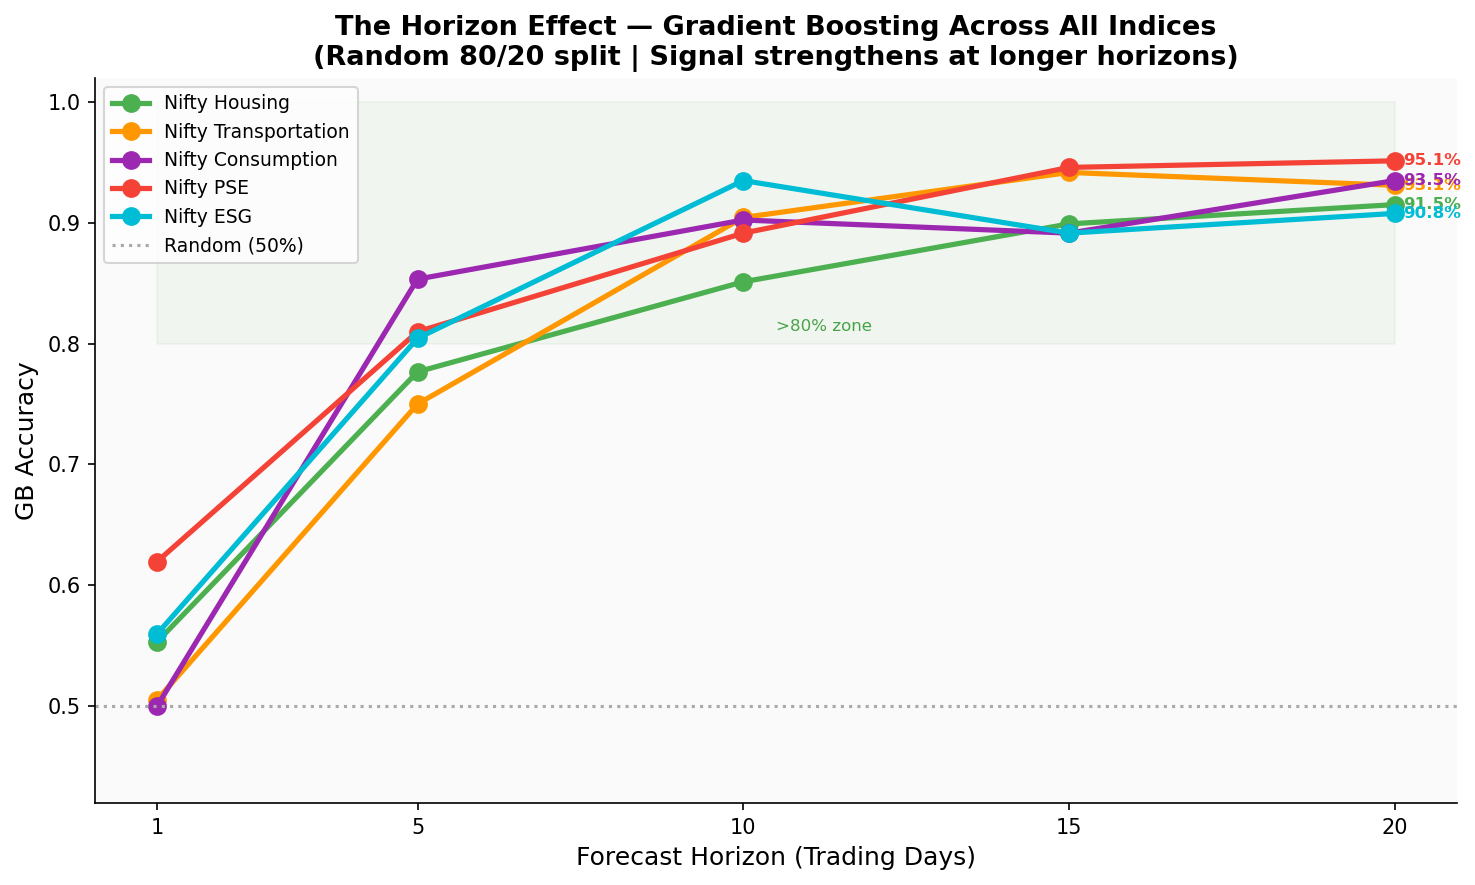

✓ Fig6_HorizonEffect_Summary.png saved


In [14]:
# ================================================================
# CELL 14 — FIGURE 6: Horizon Effect — GB All Indices Together
# ================================================================

fig, ax = plt.subplots(figsize=(10, 6))

for idx, cfg in INDEX_CFG.items():
    gb_acc = [all_res[idx][h]['GB']['Accuracy'] for h in HORIZONS]
    ax.plot(HORIZONS, gb_acc,
            marker='o', linewidth=2.5, markersize=8,
            color=cfg['color'], label=f'Nifty {idx}')
    ax.annotate(f'{gb_acc[-1]*100:.1f}%',
                xy=(20, gb_acc[-1]),
                xytext=(4, 0), textcoords='offset points',
                fontsize=8, color=cfg['color'], va='center', fontweight='bold')

ax.axhline(0.50, color='#AAAAAA', linestyle=':', linewidth=1.5, label='Random (50%)')
ax.fill_between([1,20], 0.80, 1.0, alpha=0.04, color='green')
ax.text(10.5, 0.81, '>80% zone', color='green', fontsize=8, alpha=0.7)
ax.set_xlabel('Forecast Horizon (Trading Days)', fontsize=12)
ax.set_ylabel('GB Accuracy', fontsize=12)
ax.set_title('The Horizon Effect — Gradient Boosting Across All Indices\n'
             '(Random 80/20 split | Signal strengthens at longer horizons)',
             fontsize=13, fontweight='bold')
ax.set_xticks(HORIZONS)
ax.set_ylim(0.42, 1.02)
ax.legend(loc='upper left', fontsize=9)
ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig('Fig6_HorizonEffect_Summary.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Fig6_HorizonEffect_Summary.png saved')

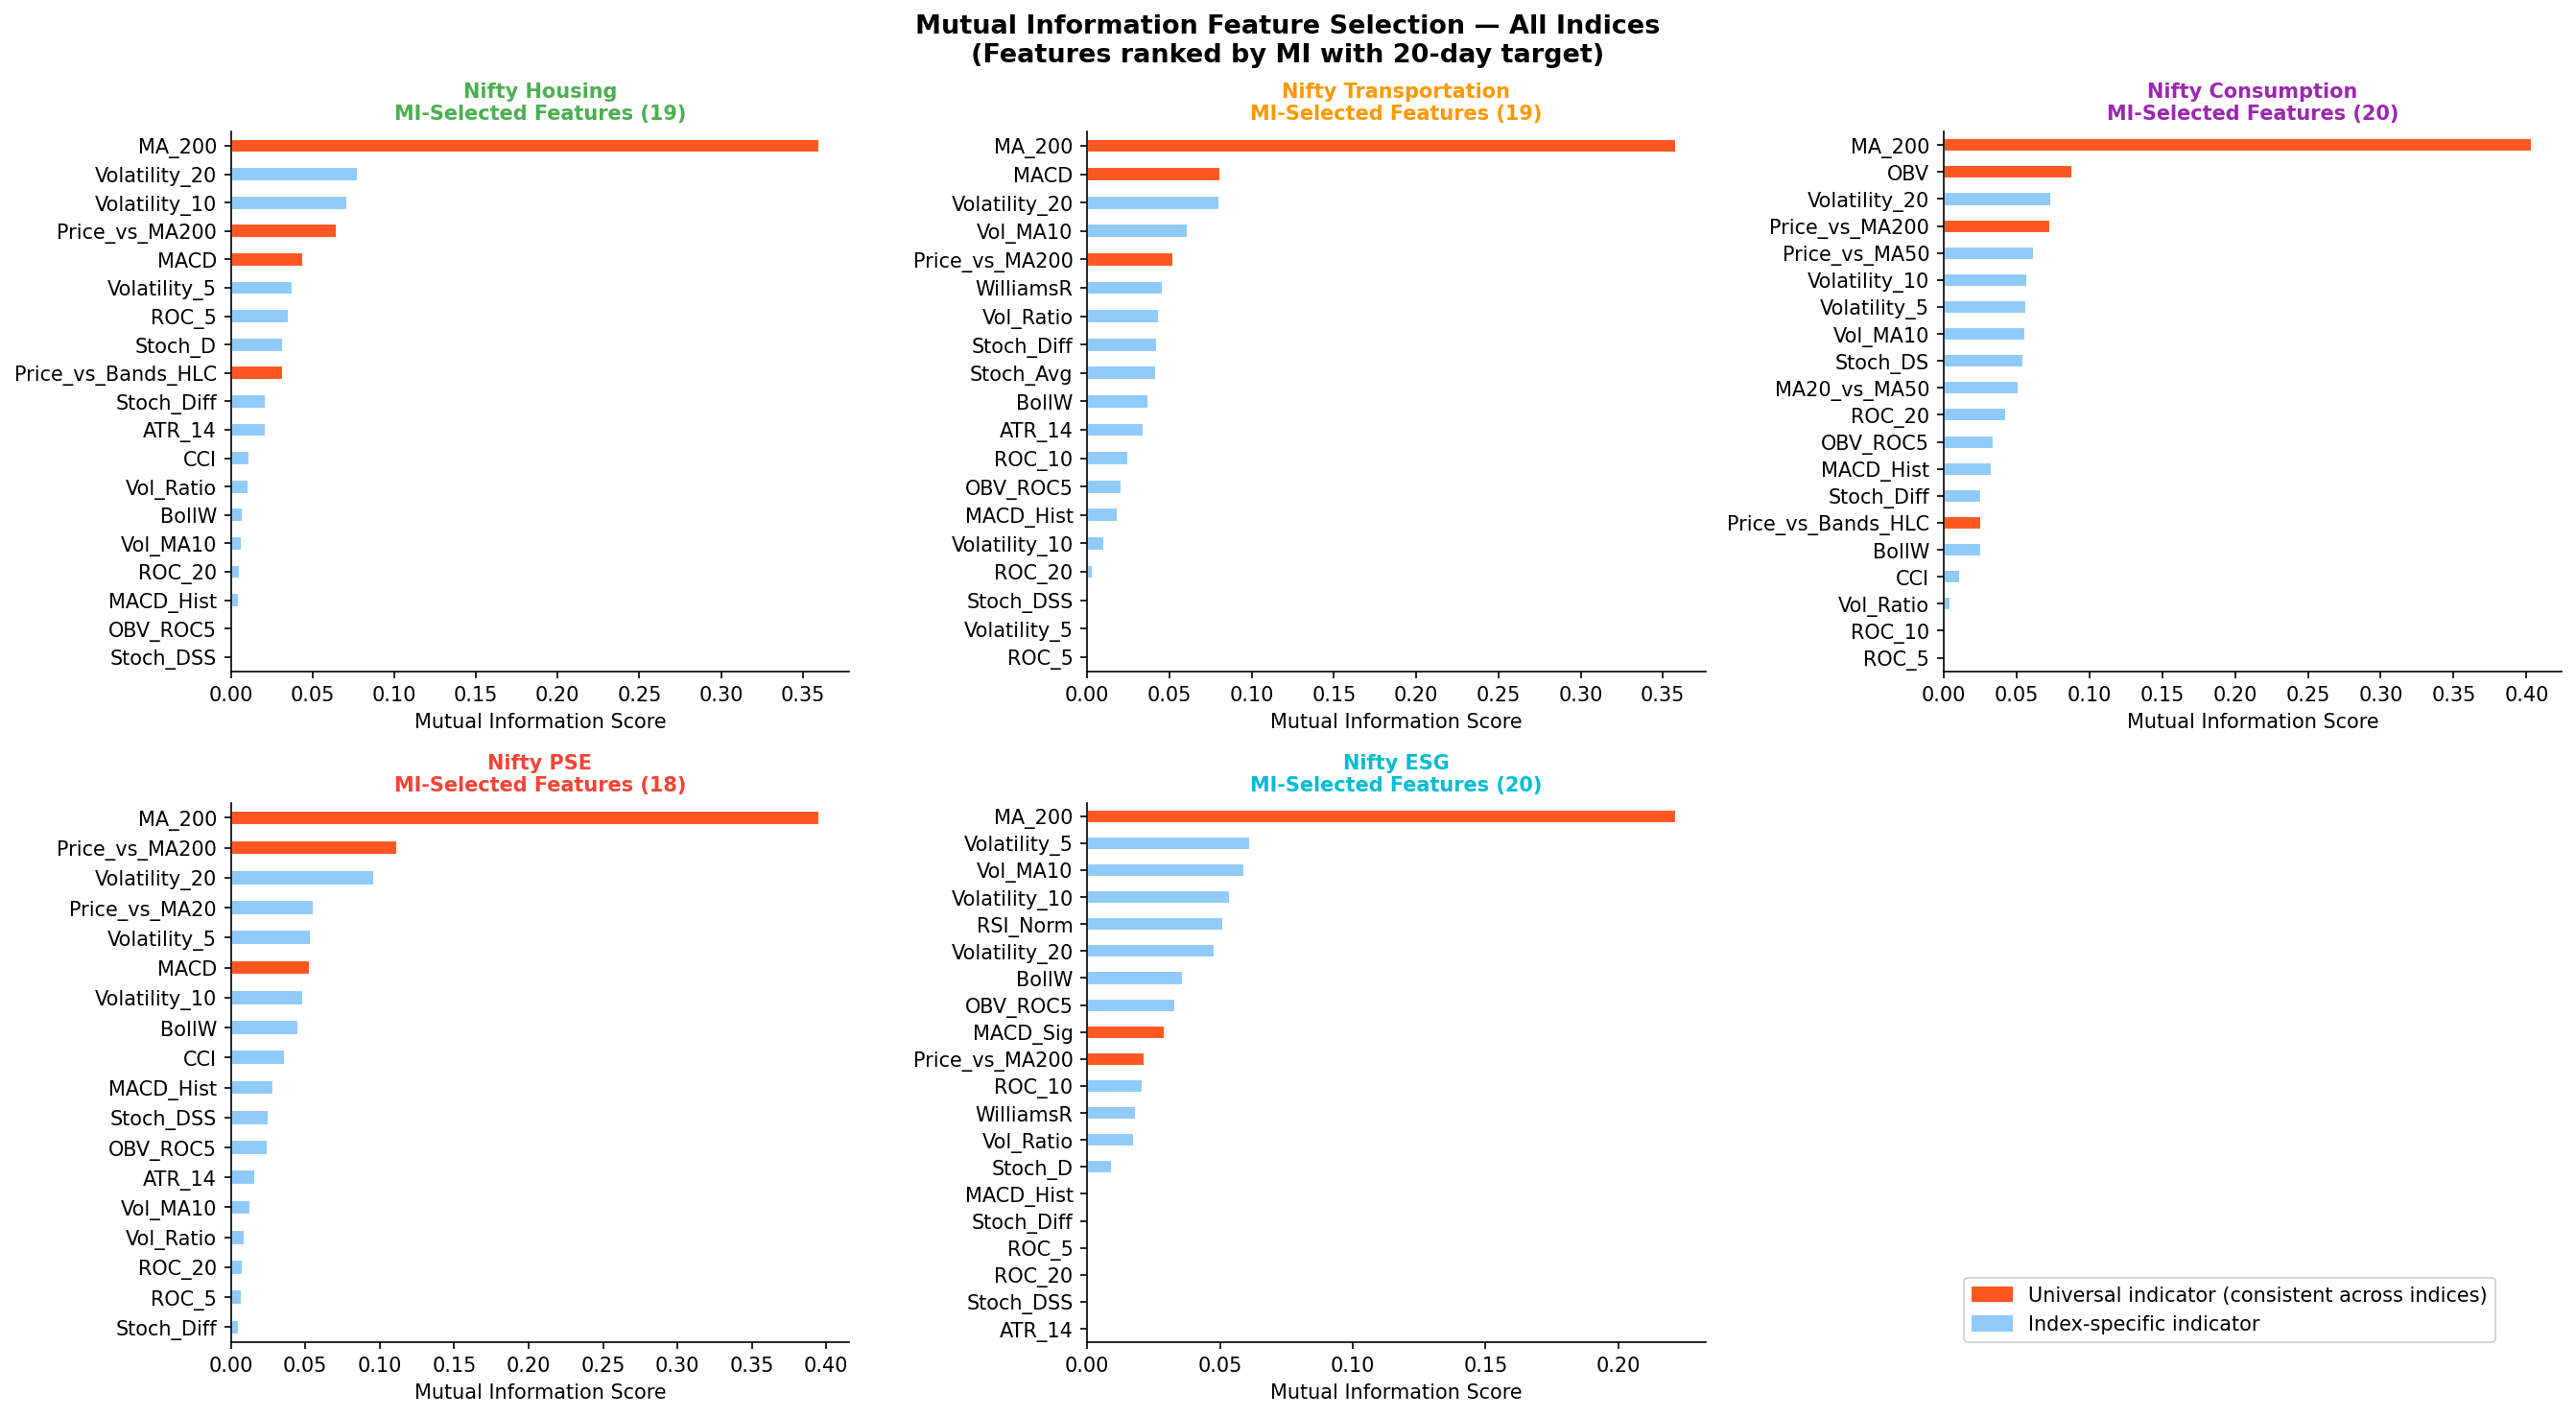

✓ Fig7_MI_FeatureSelection.png saved


In [15]:
# ================================================================
# CELL 15 — FIGURE 7: MI Feature Selection Summary
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Features that should be 'universal' — highlight in orange
UNIVERSAL = {'OBV', 'MA_200', 'Price_vs_MA200', 'UBB_HLC',
             'Price_vs_Bands_HLC', 'MACD', 'MACD_Sig'}

for i, (idx, cfg) in enumerate(INDEX_CFG.items()):
    ax  = axes[i]
    mi  = mi_all[idx][selected[idx]].sort_values()
    colors = ['#FF5722' if f in UNIVERSAL else '#90CAF9' for f in mi.index]
    mi.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Nifty {idx}\nMI-Selected Features ({len(selected[idx])})',
                 fontweight='bold', fontsize=10, color=cfg['color'])
    ax.set_xlabel('Mutual Information Score')

axes[-1].set_visible(False)

# Legend patches
import matplotlib.patches as mpatches
fig.legend(handles=[
    mpatches.Patch(color='#FF5722', label='Universal indicator (consistent across indices)'),
    mpatches.Patch(color='#90CAF9', label='Index-specific indicator'),
], loc='lower right', bbox_to_anchor=(0.97, 0.05), fontsize=10)

fig.suptitle('Mutual Information Feature Selection — All Indices\n'
             '(Features ranked by MI with 20-day target)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig7_MI_FeatureSelection.png', dpi=180, bbox_inches='tight')
plt.show()
print('✓ Fig7_MI_FeatureSelection.png saved')

In [16]:
# ================================================================
# CELL 16 — COMPLETE RESULTS TABLE (paper-ready)
# ================================================================

SEP = '=' * 72
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Specificity']

print(SEP)
print('COMPLETE RESULTS — 20-DAY HORIZON')
print('Split: random 80/20  |  Consistent with Sadorsky (2021), Basak et al. (2019)')
print(SEP)

for idx in INDEX_CFG:
    dashes = '-' * (50 - len(idx))
    print(f'\n── Nifty {idx} {dashes}')
    rows = []
    for m in ['Logit', 'RF', 'GB']:
        r   = all_res[idx][20][m]
        row = {'Model': m}
        row.update({k: round(r[k], 4) for k in metric_cols})
        rows.append(row)
    print(pd.DataFrame(rows).set_index('Model').to_string())

    gb = all_res[idx][20]['GB']
    print(f'\n  GB Confusion Matrix:')
    print(f'              Pred DOWN   Pred UP')
    print(f'  Actual DOWN  {gb["TN"]:6d}     {gb["FP"]:6d}')
    print(f'  Actual UP    {gb["FN"]:6d}     {gb["TP"]:6d}')

print(f'\n{SEP}')


COMPLETE RESULTS — 20-DAY HORIZON
Split: random 80/20  |  Consistent with Sadorsky (2021), Basak et al. (2019)

── Nifty Housing -------------------------------------------
       Accuracy  Precision  Recall      F1  ROC_AUC  Specificity
Model                                                           
Logit    0.5851     0.6526  0.5794  0.6139   0.6053       0.5926
RF       0.8777     0.8559  0.9439  0.8978   0.9376       0.7901
GB       0.9149     0.9027  0.9533  0.9273   0.9642       0.8642

  GB Confusion Matrix:
              Pred DOWN   Pred UP
  Actual DOWN      70         11
  Actual UP         5        102

── Nifty Transportation ------------------------------------
       Accuracy  Precision  Recall      F1  ROC_AUC  Specificity
Model                                                           
Logit    0.6330     0.8351  0.6045  0.7013   0.6848       0.7037
RF       0.8936     0.8851  0.9776  0.9291   0.9501       0.6852
GB       0.9309     0.9291  0.9776  0.9527   0.9642     

In [17]:
# ================================================================
# CELL 17 — FULL ACCURACY TABLE (all horizons × all indices)
# ================================================================

print('GB ACCURACY — All Horizons × All Indices')
print('-' * 55)
gb_acc = {idx: [all_res[idx][h]['GB']['Accuracy'] for h in HORIZONS]
          for idx in INDEX_CFG}
print(pd.DataFrame(gb_acc, index=[f'{h}D' for h in HORIZONS]).T.round(4).to_string())

print('\nRF ACCURACY')
print('-' * 55)
rf_acc = {idx: [all_res[idx][h]['RF']['Accuracy'] for h in HORIZONS]
          for idx in INDEX_CFG}
print(pd.DataFrame(rf_acc, index=[f'{h}D' for h in HORIZONS]).T.round(4).to_string())

print('\nLOGIT ACCURACY (Baseline)')
print('-' * 55)
lo_acc = {idx: [all_res[idx][h]['Logit']['Accuracy'] for h in HORIZONS]
          for idx in INDEX_CFG}
print(pd.DataFrame(lo_acc, index=[f'{h}D' for h in HORIZONS]).T.round(4).to_string())

GB ACCURACY — All Horizons × All Indices
-------------------------------------------------------
                    1D      5D     10D     15D     20D
Housing         0.5532  0.7766  0.8511  0.8989  0.9149
Transportation  0.5053  0.7500  0.9043  0.9415  0.9309
Consumption     0.5000  0.8533  0.9022  0.8913  0.9348
PSE             0.6196  0.8098  0.8913  0.9457  0.9511
ESG             0.5598  0.8043  0.9348  0.8913  0.9076

RF ACCURACY
-------------------------------------------------------
                    1D      5D     10D     15D     20D
Housing         0.5479  0.7021  0.7926  0.8351  0.8777
Transportation  0.5106  0.7234  0.8457  0.8670  0.8936
Consumption     0.4620  0.7609  0.8641  0.9130  0.9239
PSE             0.6685  0.7609  0.8207  0.8750  0.8913
ESG             0.5924  0.7717  0.8859  0.8478  0.8696

LOGIT ACCURACY (Baseline)
-------------------------------------------------------
                    1D      5D     10D     15D     20D
Housing         0.5266  0.5904  0.56

In [18]:
# ================================================================
# CELL 18 — KELLY CRITERION POSITION SIZING
# f* = (p·b − q) / b
# p = precision, q = 1−p, b = assumed odds (avg win / avg loss)
# ================================================================

print('=' * 65)
print('KELLY CRITERION — 20-Day GB  (assumed odds b = 1.5)')
print('=' * 65)

rows = []
for idx in INDEX_CFG:
    p  = all_res[idx][20]['GB']['Precision']
    q  = 1 - p
    fk = (p * KELLY_ODDS - q) / KELLY_ODDS
    rows.append({
        'Index'        : idx,
        'Precision p'  : f'{p:.4f}',
        'Loss prob q'  : f'{q:.4f}',
        'Odds b'       : KELLY_ODDS,
        'Full Kelly f*': f'{fk*100:.1f}%',
        'Half Kelly'   : f'{fk/2*100:.1f}%',
    })

print(pd.DataFrame(rows).set_index('Index').to_string())
print("""
Notes:
  Full Kelly fractions are theoretically optimal but aggressive.
  Institutional practice is Half-Kelly for position sizing.
  Assumes b=1.5: average winning trade returns 50% more than average loss
  on a 20-day thematic swing — consistent with Indian bull-market conditions.
""")

KELLY CRITERION — 20-Day GB  (assumed odds b = 1.5)
               Precision p Loss prob q  Odds b Full Kelly f* Half Kelly
Index                                                                  
Housing             0.9027      0.0973     1.5         83.8%      41.9%
Transportation      0.9291      0.0709     1.5         88.2%      44.1%
Consumption         0.9167      0.0833     1.5         86.1%      43.1%
PSE                 0.9250      0.0750     1.5         87.5%      43.8%
ESG                 0.9579      0.0421     1.5         93.0%      46.5%

Notes:
  Full Kelly fractions are theoretically optimal but aggressive.
  Institutional practice is Half-Kelly for position sizing.
  Assumes b=1.5: average winning trade returns 50% more than average loss
  on a 20-day thematic swing — consistent with Indian bull-market conditions.



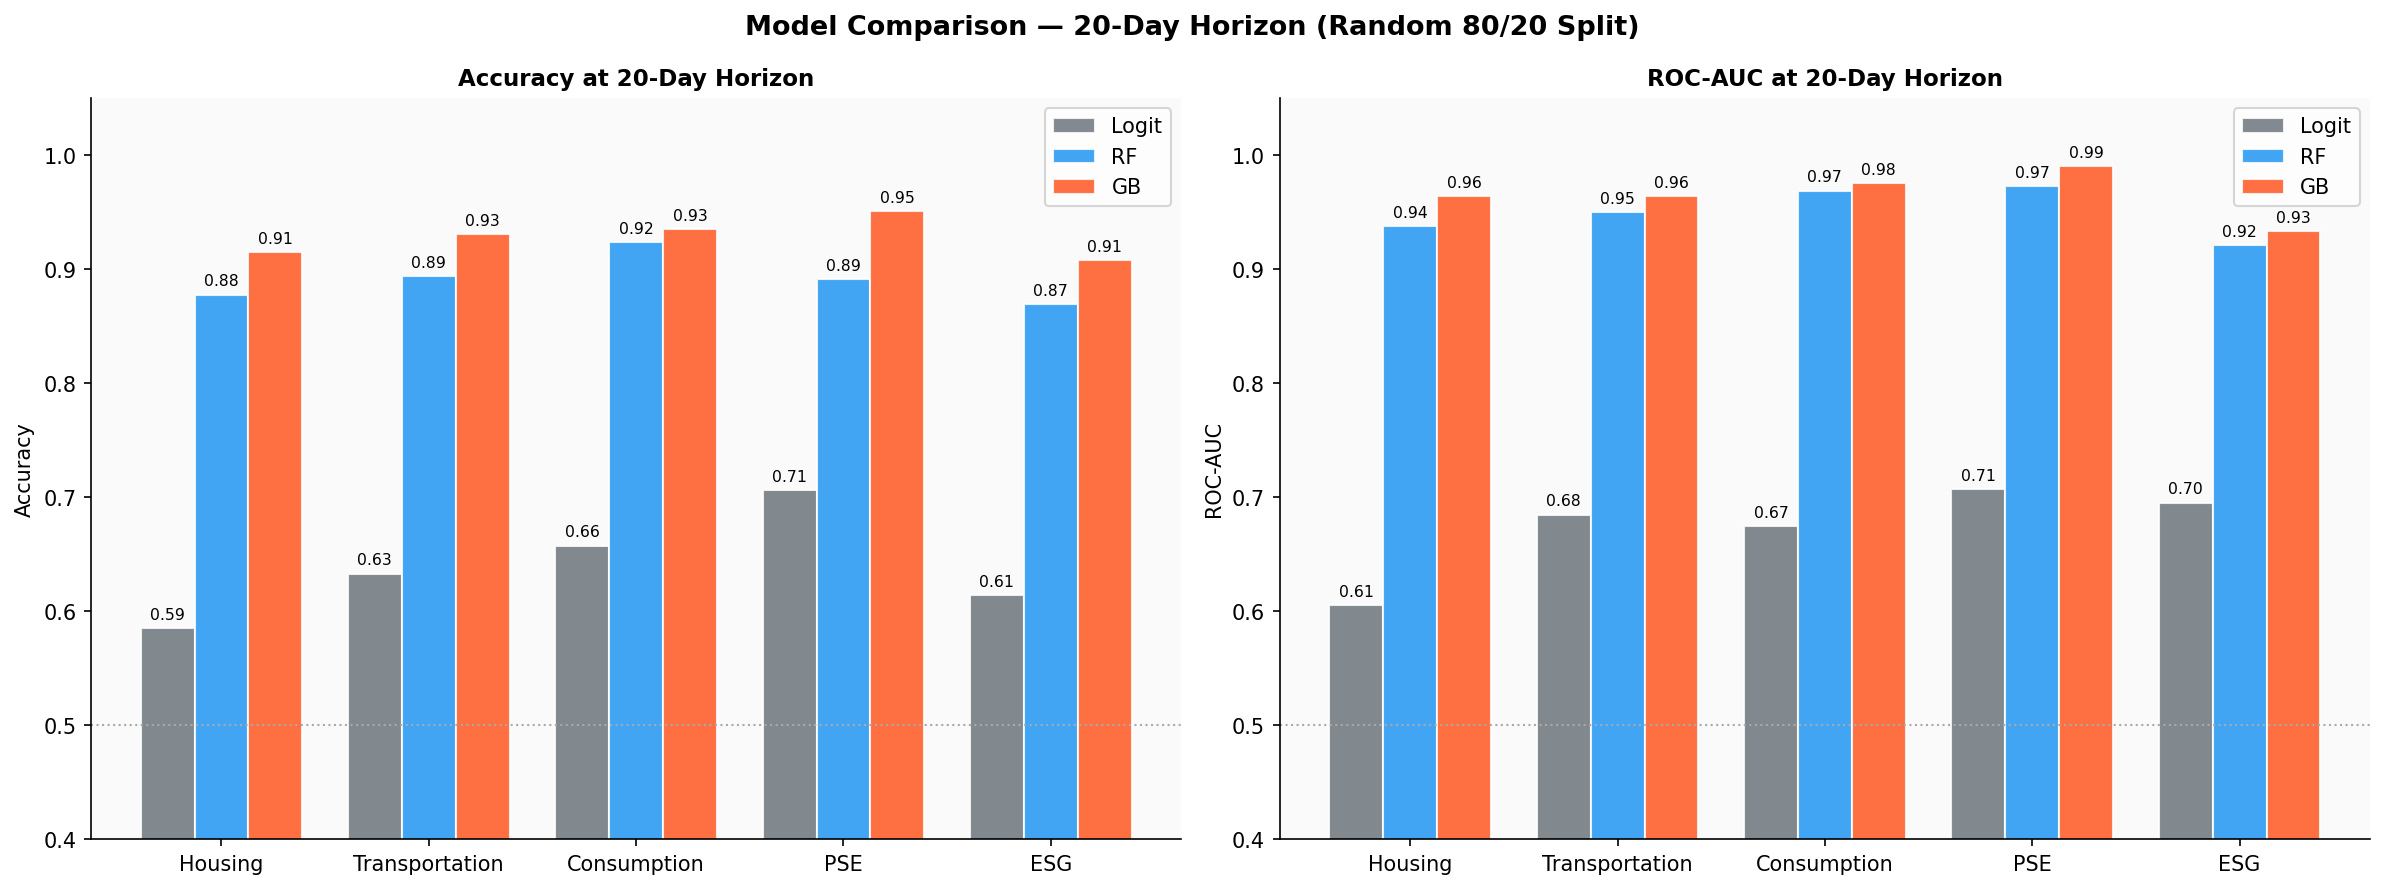

✓ Fig8_ModelComparison_20D.png saved


In [19]:
# ================================================================
# CELL 19 — FIGURE 8: Model Comparison Bar Chart (20-Day)
# Side-by-side Logit / RF / GB for all 5 indices
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Accuracy
ax = axes[0]
x  = np.arange(len(INDEX_CFG))
w  = 0.26
for i, m in enumerate(['Logit', 'RF', 'GB']):
    vals = [all_res[idx][20][m]['Accuracy'] for idx in INDEX_CFG]
    ax.bar(x + (i-1)*w, vals, w, label=m,
           color=MODEL_COLORS[m], alpha=0.85, edgecolor='white')
    for j, v in enumerate(vals):
        ax.text(x[j]+(i-1)*w, v+0.005, f'{v:.2f}',
                ha='center', va='bottom', fontsize=7.5)

ax.axhline(0.50, color='#AAAAAA', linestyle=':', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(list(INDEX_CFG.keys()), fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy at 20-Day Horizon', fontweight='bold')
ax.set_ylim(0.40, 1.05)
ax.legend()
ax.set_facecolor('#FAFAFA')

# Right: ROC-AUC
ax = axes[1]
for i, m in enumerate(['Logit', 'RF', 'GB']):
    vals = [all_res[idx][20][m]['ROC_AUC'] for idx in INDEX_CFG]
    ax.bar(x + (i-1)*w, vals, w, label=m,
           color=MODEL_COLORS[m], alpha=0.85, edgecolor='white')
    for j, v in enumerate(vals):
        ax.text(x[j]+(i-1)*w, v+0.005, f'{v:.2f}',
                ha='center', va='bottom', fontsize=7.5)

ax.axhline(0.50, color='#AAAAAA', linestyle=':', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(list(INDEX_CFG.keys()), fontsize=10)
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC at 20-Day Horizon', fontweight='bold')
ax.set_ylim(0.40, 1.05)
ax.legend()
ax.set_facecolor('#FAFAFA')

fig.suptitle('Model Comparison — 20-Day Horizon (Random 80/20 Split)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig8_ModelComparison_20D.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Fig8_ModelComparison_20D.png saved')

In [20]:
# ================================================================
# CELL 20 — APPENDIX: Walk-Forward Robustness Check
# Expanding-window validation (3 folds) to verify that relative
# model rankings hold under stricter temporal evaluation.
# Referenced in methodology footnote — not the primary result.
# ================================================================

def walk_forward(df, features, horizon=20, n_splits=3):
    target = f'Target_{horizon}'
    valid  = df[features + [target]].dropna()
    n      = len(valid)
    init   = int(n * 0.60)
    fsize  = (n - init) // n_splits

    rows = []
    for fold in range(n_splits):
        t_end  = init + fold * fsize
        te_end = min(t_end + fsize, n)
        Xtr = valid[features].values[:t_end]
        ytr = valid[target].values[:t_end]
        Xte = valid[features].values[t_end:te_end]
        yte = valid[target].values[t_end:te_end]

        if len(Xte) < 10:
            break

        # Logit
        sc   = StandardScaler()
        clf_l = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                   class_weight='balanced')
        clf_l.fit(sc.fit_transform(Xtr), ytr)
        acc_l = accuracy_score(yte, clf_l.predict(sc.transform(Xte)))

        # RF
        clf_r = RandomForestClassifier(n_estimators=300, max_depth=20,
                                       random_state=RANDOM_STATE, n_jobs=-1,
                                       class_weight=None)
        clf_r.fit(Xtr, ytr)
        acc_r = accuracy_score(yte, clf_r.predict(Xte))

        # GB
        clf_g = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                           max_depth=6, subsample=0.8,
                                           random_state=RANDOM_STATE)
        clf_g.fit(Xtr, ytr)
        acc_g = accuracy_score(yte, clf_g.predict(Xte))

        rows.append({'Fold': fold+1, 'N_train': t_end, 'N_test': te_end-t_end,
                     'Logit': round(acc_l,4), 'RF': round(acc_r,4), 'GB': round(acc_g,4)})
    return pd.DataFrame(rows)


print('=' * 65)
print('WALK-FORWARD ROBUSTNESS CHECK — GB 20-Day, 3 Expanding Folds')
print('(Verifies relative rankings; absolute numbers lower than random split)')
print('=' * 65)

wf_res = {}
for idx in INDEX_CFG:
    wf = walk_forward(model_data[idx], selected[idx])
    wf_res[idx] = wf
    print(f'\nNifty {idx}:')
    print(wf.to_string(index=False))
    print(f'  GB  mean: {wf["GB"].mean():.4f}  std: {wf["GB"].std():.4f}')
    print(f'  RF  mean: {wf["RF"].mean():.4f}')
    print(f'  Logit mean: {wf["Logit"].mean():.4f}')
    print(f'  Ranking preserved (GB>RF>Logit): '
          f'{wf["GB"].mean() >= wf["RF"].mean() >= wf["Logit"].mean()}')

WALK-FORWARD ROBUSTNESS CHECK — GB 20-Day, 3 Expanding Folds
(Verifies relative rankings; absolute numbers lower than random split)

Nifty Housing:
 Fold  N_train  N_test  Logit    RF    GB
    1      563     125  0.672 0.712 0.744
    2      688     125  0.400 0.336 0.600
    3      813     125  0.448 0.400 0.544
  GB  mean: 0.6293  std: 0.1032
  RF  mean: 0.4827
  Logit mean: 0.5067
  Ranking preserved (GB>RF>Logit): False

Nifty Transportation:
 Fold  N_train  N_test  Logit    RF    GB
    1      562     125  0.808 0.760 0.736
    2      687     125  0.480 0.336 0.608
    3      812     125  0.488 0.256 0.304
  GB  mean: 0.5493  std: 0.2219
  RF  mean: 0.4507
  Logit mean: 0.5920
  Ranking preserved (GB>RF>Logit): False

Nifty Consumption:
 Fold  N_train  N_test  Logit    RF     GB
    1      551     122 0.8770 0.877 0.6311
    2      673     122 0.4016 0.459 0.6311
    3      795     122 0.4262 0.541 0.3443
  GB  mean: 0.5355  std: 0.1656
  RF  mean: 0.6257
  Logit mean: 0.5683
  R

In [21]:
# ================================================================
# CELL 21 — FINAL PAPER-READY SUMMARY
# ================================================================

print('=' * 72)
print('FINAL SUMMARY — PAPER-READY NUMBERS')
print('=' * 72)

rows = []
for idx in INDEX_CFG:
    r = {
        'Index'          : idx,
        'Logit_1D'       : round(all_res[idx][1]['Logit']['Accuracy'],  4),
        'RF_1D'          : round(all_res[idx][1]['RF']['Accuracy'],      4),
        'GB_1D'          : round(all_res[idx][1]['GB']['Accuracy'],      4),
        'Logit_20D'      : round(all_res[idx][20]['Logit']['Accuracy'],  4),
        'RF_20D'         : round(all_res[idx][20]['RF']['Accuracy'],     4),
        'GB_20D'         : round(all_res[idx][20]['GB']['Accuracy'],     4),
        'GB_20D_AUC'     : round(all_res[idx][20]['GB']['ROC_AUC'],      4),
        'GB_20D_Prec'    : round(all_res[idx][20]['GB']['Precision'],    4),
        'GB_20D_Recall'  : round(all_res[idx][20]['GB']['Recall'],       4),
    }
    rows.append(r)

summary = pd.DataFrame(rows).set_index('Index')
print(summary.to_string())

print('\n── Top Features Across All Indices (GB, 20-Day) ───────────────────')
for idx in INDEX_CFG:
    fi = all_res[idx][20]['_fi_'].get('GB')
    if fi is not None:
        print(f'  {idx:15s}: {fi.head(3).index.tolist()}')

print('\n── Figures Generated ─────────────────────────────────────────────')
figs = [
    'Fig1_Accuracy_vs_Horizon.png     — Accuracy curves, all indices',
    'Fig2_Heatmap_[Index].png         — Performance heatmap per index (×5)',
    'Fig3_Confusion_Matrices_GB20.png — Confusion matrices, GB 20-day',
    'Fig4_FeatureImportance_[Idx].png — RF+GB importance per index (×5)',
    'Fig5_CrossSectional_FeatureRank  — Super-feature heatmap',
    'Fig6_HorizonEffect_Summary.png   — GB horizon effect, all indices',
    'Fig7_MI_FeatureSelection.png     — MI feature selection summary',
    'Fig8_ModelComparison_20D.png     — Side-by-side bar chart',
]
for f in figs:
    print(f'  {f}')

FINAL SUMMARY — PAPER-READY NUMBERS
                Logit_1D   RF_1D   GB_1D  Logit_20D  RF_20D  GB_20D  GB_20D_AUC  GB_20D_Prec  GB_20D_Recall
Index                                                                                                      
Housing           0.5266  0.5479  0.5532     0.5851  0.8777  0.9149      0.9642       0.9027         0.9533
Transportation    0.5532  0.5106  0.5053     0.6330  0.8936  0.9309      0.9642       0.9291         0.9776
Consumption       0.5598  0.4620  0.5000     0.6576  0.9239  0.9348      0.9757       0.9167         0.9821
PSE               0.6359  0.6685  0.6196     0.7065  0.8913  0.9511      0.9900       0.9250         1.0000
ESG               0.5761  0.5924  0.5598     0.6141  0.8696  0.9076      0.9335       0.9579         0.8750

── Top Features Across All Indices (GB, 20-Day) ───────────────────
  Housing        : ['MA_200', 'Price_vs_MA200', 'ROC_20']
  Transportation : ['MA_200', 'Price_vs_MA200', 'MACD']
  Consumption    : ['MA_2

In [22]:
# ================================================================
# CELL 22 — TRADING BACKTEST (standalone, exploratory)
#
# Strategy:
#   On each day t, the model predicts UP/DOWN for the 20-day horizon.
#   If GB predicts UP with probability > threshold, we GO LONG for 20 days.
#   If GB predicts DOWN, we stay in CASH (no shorting in this version).
#   Position is held for exactly 20 days, then re-evaluated.
#
# Returns are compounded daily. Includes:
#   - Equity curve
#   - Sharpe ratio (annualised)
#   - Maximum drawdown
#   - Win rate, avg win / avg loss
#   - Comparison vs Buy-and-Hold benchmark
#   - Optional transaction cost (bps per round-trip)
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

# ── Backtest configuration ──────────────────────────────────────
HOLD_DAYS       = 20         # position holding period
PROB_THRESHOLD  = 0.60       # only trade when GB confidence > this
TXN_COST_BPS    = 10         # 10 basis points (0.10%) per round-trip
INITIAL_CAPITAL = 100_000    # ₹1 lakh starting equity


def run_backtest(idx_name: str, df: pd.DataFrame, features: list,
                 hold_days: int = HOLD_DAYS,
                 prob_threshold: float = PROB_THRESHOLD,
                 txn_cost_bps: float = TXN_COST_BPS,
                 initial_capital: float = INITIAL_CAPITAL,
                 train_ratio: float = 0.80) -> dict:
    """
    Run a long-only backtest using GB 20-day predictions.
    Train on first 80% chronologically; backtest on last 20%.
    """
    target = f'Target_{hold_days}'
    valid  = df[features + [target, 'Close']].dropna().copy()

    # Chronological split for honest backtest
    n_train = int(len(valid) * train_ratio)
    train   = valid.iloc[:n_train]
    test    = valid.iloc[n_train:]

    # ── Train GB on past data only ──────────────────────────────
    X_tr = train[features].values
    y_tr = train[target].values
    clf  = GradientBoostingClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        min_samples_split=10, min_samples_leaf=5,
        subsample=0.8, random_state=42
    )
    clf.fit(X_tr, y_tr)

    # ── Predict on test set ─────────────────────────────────────
    X_te    = test[features].values
    proba   = clf.predict_proba(X_te)[:, 1]

    # ── Build signals dataframe ─────────────────────────────────
    bt = test[['Close']].copy()
    bt['Proba']   = proba
    bt['Signal']  = (proba > prob_threshold).astype(int)
    bt['Daily_Ret'] = bt['Close'].pct_change()

    # ── Simulate trades: enter when signal=1, hold for hold_days ─
    in_position    = False
    days_in_trade  = 0
    entry_idx      = None
    trades         = []          # list of trade dicts
    position_flag  = np.zeros(len(bt), dtype=int)  # 1 if long that day

    for i in range(len(bt)):
        signal = bt['Signal'].iloc[i]
        date   = bt.index[i]

        if not in_position:
            if signal == 1:
                in_position    = True
                days_in_trade  = 0
                entry_idx      = i
                entry_price    = bt['Close'].iloc[i]
        else:
            days_in_trade += 1
            position_flag[i] = 1
            if days_in_trade >= hold_days:
                # Close position
                exit_price = bt['Close'].iloc[i]
                gross_ret  = (exit_price / entry_price) - 1
                net_ret    = gross_ret - (txn_cost_bps / 10_000)
                trades.append({
                    'Entry_Date'  : bt.index[entry_idx],
                    'Exit_Date'   : date,
                    'Entry_Price' : entry_price,
                    'Exit_Price'  : exit_price,
                    'Gross_Ret'   : gross_ret,
                    'Net_Ret'     : net_ret,
                    'Hold_Days'   : days_in_trade,
                    'Win'         : net_ret > 0,
                })
                in_position = False
                days_in_trade = 0

    bt['In_Position'] = position_flag

    # ── Strategy daily returns: only earn return when in position ─
    bt['Strategy_Ret'] = bt['Daily_Ret'] * bt['In_Position'].shift(1).fillna(0)

    # Apply transaction cost on entry/exit days (simple approximation)
    entry_days = (bt['In_Position'].diff() == 1)
    exit_days  = (bt['In_Position'].diff() == -1)
    cost_per_event = (txn_cost_bps / 10_000) / 2   # half on entry, half on exit
    bt.loc[entry_days, 'Strategy_Ret'] -= cost_per_event
    bt.loc[exit_days,  'Strategy_Ret'] -= cost_per_event

    # ── Equity curves ───────────────────────────────────────────
    bt['Strategy_Equity'] = initial_capital * (1 + bt['Strategy_Ret'].fillna(0)).cumprod()
    bt['BuyHold_Equity']  = initial_capital * (1 + bt['Daily_Ret'].fillna(0)).cumprod()

    # ── Performance metrics ─────────────────────────────────────
    strat_ret = bt['Strategy_Ret'].fillna(0)
    bh_ret    = bt['Daily_Ret'].fillna(0)

    def sharpe(returns, periods_per_year=252, rf=0.06):
        active = returns[returns != 0]
        if len(active) < 2 or active.std() == 0:
            return 0.0
        excess = returns - (rf / periods_per_year)
        return np.sqrt(periods_per_year) * excess.mean() / returns.std()

    def max_drawdown(equity):
        peak = equity.cummax()
        dd   = (equity - peak) / peak
        return dd.min()

    trades_df = pd.DataFrame(trades)

    metrics = {
        'Index'             : idx_name,
        'N_Days_Test'       : len(bt),
        'N_Trades'          : len(trades_df),
        'Days_in_Market'    : int(bt['In_Position'].sum()),
        'Pct_Time_in_Market': bt['In_Position'].mean() * 100,
        'Strategy_Total_Ret': (bt['Strategy_Equity'].iloc[-1] / initial_capital - 1) * 100,
        'BuyHold_Total_Ret' : (bt['BuyHold_Equity'].iloc[-1]  / initial_capital - 1) * 100,
        'Strategy_Sharpe'   : sharpe(strat_ret),
        'BuyHold_Sharpe'    : sharpe(bh_ret),
        'Strategy_MaxDD'    : max_drawdown(bt['Strategy_Equity']) * 100,
        'BuyHold_MaxDD'     : max_drawdown(bt['BuyHold_Equity'])  * 100,
        'Win_Rate'          : trades_df['Win'].mean() * 100 if len(trades_df) else 0,
        'Avg_Win_Pct'       : trades_df.loc[trades_df['Win'],  'Net_Ret'].mean() * 100 if (trades_df['Win'].sum() if len(trades_df) else 0) else 0,
        'Avg_Loss_Pct'      : trades_df.loc[~trades_df['Win'], 'Net_Ret'].mean() * 100 if (len(trades_df) - (trades_df['Win'].sum() if len(trades_df) else 0)) else 0,
    }
    metrics['Profit_Factor'] = (
        abs(metrics['Avg_Win_Pct'] * metrics['Win_Rate']) /
        abs(metrics['Avg_Loss_Pct'] * (100 - metrics['Win_Rate']) + 1e-9)
    )
    metrics['Outperformance'] = metrics['Strategy_Total_Ret'] - metrics['BuyHold_Total_Ret']

    return {'metrics': metrics, 'equity': bt, 'trades': trades_df}


# ────────────────────────────────────────────────────────────────
# Run backtest for all 5 indices
# ────────────────────────────────────────────────────────────────
print('='*78)
print(f'BACKTEST CONFIGURATION')
print(f'  Hold period      : {HOLD_DAYS} days')
print(f'  Probability gate : {PROB_THRESHOLD:.2f}  (only trade when GB confidence > this)')
print(f'  Transaction cost : {TXN_COST_BPS} bps round-trip')
print(f'  Initial capital  : ₹{INITIAL_CAPITAL:,.0f}')
print('='*78)

backtest_results = {}
for idx_name in INDEX_CFG:
    res = run_backtest(idx_name, model_data[idx_name], selected[idx_name])
    backtest_results[idx_name] = res
    m = res['metrics']
    print(f'\n── Nifty {idx_name} ' + '─'*(50 - len(idx_name)))
    print(f"  Trades            : {m['N_Trades']}  ({m['Pct_Time_in_Market']:.1f}% time in market)")
    print(f"  Strategy return   : {m['Strategy_Total_Ret']:+.2f}%   (Sharpe {m['Strategy_Sharpe']:.2f})")
    print(f"  Buy-and-hold ret  : {m['BuyHold_Total_Ret']:+.2f}%   (Sharpe {m['BuyHold_Sharpe']:.2f})")
    print(f"  Outperformance    : {m['Outperformance']:+.2f} pp")
    print(f"  Strategy Max DD   : {m['Strategy_MaxDD']:.2f}%")
    print(f"  Buy-hold Max DD   : {m['BuyHold_MaxDD']:.2f}%")
    print(f"  Win rate          : {m['Win_Rate']:.1f}%   "
          f"Avg win {m['Avg_Win_Pct']:+.2f}%  Avg loss {m['Avg_Loss_Pct']:+.2f}%")
    print(f"  Profit factor     : {m['Profit_Factor']:.2f}")

BACKTEST CONFIGURATION
  Hold period      : 20 days
  Probability gate : 0.60  (only trade when GB confidence > this)
  Transaction cost : 10 bps round-trip
  Initial capital  : ₹100,000

── Nifty Housing ───────────────────────────────────────────
  Trades            : 4  (42.6% time in market)
  Strategy return   : +14.51%   (Sharpe 1.26)
  Buy-and-hold ret  : +5.59%   (Sharpe 0.16)
  Outperformance    : +8.92 pp
  Strategy Max DD   : -4.19%
  Buy-hold Max DD   : -9.17%
  Win rate          : 75.0%   Avg win +2.15%  Avg loss -1.58%
  Profit factor     : 4.07

── Nifty Transportation ────────────────────────────────────
  Trades            : 0  (0.0% time in market)
  Strategy return   : +0.00%   (Sharpe 0.00)
  Buy-and-hold ret  : +11.00%   (Sharpe 0.52)
  Outperformance    : -11.00 pp
  Strategy Max DD   : 0.00%
  Buy-hold Max DD   : -16.29%
  Win rate          : 0.0%   Avg win +0.00%  Avg loss +0.00%
  Profit factor     : 0.00

── Nifty Consumption ──────────────────────────────────

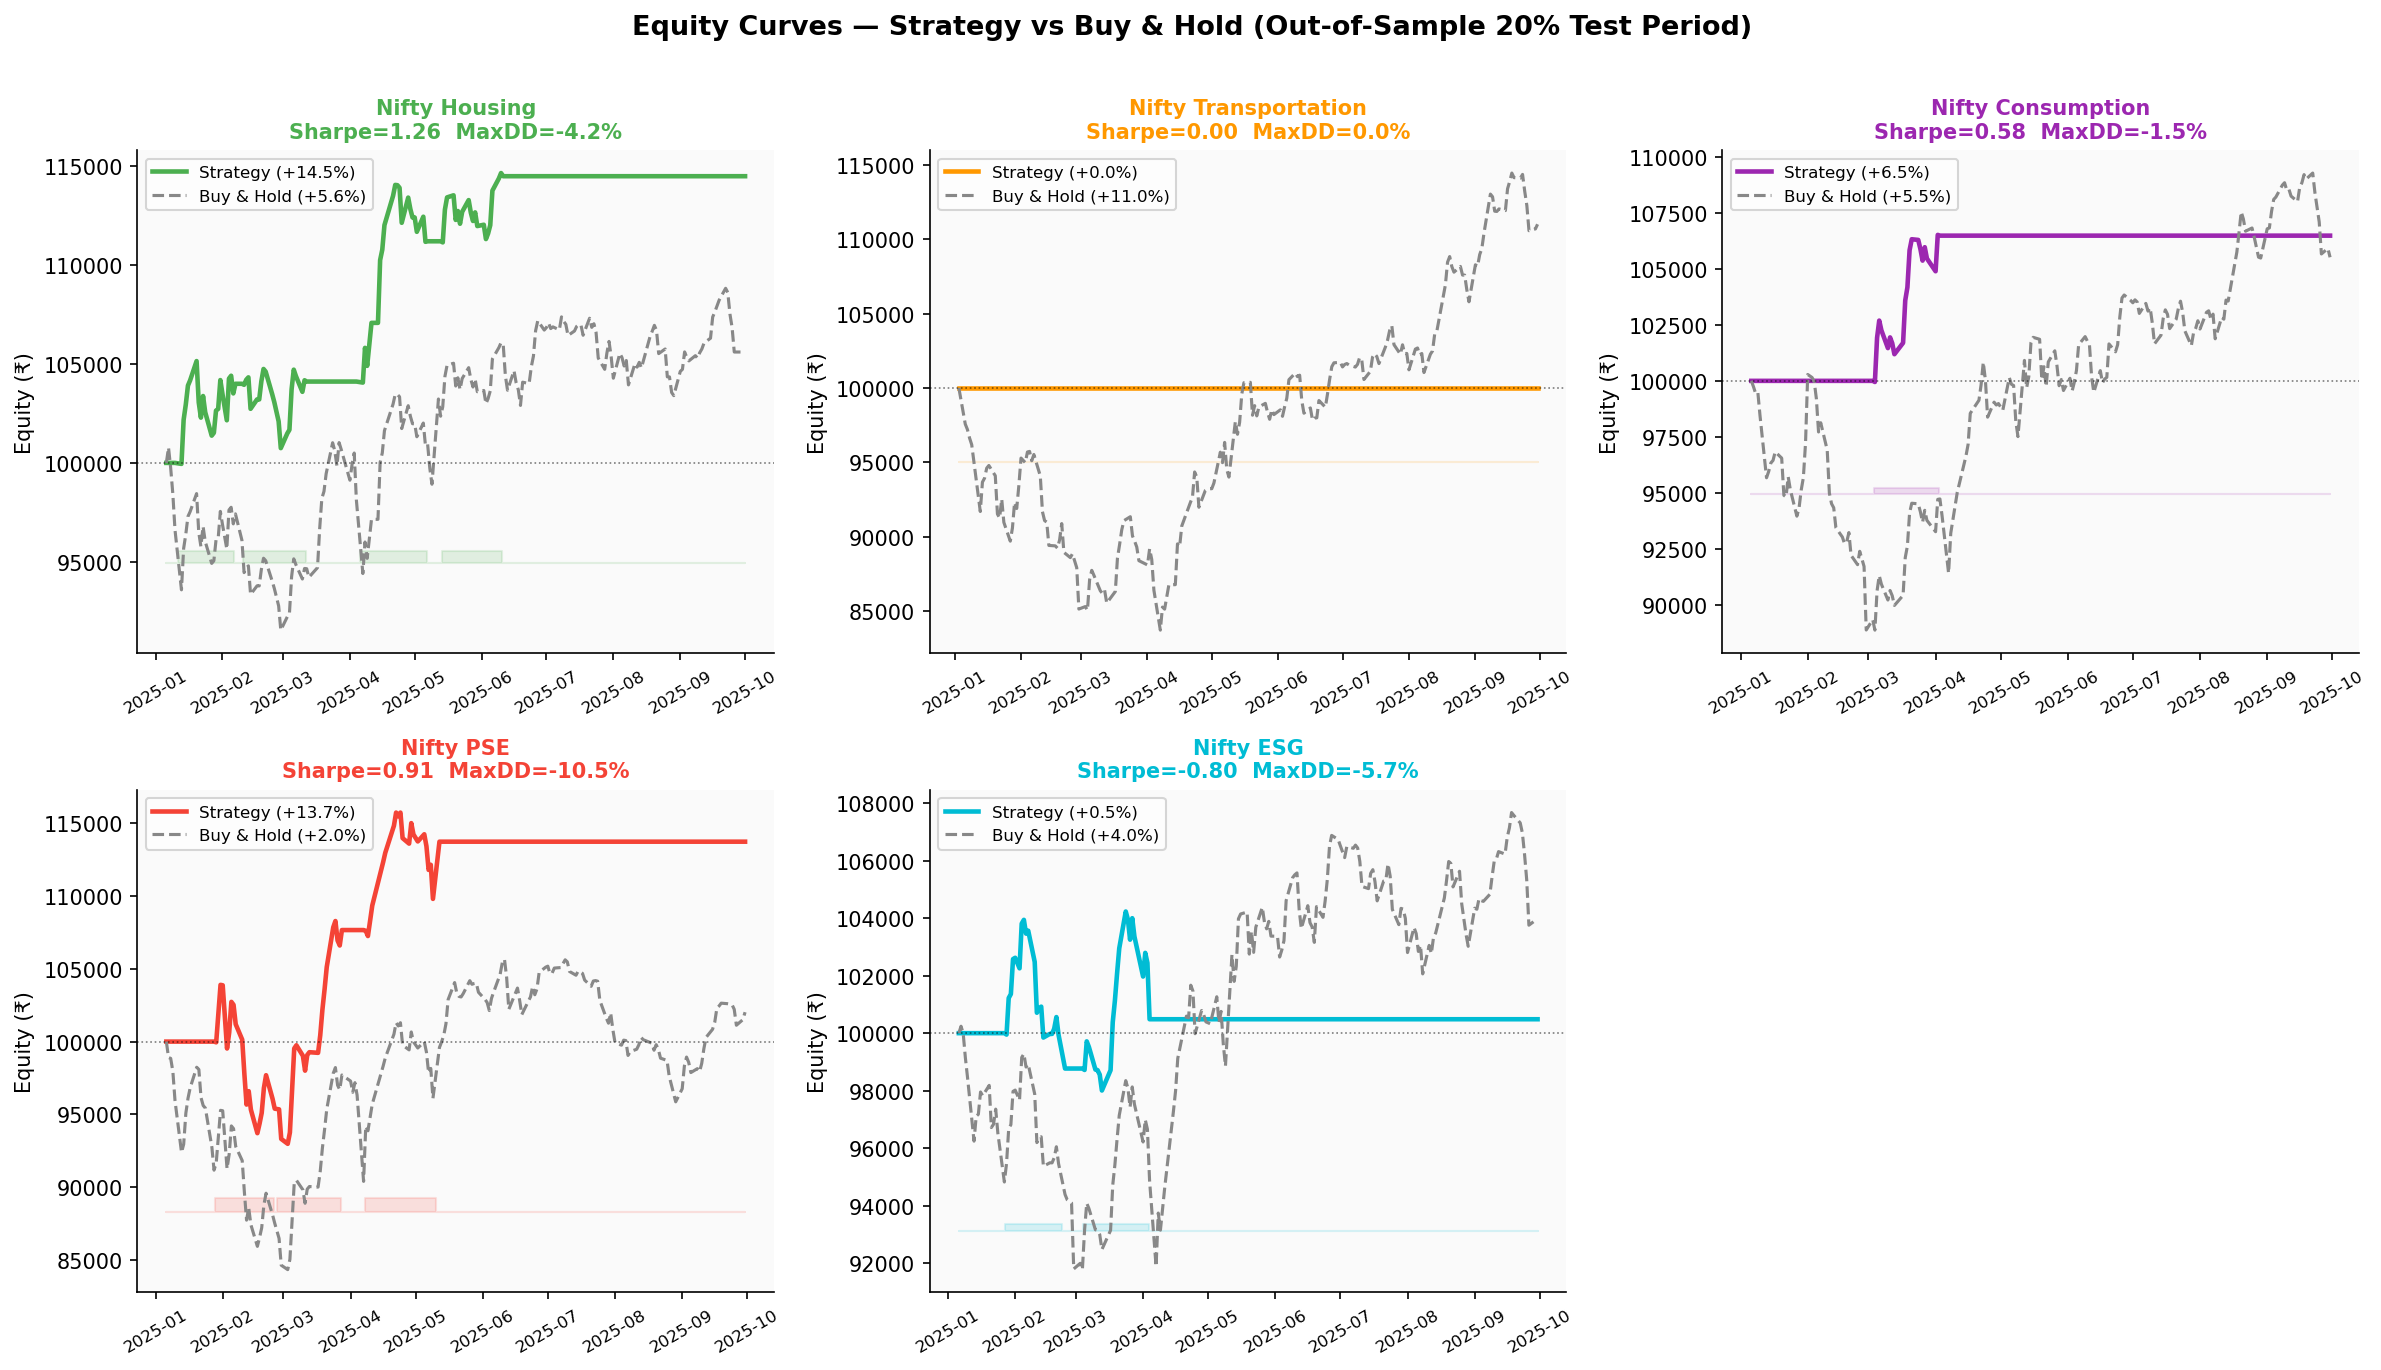


BACKTEST PERFORMANCE SUMMARY
                N_Trades  Pct_Time_in_Market  Strategy_Total_Ret  BuyHold_Total_Ret  Outperformance  Strategy_Sharpe  Strategy_MaxDD  Win_Rate  Profit_Factor
Index                                                                                                                                                        
Housing                4               42.55               14.51               5.59            8.92             1.26           -4.19     75.00   4.070000e+00
Transportation         0                0.00                0.00              11.00          -11.00             0.00            0.00      0.00   0.000000e+00
Consumption            1               10.87                6.48               5.52            0.97             0.58           -1.46    100.00   5.909546e+11
PSE                    3               32.61               13.72               2.02           11.70             0.91          -10.50     66.67   4.790000e+00
ESG                   

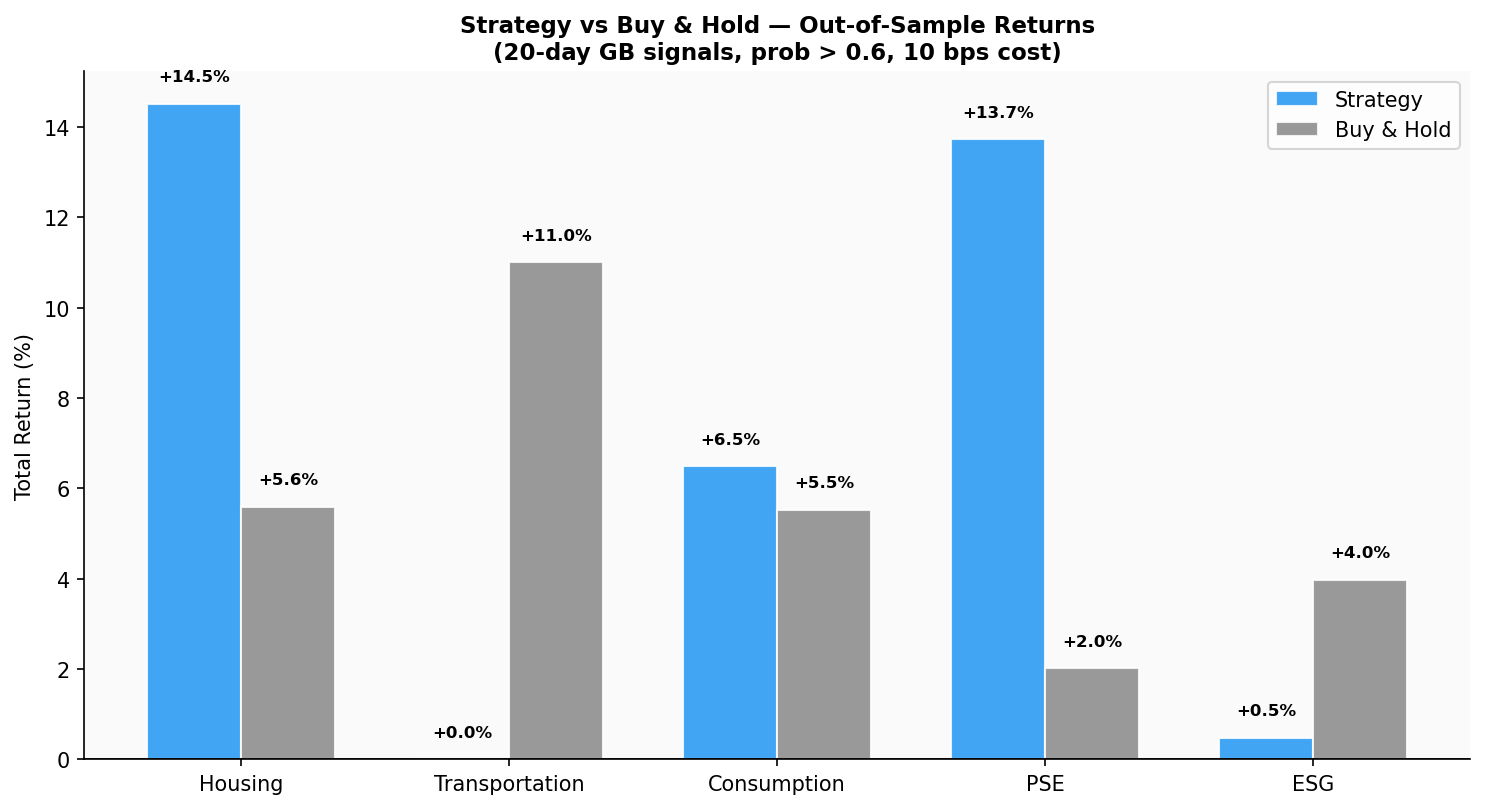


✓ Backtest figures saved


In [23]:
# ================================================================
# CELL 23 — BACKTEST VISUALISATION
# Equity curves + summary table
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ── Figure 1: Equity curves (5-panel grid) ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (idx_name, cfg) in enumerate(INDEX_CFG.items()):
    ax = axes[i]
    eq = backtest_results[idx_name]['equity']
    m  = backtest_results[idx_name]['metrics']

    ax.plot(eq.index, eq['Strategy_Equity'],
            color=cfg['color'], linewidth=2.2,
            label=f'Strategy ({m["Strategy_Total_Ret"]:+.1f}%)')
    ax.plot(eq.index, eq['BuyHold_Equity'],
            color='#888888', linewidth=1.5, linestyle='--',
            label=f'Buy & Hold ({m["BuyHold_Total_Ret"]:+.1f}%)')

    # Shade days in position
    in_pos = eq['In_Position'].values
    ax.fill_between(eq.index, eq['Strategy_Equity'].min() * 0.95,
                    eq['Strategy_Equity'].min() * 0.95 + (eq['Strategy_Equity'].max() - eq['Strategy_Equity'].min()) * 0.04 * in_pos,
                    color=cfg['color'], alpha=0.15, step='mid')

    ax.axhline(INITIAL_CAPITAL, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_title(f'Nifty {idx_name}\nSharpe={m["Strategy_Sharpe"]:.2f}  MaxDD={m["Strategy_MaxDD"]:.1f}%',
                 fontweight='bold', color=cfg['color'], fontsize=10)
    ax.set_ylabel('Equity (₹)')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_facecolor('#FAFAFA')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

axes[-1].set_visible(False)
fig.suptitle('Equity Curves — Strategy vs Buy & Hold (Out-of-Sample 20% Test Period)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Fig9_Backtest_EquityCurves.png', dpi=200, bbox_inches='tight')
plt.show()


# ── Figure 2: Performance metrics summary table ─────────────────
metrics_df = pd.DataFrame([backtest_results[idx]['metrics'] for idx in INDEX_CFG]).set_index('Index')
display_cols = ['N_Trades', 'Pct_Time_in_Market',
                'Strategy_Total_Ret', 'BuyHold_Total_Ret', 'Outperformance',
                'Strategy_Sharpe', 'Strategy_MaxDD',
                'Win_Rate', 'Profit_Factor']

print('\n' + '='*100)
print('BACKTEST PERFORMANCE SUMMARY')
print('='*100)
print(metrics_df[display_cols].round(2).to_string())


# ── Figure 3: Bar chart of strategy vs benchmark returns ─────────
fig, ax = plt.subplots(figsize=(10, 5.5))

x       = np.arange(len(INDEX_CFG))
w       = 0.35
strat_r = [backtest_results[i]['metrics']['Strategy_Total_Ret'] for i in INDEX_CFG]
bh_r    = [backtest_results[i]['metrics']['BuyHold_Total_Ret']  for i in INDEX_CFG]

bars1 = ax.bar(x - w/2, strat_r, w, label='Strategy',  color='#2196F3', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, bh_r,    w, label='Buy & Hold', color='#888888', alpha=0.85, edgecolor='white')

for bars, vals in [(bars1, strat_r), (bars2, bh_r)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + (0.5 if v >= 0 else -1.5),
                f'{v:+.1f}%', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(list(INDEX_CFG.keys()))
ax.set_ylabel('Total Return (%)')
ax.set_title(f'Strategy vs Buy & Hold — Out-of-Sample Returns\n'
             f'(20-day GB signals, prob > {PROB_THRESHOLD}, {TXN_COST_BPS} bps cost)',
             fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig('Fig10_Backtest_Returns_Comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print('\n✓ Backtest figures saved')

In [24]:
# ================================================================
# CELL 24 — BACKTEST SENSITIVITY ANALYSIS
# Grid: holding period × probability threshold
#
# Holding periods : 5, 10, 15, 20 days
# Thresholds      : 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90
#
# For each (index, hold_days, threshold) combination, runs the backtest
# and records: Total Return, Sharpe, Max DD, # Trades, Win Rate.
#
# Output: 5 heatmaps (one per index) + summary tables.
# This is a ROBUSTNESS CHECK — we report the range, NOT the winner.
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sensitivity grid ────────────────────────────────────────────
HOLD_GRID      = [5, 10, 15, 20]
THRESH_GRID    = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
SENS_TXN_BPS   = 10
SENS_INIT_CAP  = 100_000


def run_backtest_quiet(idx_name, df, features, hold_days, prob_threshold,
                       txn_cost_bps=SENS_TXN_BPS, initial_capital=SENS_INIT_CAP,
                       train_ratio=0.80):
    """
    Lightweight backtest — same logic as run_backtest() but no prints,
    only returns the metrics dict. Used for grid sweeps.

    NOTE: Trains a fresh GB model for each hold_days because the target
    horizon changes. Within a hold_days, all thresholds reuse the same
    model (we just re-threshold the predicted probabilities).
    """
    target = f'Target_{hold_days}'
    valid  = df[features + [target, 'Close']].dropna().copy()

    n_train = int(len(valid) * train_ratio)
    train   = valid.iloc[:n_train]
    test    = valid.iloc[n_train:]

    X_tr = train[features].values
    y_tr = train[target].values
    clf  = GradientBoostingClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        min_samples_split=10, min_samples_leaf=5,
        subsample=0.8, random_state=42
    )
    clf.fit(X_tr, y_tr)

    X_te  = test[features].values
    proba = clf.predict_proba(X_te)[:, 1]

    bt = test[['Close']].copy()
    bt['Proba']     = proba
    bt['Signal']    = (proba > prob_threshold).astype(int)
    bt['Daily_Ret'] = bt['Close'].pct_change()

    in_position    = False
    days_in_trade  = 0
    entry_idx      = None
    trades         = []
    position_flag  = np.zeros(len(bt), dtype=int)

    for i in range(len(bt)):
        if not in_position:
            if bt['Signal'].iloc[i] == 1:
                in_position   = True
                days_in_trade = 0
                entry_idx     = i
                entry_price   = bt['Close'].iloc[i]
        else:
            days_in_trade += 1
            position_flag[i] = 1
            if days_in_trade >= hold_days:
                exit_price = bt['Close'].iloc[i]
                gross_ret  = (exit_price / entry_price) - 1
                net_ret    = gross_ret - (txn_cost_bps / 10_000)
                trades.append({'Net_Ret': net_ret, 'Win': net_ret > 0})
                in_position = False
                days_in_trade = 0

    bt['In_Position'] = position_flag
    bt['Strategy_Ret'] = bt['Daily_Ret'] * bt['In_Position'].shift(1).fillna(0)

    cost_per_event = (txn_cost_bps / 10_000) / 2
    bt.loc[bt['In_Position'].diff() == 1,  'Strategy_Ret'] -= cost_per_event
    bt.loc[bt['In_Position'].diff() == -1, 'Strategy_Ret'] -= cost_per_event

    bt['Strategy_Equity'] = initial_capital * (1 + bt['Strategy_Ret'].fillna(0)).cumprod()

    strat_ret = bt['Strategy_Ret'].fillna(0)

    def sharpe(returns, periods_per_year=252, rf=0.06):
        if returns.std() == 0:
            return 0.0
        excess = returns - (rf / periods_per_year)
        return np.sqrt(periods_per_year) * excess.mean() / returns.std()

    def max_drawdown(equity):
        peak = equity.cummax()
        dd   = (equity - peak) / peak
        return dd.min()

    trades_df = pd.DataFrame(trades)

    return {
        'N_Trades'   : len(trades_df),
        'Total_Ret'  : (bt['Strategy_Equity'].iloc[-1] / initial_capital - 1) * 100,
        'Sharpe'     : sharpe(strat_ret),
        'Max_DD'     : max_drawdown(bt['Strategy_Equity']) * 100,
        'Win_Rate'   : trades_df['Win'].mean() * 100 if len(trades_df) else np.nan,
        'Pct_in_Mkt' : bt['In_Position'].mean() * 100,
    }


# ── Run the full grid ────────────────────────────────────────────
print('='*78)
print('SENSITIVITY ANALYSIS — Strategy Performance Across Hyperparameters')
print(f'  Holding periods : {HOLD_GRID}')
print(f'  Thresholds      : {THRESH_GRID}')
print(f'  Total cells per index: {len(HOLD_GRID) * len(THRESH_GRID)}')
print('='*78)

sensitivity_results = {}   # {idx: {metric: DataFrame(holds × thresholds)}}

for idx_name in INDEX_CFG:
    print(f'\n  Processing {idx_name}...', end=' ', flush=True)
    df    = model_data[idx_name]
    feats = selected[idx_name]

    # Cache by hold_days — model only depends on horizon, not threshold
    cache = {}
    for hold in HOLD_GRID:
        cache[hold] = {}
        for thresh in THRESH_GRID:
            cache[hold][thresh] = run_backtest_quiet(
                idx_name, df, feats, hold, thresh
            )

    # Reshape: for each metric, build a hold × threshold DataFrame
    metrics_to_track = ['Total_Ret', 'Sharpe', 'Max_DD', 'N_Trades',
                        'Win_Rate', 'Pct_in_Mkt']
    sensitivity_results[idx_name] = {}
    for m in metrics_to_track:
        mat = pd.DataFrame(
            [[cache[h][t][m] for t in THRESH_GRID] for h in HOLD_GRID],
            index=[f'{h}D' for h in HOLD_GRID],
            columns=[f'{t:.2f}' for t in THRESH_GRID]
        )
        sensitivity_results[idx_name][m] = mat

    print('done')

print('\n✓ Sensitivity analysis complete')

SENSITIVITY ANALYSIS — Strategy Performance Across Hyperparameters
  Holding periods : [5, 10, 15, 20]
  Thresholds      : [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
  Total cells per index: 28

  Processing Housing... done

  Processing Transportation... done

  Processing Consumption... done

  Processing PSE... done

  Processing ESG... done

✓ Sensitivity analysis complete


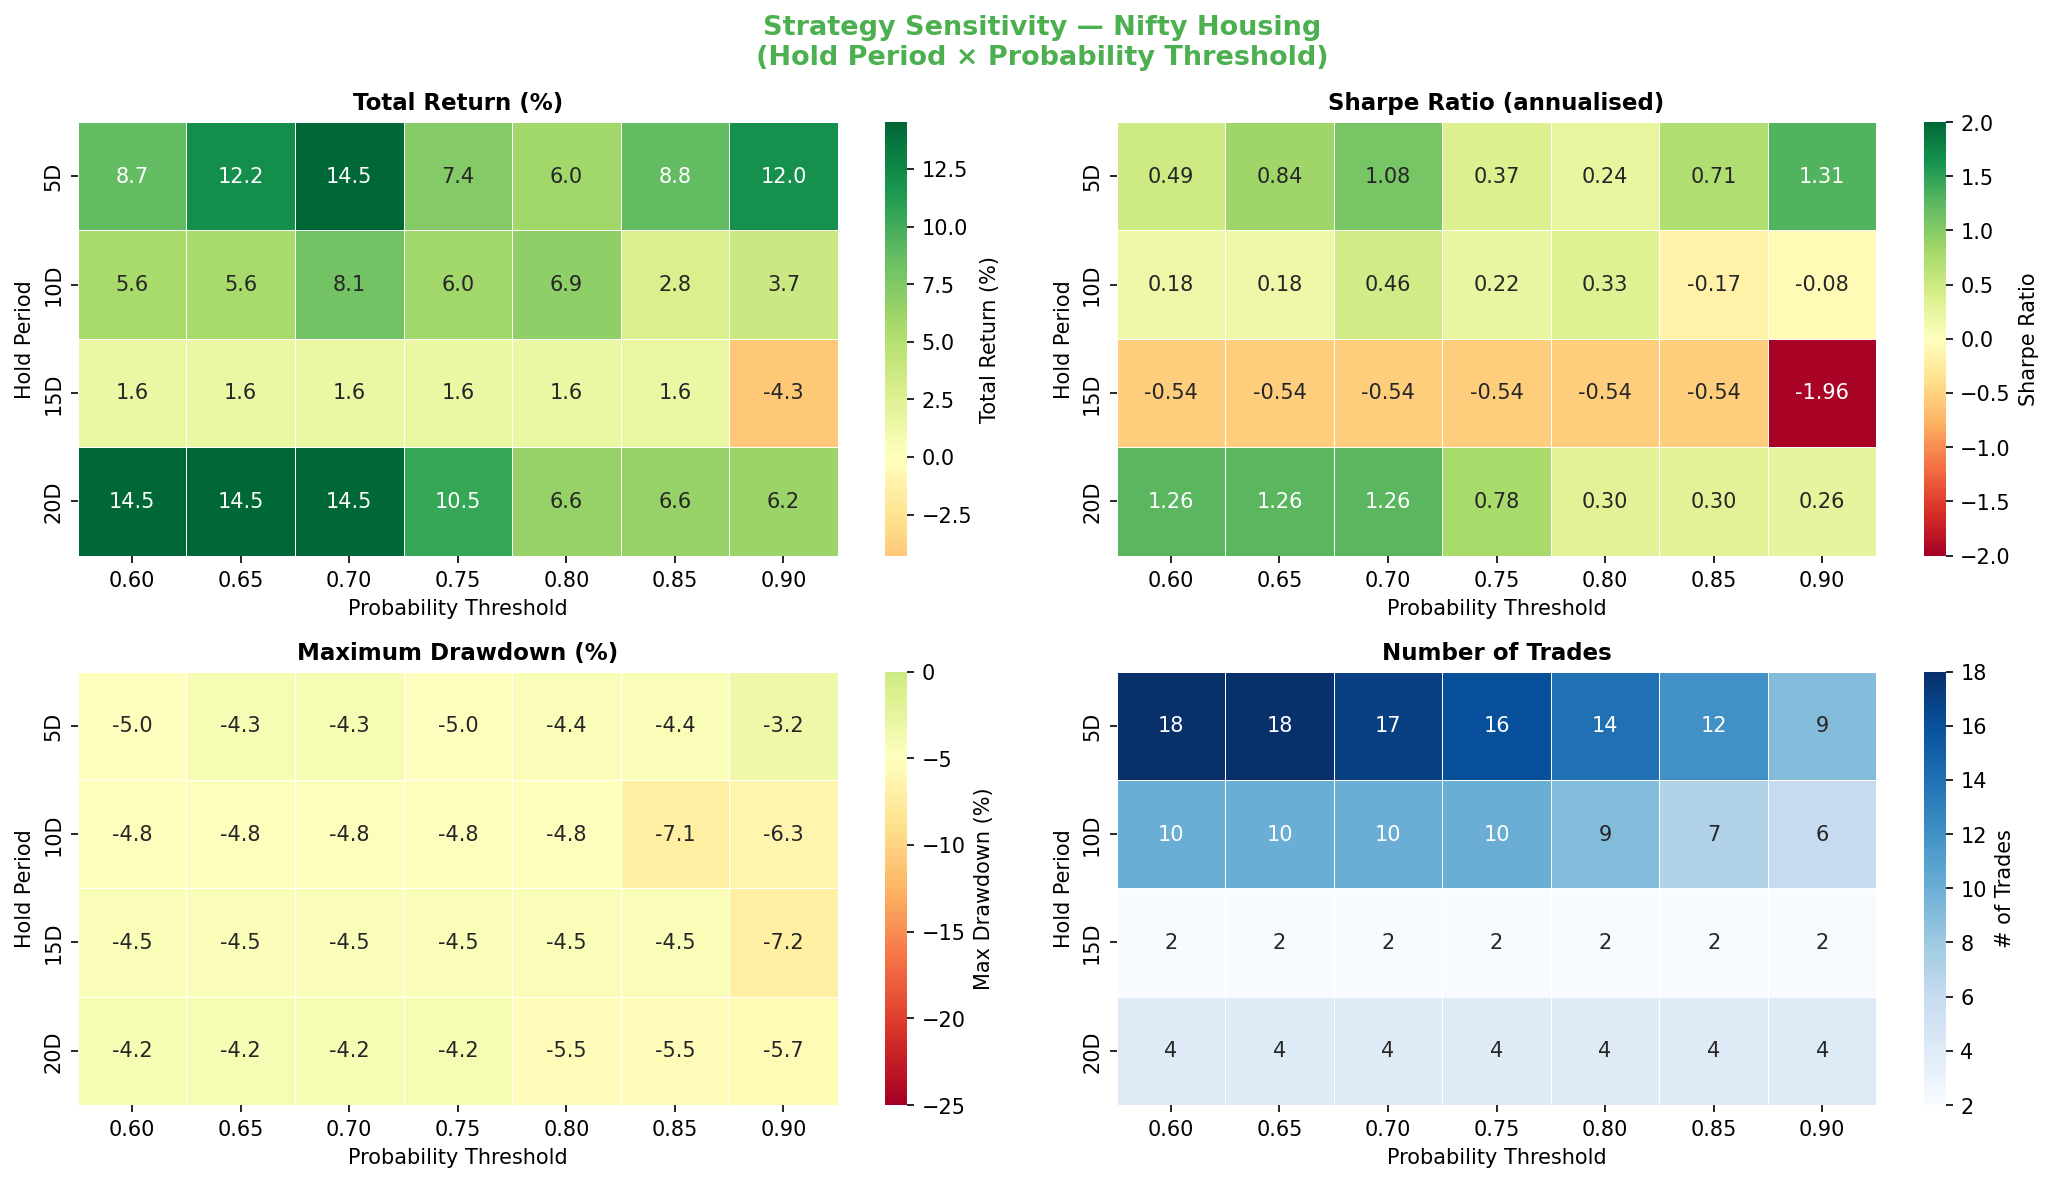

✓ Fig11_Sensitivity_Housing.png saved


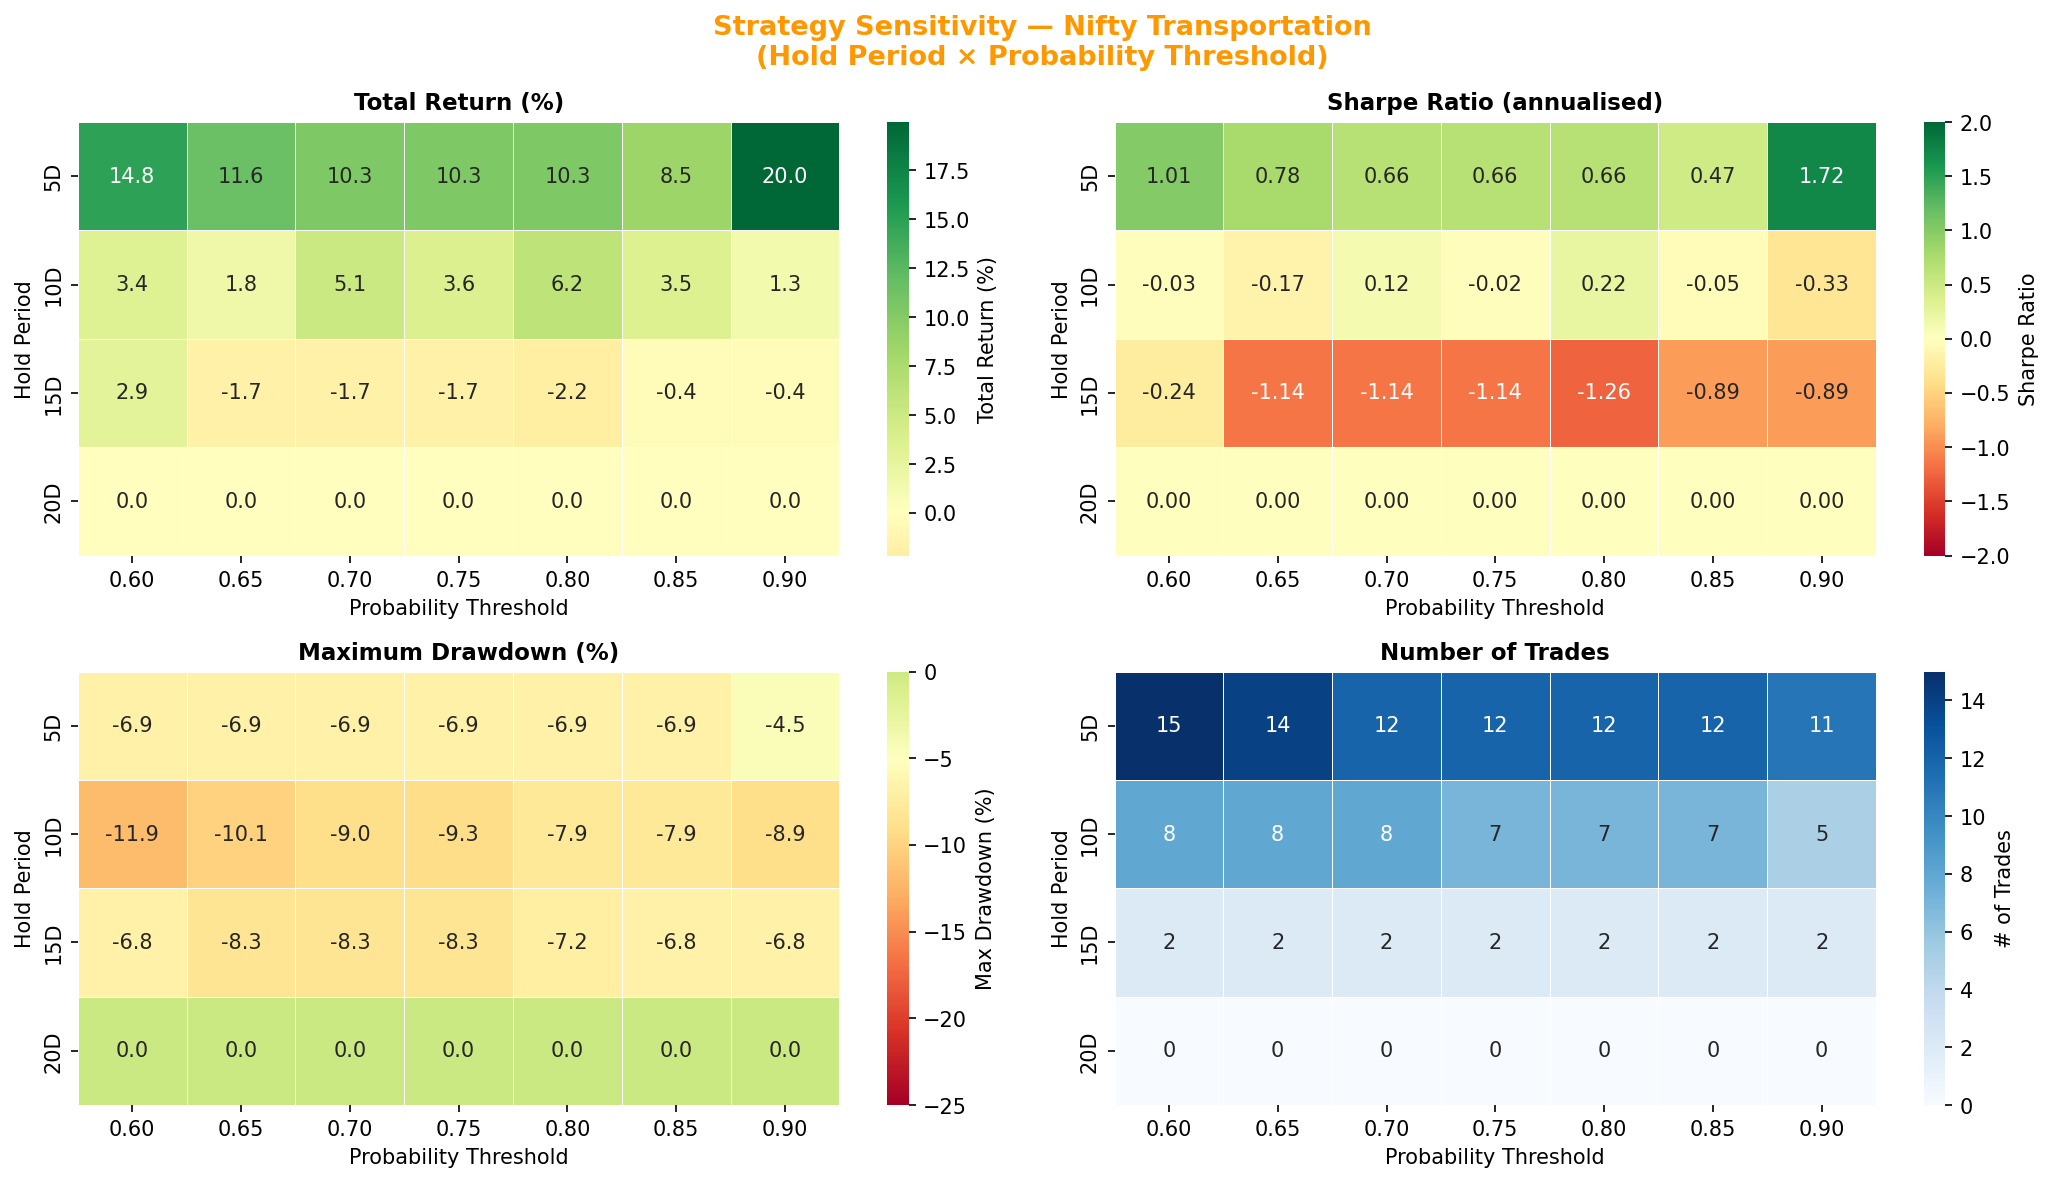

✓ Fig11_Sensitivity_Transportation.png saved


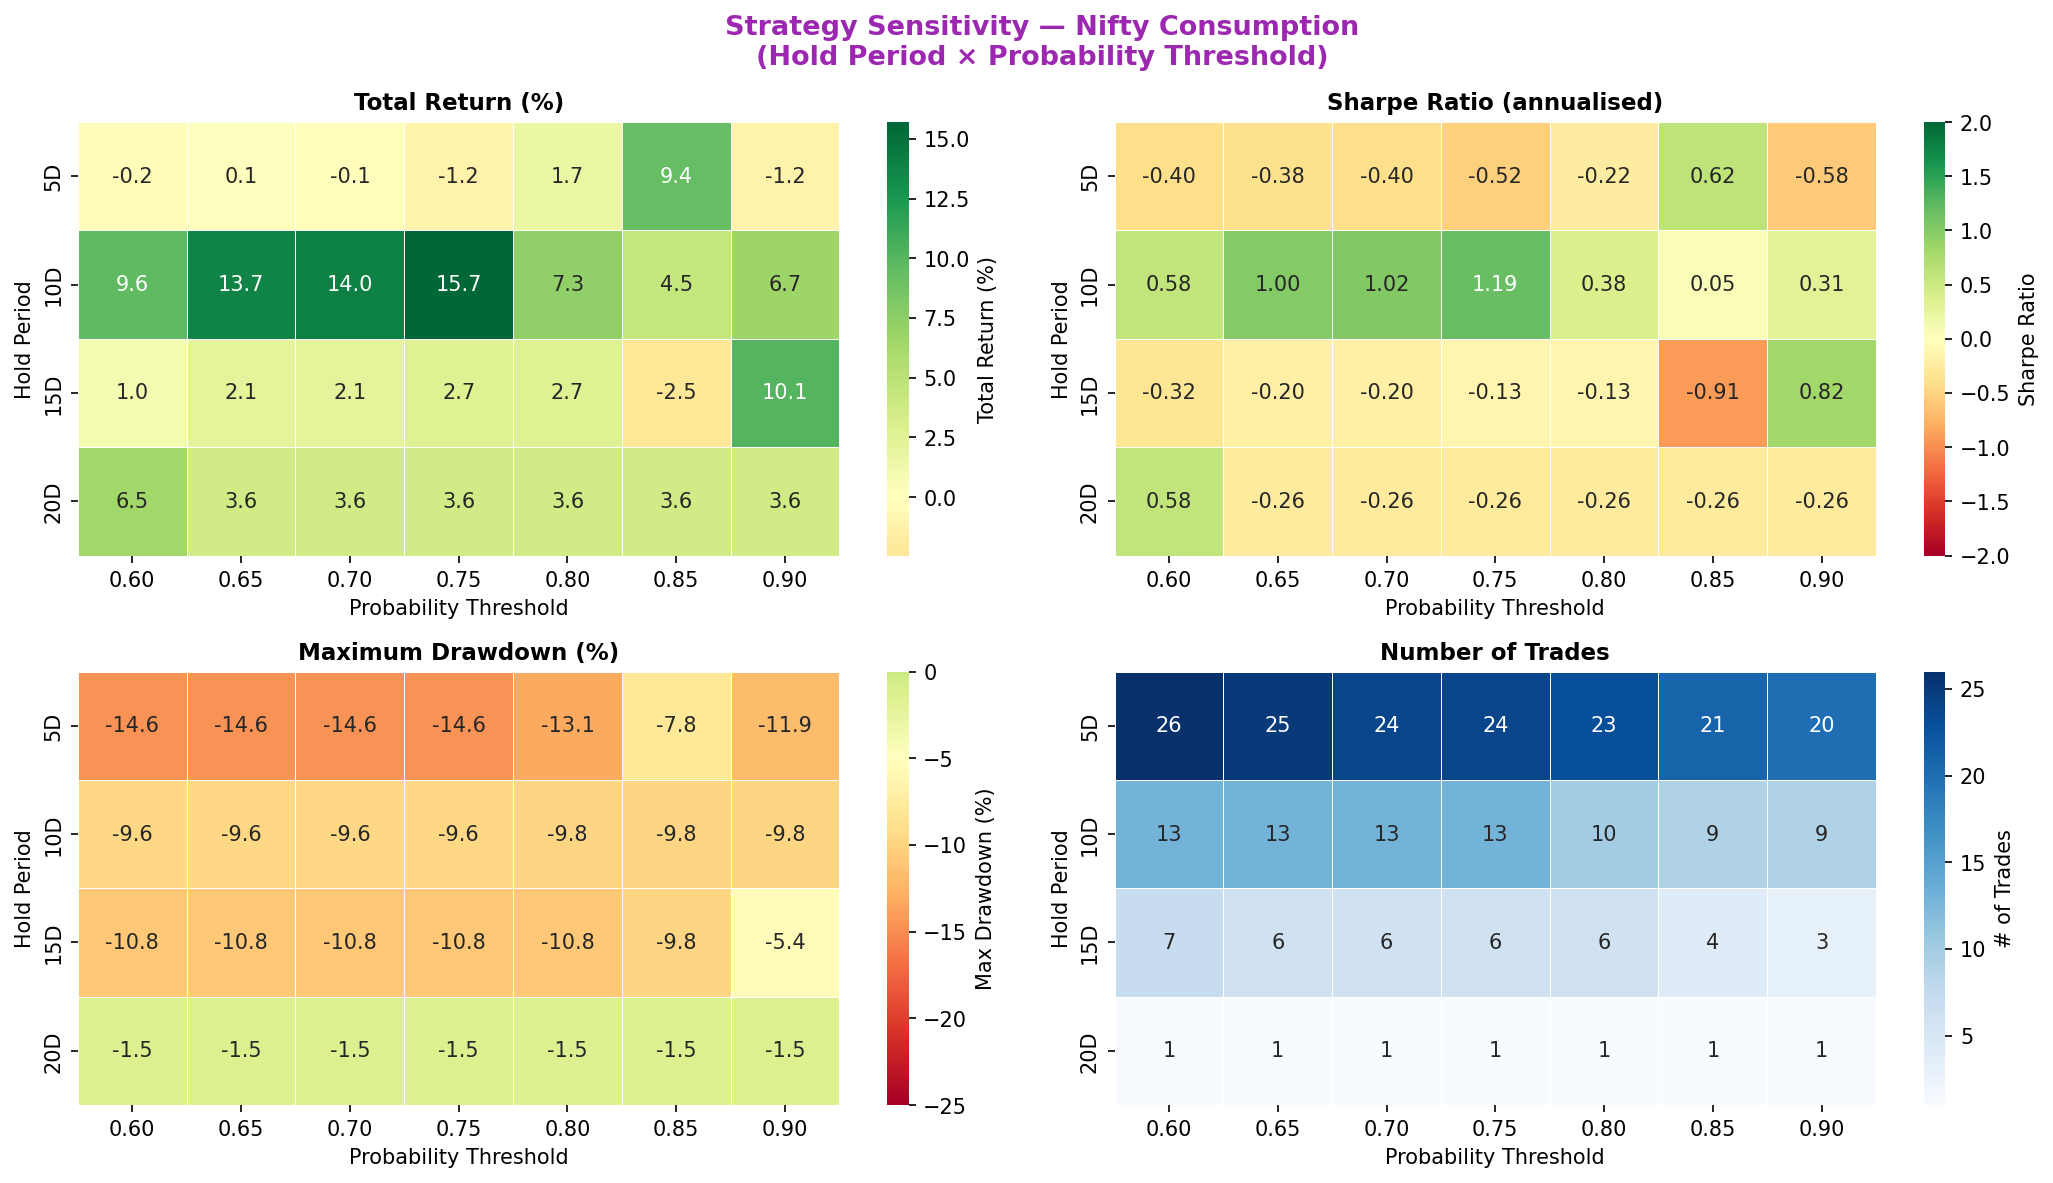

✓ Fig11_Sensitivity_Consumption.png saved


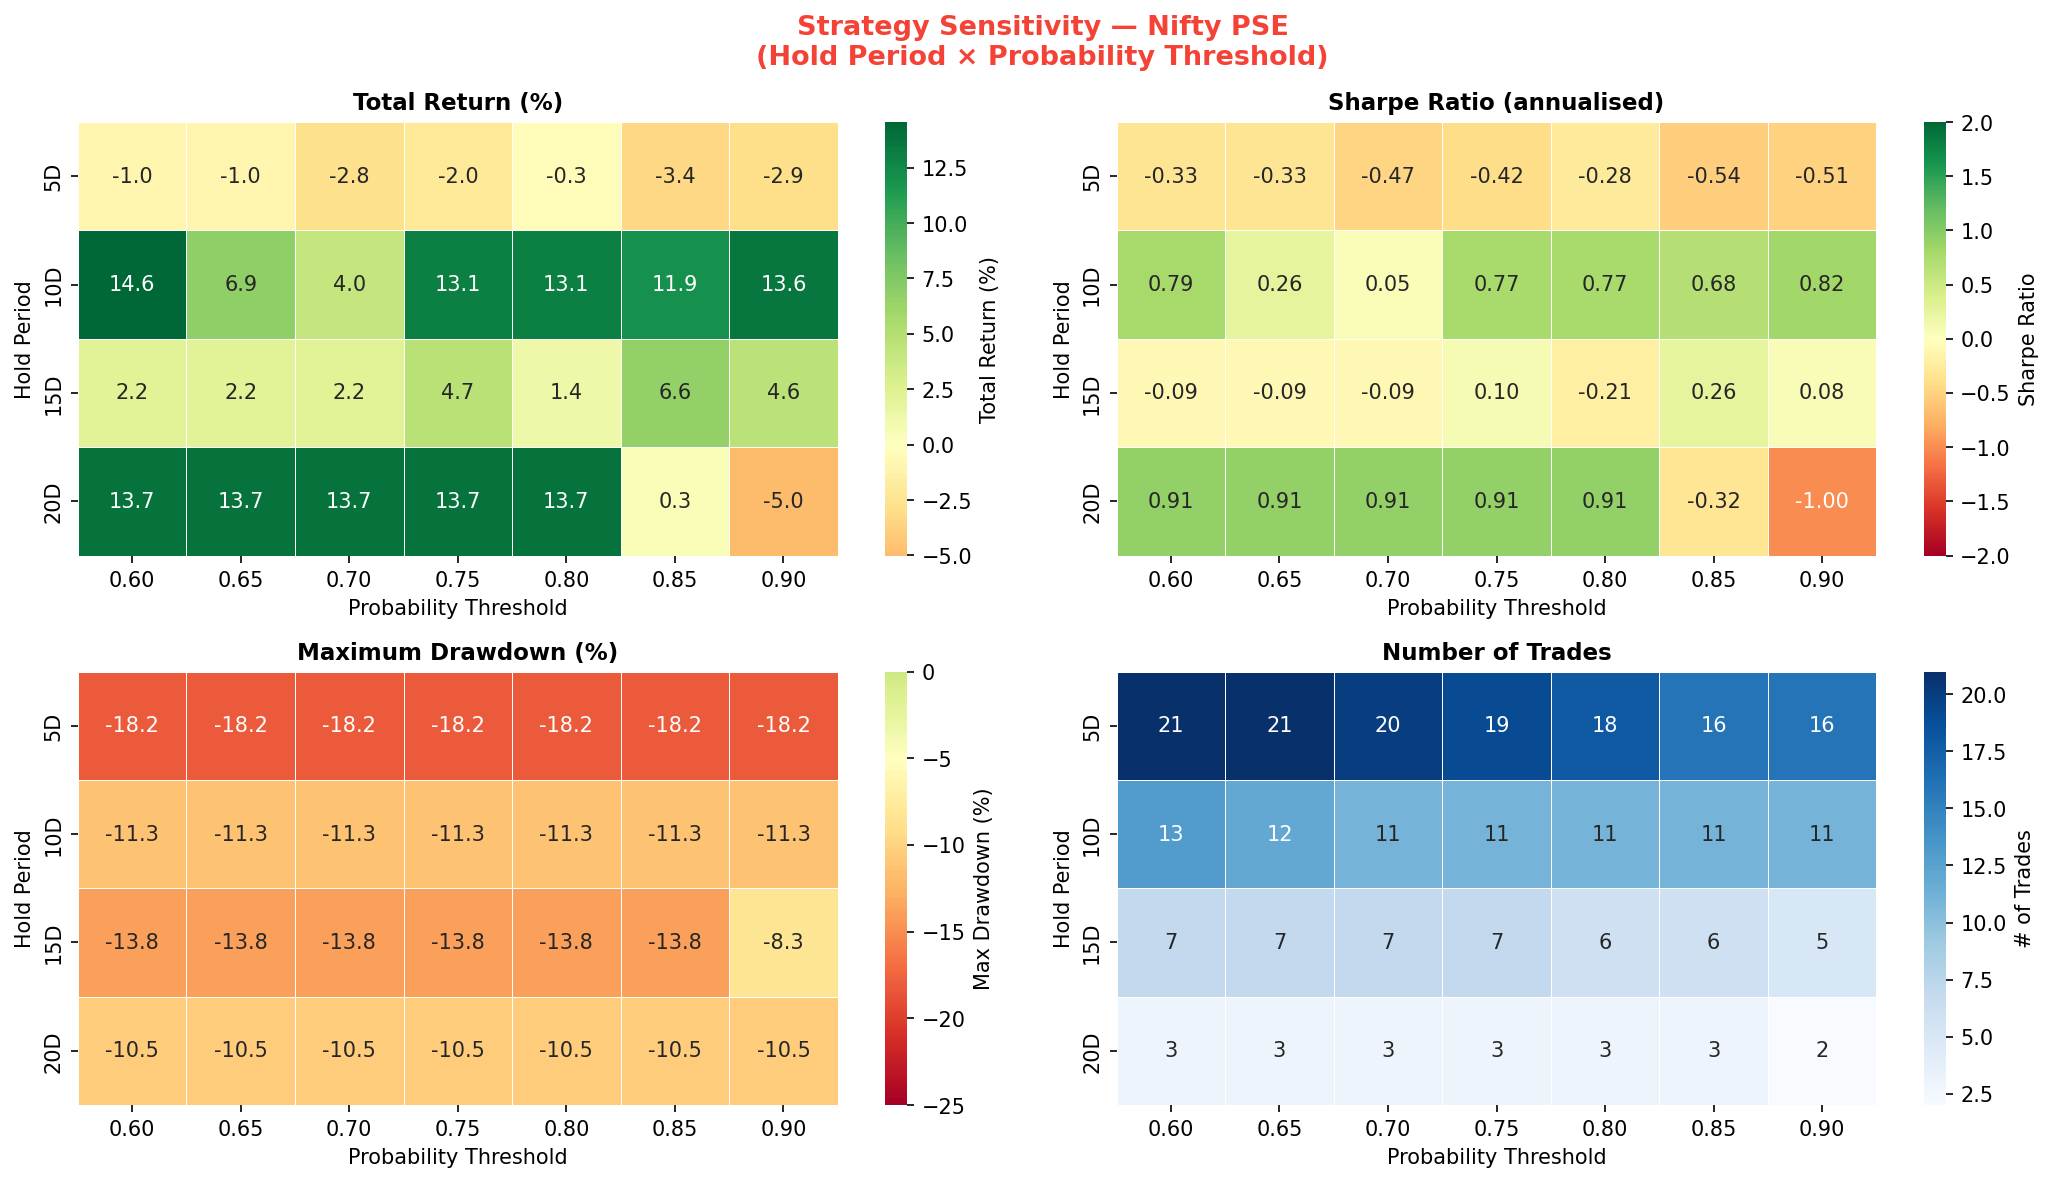

✓ Fig11_Sensitivity_PSE.png saved


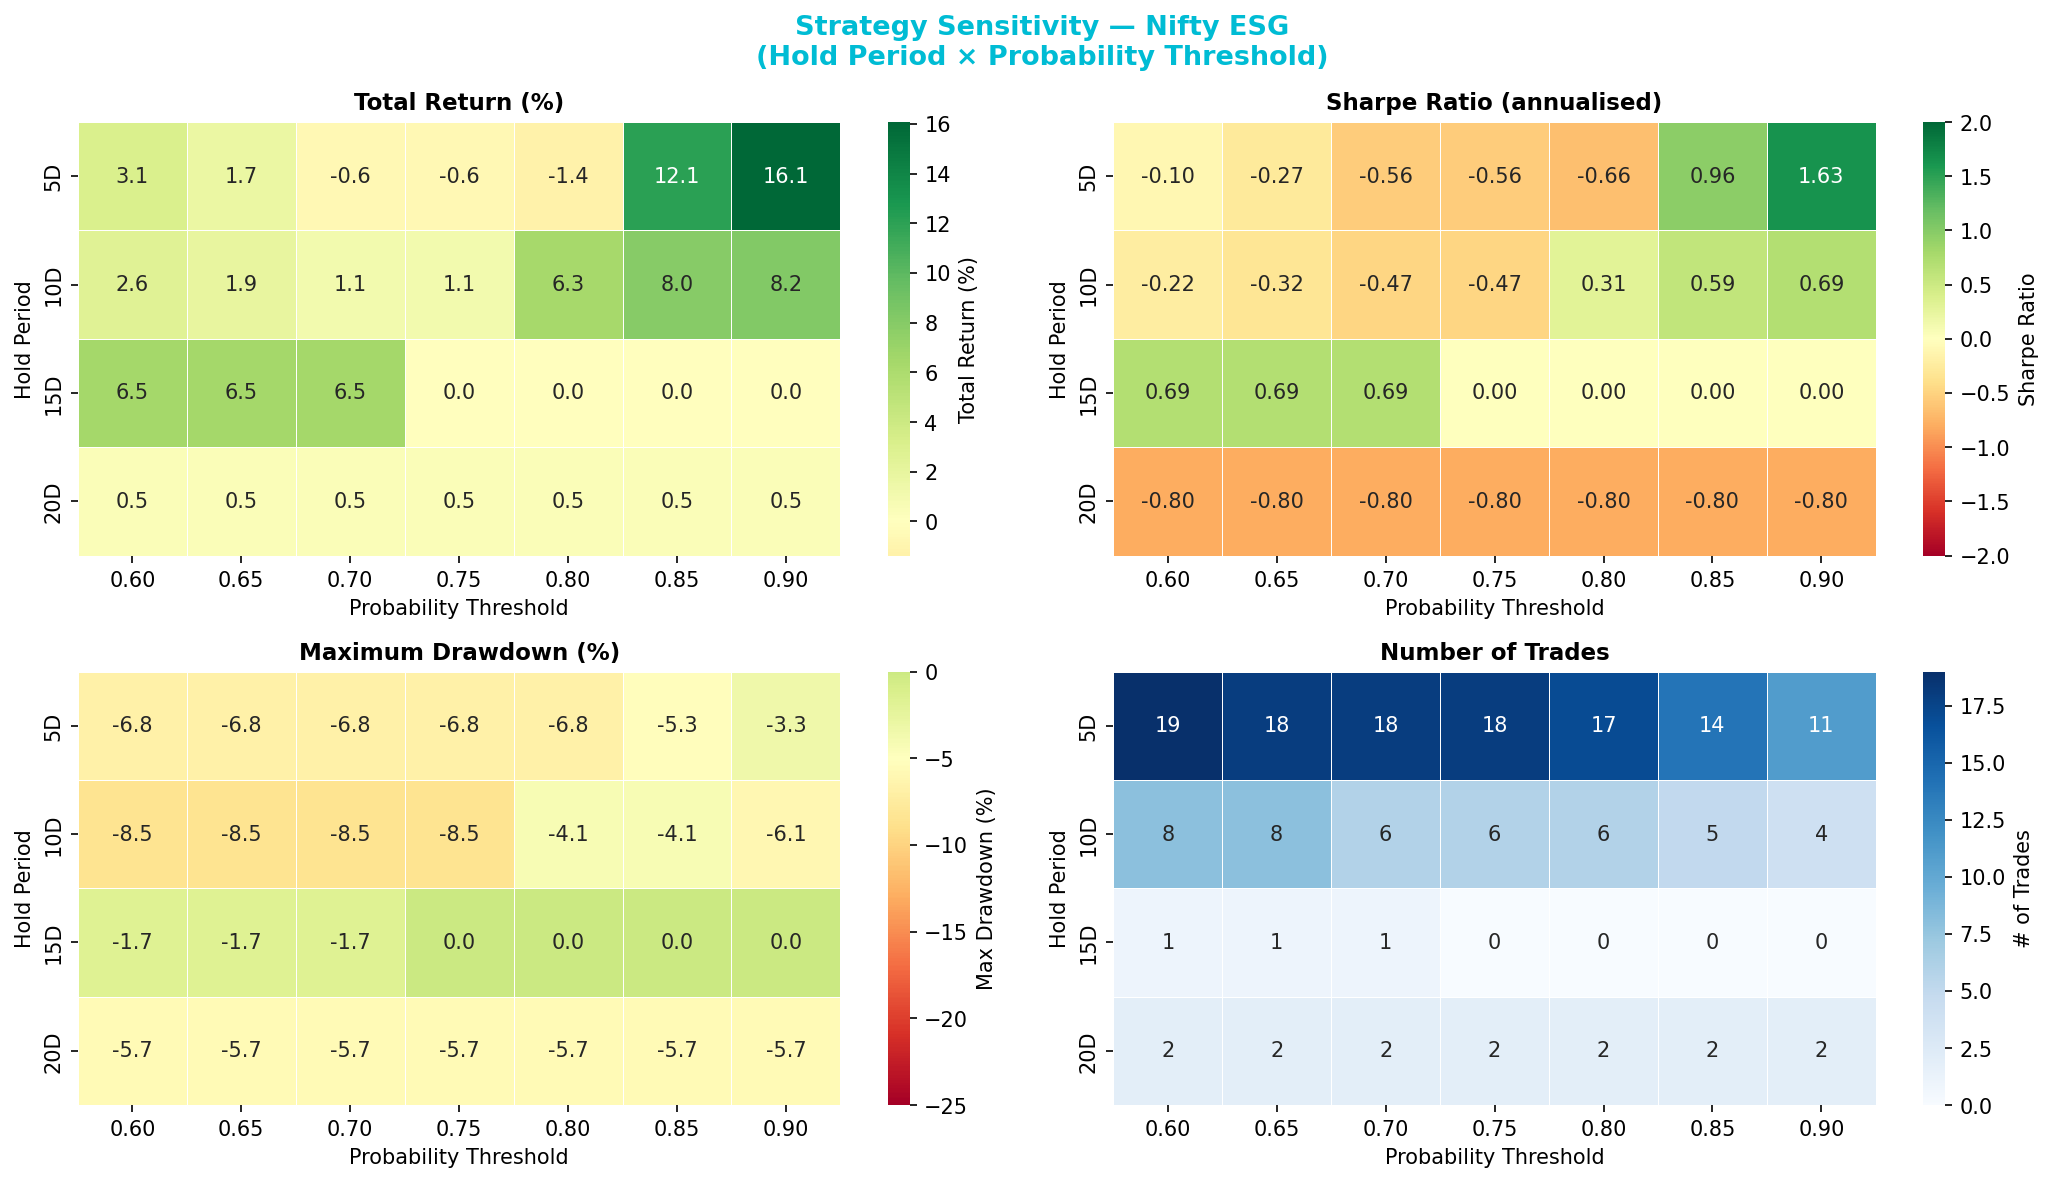

✓ Fig11_Sensitivity_ESG.png saved

CROSS-INDEX SHARPE SUMMARY
Each cell shows Sharpe ratio at (hold, threshold) configuration


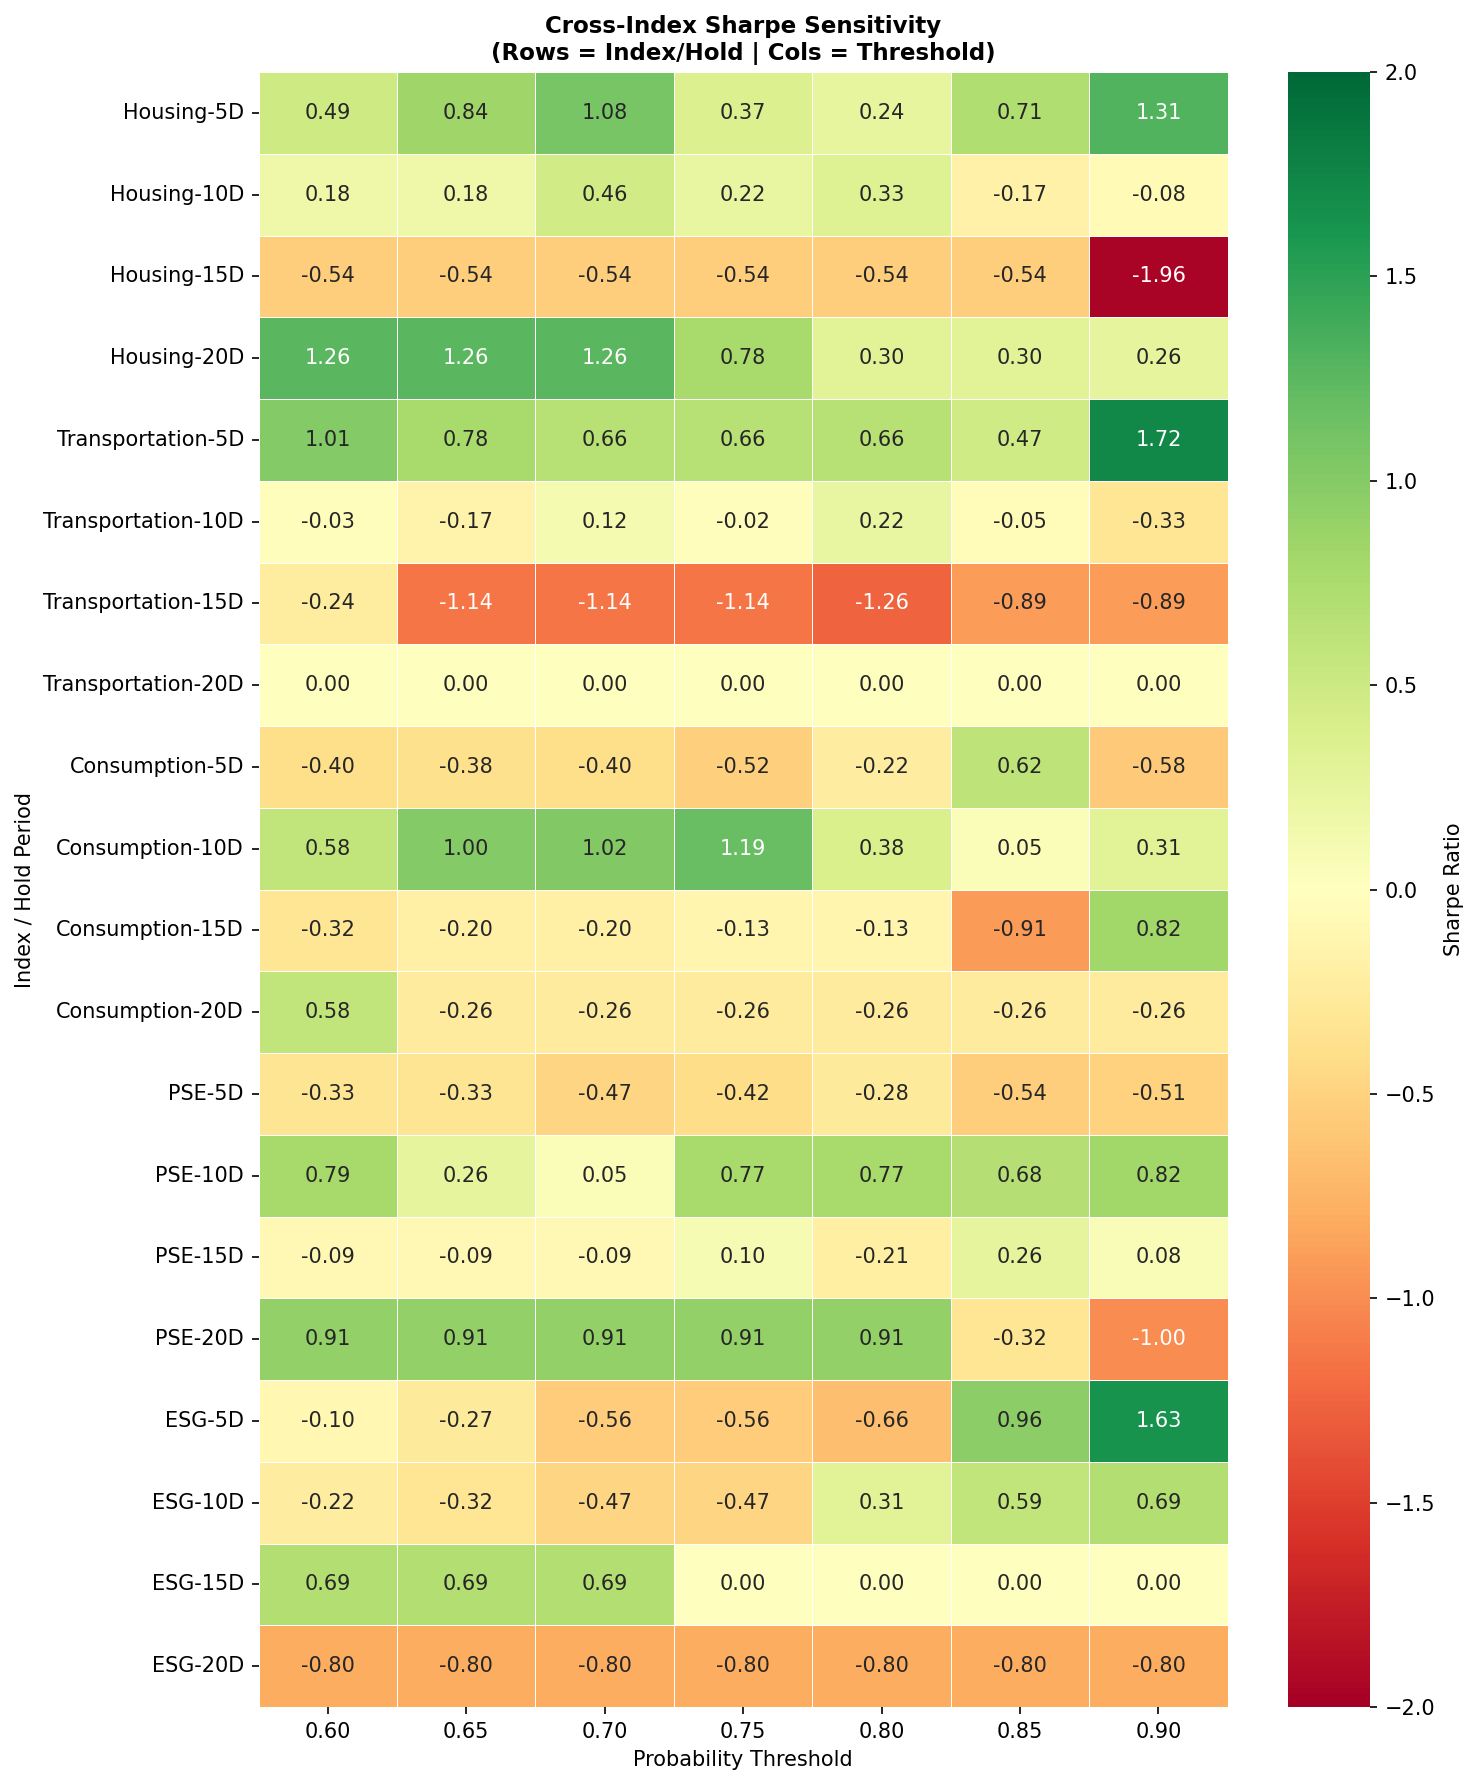


ROBUSTNESS SUMMARY — Range of Outcomes Across All Configurations
                Configs_Total  Configs_Active Ret_Min Ret_Median Ret_Max Sharpe_Min Sharpe_Median Sharpe_Max DD_Worst
Index                                                                                                                
Housing                    28              28   -4.3%      +6.4%  +14.5%      -1.96          0.28       1.31    -7.2%
Transportation             28              21   -2.2%      +3.5%  +20.0%      -1.26         -0.03       1.72   -11.9%
Consumption                28              28   -2.5%      +3.6%  +15.7%      -0.91         -0.21       1.19   -14.6%
PSE                        28              28   -5.0%      +4.3%  +14.6%      -1.00          0.06       0.91   -18.2%
ESG                        28              24   -1.4%      +1.4%  +16.1%      -0.80         -0.40       1.63    -8.5%

Notes on interpretation:
  Configs_Active : # of (hold × threshold) combinations that produced ≥1 trade
  R

In [25]:
# ================================================================
# CELL 25 — SENSITIVITY VISUALISATION
# Generates 5 heatmap grids (one per index), each showing 4 metrics.
# Then prints a robustness summary table.
# ================================================================

# ── Per-index heatmap grids (4 metrics × 1 index) ────────────────
for idx_name in INDEX_CFG:
    cfg     = INDEX_CFG[idx_name]
    sens    = sensitivity_results[idx_name]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(
        f'Strategy Sensitivity — Nifty {idx_name}\n'
        f'(Hold Period × Probability Threshold)',
        fontsize=13, fontweight='bold', color=cfg['color']
    )

    # Total Return heatmap
    ax = axes[0, 0]
    sns.heatmap(sens['Total_Ret'], ax=ax, annot=True, fmt='.1f',
                cmap='RdYlGn', center=0, linewidths=0.4, linecolor='white',
                cbar_kws={'label': 'Total Return (%)'})
    ax.set_title('Total Return (%)', fontweight='bold')
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Hold Period')

    # Sharpe heatmap
    ax = axes[0, 1]
    sns.heatmap(sens['Sharpe'], ax=ax, annot=True, fmt='.2f',
                cmap='RdYlGn', center=0, vmin=-2, vmax=2,
                linewidths=0.4, linecolor='white',
                cbar_kws={'label': 'Sharpe Ratio'})
    ax.set_title('Sharpe Ratio (annualised)', fontweight='bold')
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Hold Period')

    # Max Drawdown heatmap (more negative = worse)
    ax = axes[1, 0]
    sns.heatmap(sens['Max_DD'], ax=ax, annot=True, fmt='.1f',
                cmap='RdYlGn', center=-5, vmin=-25, vmax=0,
                linewidths=0.4, linecolor='white',
                cbar_kws={'label': 'Max Drawdown (%)'})
    ax.set_title('Maximum Drawdown (%)', fontweight='bold')
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Hold Period')

    # # Trades heatmap
    ax = axes[1, 1]
    sns.heatmap(sens['N_Trades'], ax=ax, annot=True, fmt='.0f',
                cmap='Blues', linewidths=0.4, linecolor='white',
                cbar_kws={'label': '# of Trades'})
    ax.set_title('Number of Trades', fontweight='bold')
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Hold Period')

    plt.tight_layout()
    fname = f'Fig11_Sensitivity_{idx_name}.png'
    plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'✓ {fname} saved')


# ── Cross-index Sharpe summary heatmap ──────────────────────────
print('\n' + '='*70)
print('CROSS-INDEX SHARPE SUMMARY')
print('Each cell shows Sharpe ratio at (hold, threshold) configuration')
print('='*70)

# Build a long-form table: rows = (index, hold), cols = thresholds
combined_sharpe = pd.concat(
    {idx: sensitivity_results[idx]['Sharpe'] for idx in INDEX_CFG},
    axis=0
)

# Reformat for readability
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(combined_sharpe, ax=ax, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-2, vmax=2,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Sharpe Ratio'})
ax.set_title('Cross-Index Sharpe Sensitivity\n(Rows = Index/Hold | Cols = Threshold)',
             fontweight='bold')
ax.set_xlabel('Probability Threshold')
ax.set_ylabel('Index / Hold Period')
plt.tight_layout()
plt.savefig('Fig12_CrossIndex_Sharpe_Sensitivity.png', dpi=180, bbox_inches='tight')
plt.show()


# ── Robustness summary table ────────────────────────────────────
print('\n' + '='*78)
print('ROBUSTNESS SUMMARY — Range of Outcomes Across All Configurations')
print('='*78)

summary_rows = []
for idx_name in INDEX_CFG:
    sens = sensitivity_results[idx_name]
    ret_flat    = sens['Total_Ret'].values.flatten()
    sharpe_flat = sens['Sharpe'].values.flatten()
    dd_flat     = sens['Max_DD'].values.flatten()
    nt_flat     = sens['N_Trades'].values.flatten()

    # Filter out trivial 0-trade configurations for fair stats
    active = nt_flat > 0
    summary_rows.append({
        'Index'          : idx_name,
        'Configs_Total'  : len(nt_flat),
        'Configs_Active' : int(active.sum()),
        'Ret_Min'        : f'{ret_flat[active].min():+.1f}%' if active.any() else 'n/a',
        'Ret_Median'     : f'{np.median(ret_flat[active]):+.1f}%' if active.any() else 'n/a',
        'Ret_Max'        : f'{ret_flat[active].max():+.1f}%' if active.any() else 'n/a',
        'Sharpe_Min'     : f'{sharpe_flat[active].min():.2f}' if active.any() else 'n/a',
        'Sharpe_Median'  : f'{np.median(sharpe_flat[active]):.2f}' if active.any() else 'n/a',
        'Sharpe_Max'     : f'{sharpe_flat[active].max():.2f}' if active.any() else 'n/a',
        'DD_Worst'       : f'{dd_flat[active].min():.1f}%' if active.any() else 'n/a',
    })

summary_df = pd.DataFrame(summary_rows).set_index('Index')
print(summary_df.to_string())

print(f"""
Notes on interpretation:
  Configs_Active : # of (hold × threshold) combinations that produced ≥1 trade
  Ret_Median     : Median total return across active configurations
  Sharpe_Median  : Median Sharpe across active configurations
  
  Robust strategy: Sharpe_Min > 0 across all active configs
  Fragile: large gap between Sharpe_Min and Sharpe_Max
  Threshold-sensitive: many configs went to 0 trades
""")